# Coordination and population density by commune — presidential first rounds 2002 & 2022

## 1. Purpose

At département level, CENP (electoral coordination) shows little or no association with population density in
2002 but a positive one in 2022. **Does the same pattern appear at commune level?**

Steps:

1. **Scrape** first-round results for every commune from the Ministère de l'Intérieur archive
   (`archives-resultats-elections.interieur.gouv.fr`), starting from the département pages found by
   `departements_results_scrapping.ipynb`.
2. **Compute** the coordination measures already used at département level (ENP, CENP, cliff magnitude /
   location / ratio), with `K` = number of candidates nationally (16 in 2002, 12 in 2022).
3. **Merge** INSEE commune population and surface, compute density.
4. **Describe** the density–coordination relationship in each year, check robustness to small communes, and
   compare the relationship between 2002 and 2022 (not commune-by-commune changes).

Everything is **descriptive**; nothing here identifies a causal effect of urbanisation.

### Structure of the site (observed on the cached département pages)

* Département page, e.g. `…/presidentielle_2002/082/001/8201.php` (2002) or `…/presidentielle-2022/084/001/index.php` (2022).
* It links to **alphabetical index pages** in the same folder: `001a.php`, `001b.php`, … (2002) / `001A.php`, … (2022).
  Each index page lists the communes whose name starts with that letter; the links point to the commune pages.
* Commune pages are in the département folder and their file name contains the commune code:
  `…/presidentielle_2002/026/058/58001.php` (2002: INSEE code) and `…/presidentielle-2022/053/022/022179.php`
  (2022: département on 3 characters + commune number). The commune code is derived from the file name (section 3);
  the inspection cells in section 4 show the parsed codes.
* **Paris** (département 75 = one commune): the département page itself shows the results of the whole commune and
  links to the 20 arrondissement pages. **Lyon and Marseille** are expected to have a commune page (whole commune)
  linking to their arrondissements.

### Paris, Lyon, Marseille

The analysis unit is the **commune**. Paris (`75056`), Lyon (`69123`) and Marseille (`13055`) are used as whole
communes, from their whole-commune results pages. Arrondissement pages are **not** treated as communes; they are
scraped separately only to check that they add up to the commune totals (section 11). If a whole-commune page turns out
to be missing, the documented fallback is to sum the arrondissements' votes and turnout (arrondissements partition
the commune), flagged in `plm_source`.

### Geography of the INSEE data

The INSEE file (`base-cc-serie-historique-2022.CSV`) gives populations and surfaces **in a single, recent commune geography**
(historical populations re-computed on today's boundaries). This was assumed to be the 2022 geography, but some 2022
election communes have no INSEE code (section 10), so the file's geography is **later than the 2022 election** —
see the audit, section 19.3. This is right for 2022, but in 2002 many communes that
later merged into *communes nouvelles* still existed. Consequences for 2002 (made explicit, not repaired):

* 2002 communes absorbed later have **no INSEE match** → listed as unmatched, excluded from the density analysis;
* a 2002 commune whose code survives as the chef-lieu of a commune nouvelle **matches a larger 2022 commune**
  (population and surface of the merged commune). These are flagged heuristically with the ratio
  `registered voters 2002 / population 1999` (`possible_boundary_change`) and excluded from the main 2002 sample.

No commune-level change (`Δ CENP`) is computed: 2002 and 2022 are analysed as two separate cross-sections.

## 2. Imports and paths

In [2]:
import gzip
import re
import time
import unicodedata
from pathlib import Path
from urllib.parse import urldefrag, urljoin, urlparse

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import statsmodels.formula.api as smf
from bs4 import BeautifulSoup
from requests.adapters import HTTPAdapter
from scipy import stats
from urllib3.util.retry import Retry

try:
    from curl_cffi import requests as cffi_requests  # fallback if the site answers 403 to plain requests
except ImportError:
    cffi_requests = None

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

/opt/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [4]:
RAW_DIR = Path("data/raw")
PROCESSED_DIR = Path("data/processed")
INSEE_DIR = RAW_DIR / "insee"

# Département pages discovered by departements_results_scrapping.ipynb
DEPARTMENT_URL_FILES = {year: RAW_DIR / f"presidential_{year}_department_urls.csv" for year in (2002, 2022)}

# Compressed HTML cache (≈ 70,000 pages): re-running never downloads a page twice
CACHE_DIR = RAW_DIR / "html_cache_communes"
USE_CACHE = True

COMMUNES_INSEE_PATH = INSEE_DIR / "base-cc-serie-historique-2022.CSV"

RAW_OUT = {year: RAW_DIR / f"presidential_{year}_communes.csv" for year in (2002, 2022)}
FAILURES_OUT = {year: RAW_DIR / f"presidential_{year}_communes_failures.csv" for year in (2002, 2022)}
RESULTS_OUT = PROCESSED_DIR / "presidential_communes_2002_2022.csv"
INDICES_OUT = PROCESSED_DIR / "coordination_indices_communes.csv"
# Previous version (2002 density from the 1999 census count) — no longer written
DENSITY_OUT = PROCESSED_DIR / "coordination_density_communes.csv"
# Current version (2002 density from population_2002_interp, section 9)
DENSITY_CORRECTED_OUT = PROCESSED_DIR / "coordination_density_communes_corrected.csv"
DENSITY_CORRECTED_BY_YEAR = {year: PROCESSED_DIR / f"coordination_density_communes_{year}_corrected.csv" for year in (2002, 2022)}

YEARS = [2002, 2022]
EXPECTED_K = {2002: 16, 2022: 12}  # first-round candidates nationally
FIRST_ROUND_ONLY = {2002: ["JOSPIN", "BAYROU"], 2022: ["ZEMMOUR", "PECRESSE"]}

METRO_CODES = sorted([f"{i:02d}" for i in range(1, 96) if i != 20] + ["2A", "2B"])  # 96 départements
assert len(METRO_CODES) == 96

PLM = {"75056": "Paris", "69123": "Lyon", "13055": "Marseille"}

SITE_HOME = "https://www.archives-resultats-elections.interieur.gouv.fr/"
REQUEST_DELAY = 0.5  # seconds between downloads (cached pages are not delayed)
# The site answers 403 when it receives too many requests: wait this long (seconds) and retry
FORBIDDEN_WAITS = [60, 300]
TIMEOUT = 30
HEADERS = {
    "User-Agent": ("Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 "
                   "(KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36"),
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
    "Accept-Language": "fr-FR,fr;q=0.9,en;q=0.8",
    "Referer": SITE_HOME,
}

# Testing: set e.g. DEPARTMENT_LIMIT = 2 to scrape only the first 2 départements of each year
DEPARTMENT_LIMIT = None

for d in (RAW_DIR, PROCESSED_DIR, CACHE_DIR):
    d.mkdir(parents=True, exist_ok=True)

## 3. Scraping helpers

Same conventions as `departements_results_scrapping.ipynb` (browser-like headers, retries, `curl_cffi` fallback on
403, a cache so each page is requested once, failures recorded rather than dropped). The full run downloads roughly
36,000 commune pages per year plus the alphabetical index pages: count several hours per year. It can be interrupted
and resumed — cached pages are read from disk.

If the site starts answering **403** in the middle of the run (throttling), the scraper pauses and retries
(`FORBIDDEN_WAITS`); pages that still fail are recorded, and the *retry* cells after each step re-run only those.
If 403s are frequent, increase `REQUEST_DELAY`.

### HTTP and cache

In [5]:
def make_session():
    session = requests.Session()
    session.headers.update(HEADERS)
    retry = Retry(total=3, backoff_factor=1, status_forcelist=[429, 500, 502, 503, 504])
    session.mount("https://", HTTPAdapter(max_retries=retry))
    return session


SESSION = make_session()


def cache_path(url):
    p = urlparse(url)
    return CACHE_DIR / (re.sub(r"[^A-Za-z0-9._-]+", "_", p.netloc + p.path) + ".gz")


def download_once(url):
    resp = SESSION.get(url, timeout=TIMEOUT)
    if resp.status_code == 403 and cffi_requests is not None:
        resp = cffi_requests.get(url, impersonate="chrome", timeout=TIMEOUT, headers={"Referer": SITE_HOME})
    return resp


def download(url):
    """GET a page. A 403 in the middle of a long run is usually throttling: pause and retry (FORBIDDEN_WAITS)."""
    resp = download_once(url)
    for wait in FORBIDDEN_WAITS:
        if resp.status_code != 403:
            break
        print(f"    403 on {url} — pausing {wait} s before retrying")
        time.sleep(wait)
        resp = download_once(url)
    if resp.status_code == 403:
        raise requests.HTTPError(f"403 Forbidden for {url}"
                                 + ("" if cffi_requests else " — try `pip install curl_cffi`"))
    resp.raise_for_status()
    return resp.content


def fetch(url):
    """Raw bytes of a page; each page is downloaded at most once (gzip cache). Errors are not cached."""
    path = cache_path(url)
    if USE_CACHE and path.exists():
        return gzip.decompress(path.read_bytes())
    content = download(url)
    time.sleep(REQUEST_DELAY)
    if USE_CACHE:
        path.write_bytes(gzip.compress(content))
    return content


def get_soup(url):
    return BeautifulSoup(fetch(url), "html.parser")  # bytes: encoding detected from <meta charset>


def page_links(soup, base_url):
    """(absolute URL without fragment, label) for every <a href> of a page."""
    out = []
    for a in soup.find_all("a", href=True):
        href = a["href"].strip()
        if href.startswith(("#", "javascript:", "mailto:")):
            continue
        out.append((urldefrag(urljoin(base_url, href))[0], " ".join(a.get_text(" ", strip=True).split())))
    return out


def page_heading(soup):
    """Results title such as 'PARIS (75) (résultats officiels)' (the <h1>/<title> are generic)."""
    for tag in soup.find_all(["strong", "h1", "h2", "h3"]):
        text = " ".join(tag.get_text(" ", strip=True).split())
        if re.search(r"\(\s*[0-9A-Z]{2,3}\s*\)", text) or "sultats" in text:
            return text
    return soup.title.get_text(" ", strip=True) if soup.title else ""

### Text / number helpers and commune codes

The commune code (INSEE, 5 characters) is derived from the commune page's file name. Observed commune pages:

* 2022: `…/presidentielle-2022/053/022/022179.php` = region `053` (Bretagne) / département folder `022`
  (Côtes-d'Armor) / file `022` + `179` (département on 3 characters + commune number) → INSEE code `22179`;
* 2002: `…/presidentielle_2002/026/058/58001.php` = region `026` (Bourgogne) / département folder `058` (Nièvre) /
  file `58001` = the INSEE code itself.

Handled forms:

| file name stem | meaning | INSEE code |
|---|---|---|
| `022179` | 3-character département + commune number (observed in 2022) | `22179` |
| `02A004` | idem, Corsica | `2A004` |
| `58001` | INSEE code directly (observed in 2002) | `58001` |
| `971101` | overseas département + 3-digit commune number | `97101` |
| `ZA101` | Ministry letter code for overseas + commune number | `97101` |

The raw stem is kept in `commune_code_source` so that the rule can be checked (section 6).

In [6]:
def strip_accents(text):
    return "".join(c for c in unicodedata.normalize("NFKD", str(text)) if not unicodedata.combining(c))


def norm_text(text):
    return re.sub(r"[^a-z0-9]+", " ", strip_accents(text).lower()).strip()


def to_int(text):
    s = re.sub(r"\s", "", str(text))
    return int(s) if re.fullmatch(r"\d+", s) else None


def to_float(text):
    s = re.sub(r"\s", "", str(text)).replace("%", "").replace(",", ".")
    try:
        return float(s)
    except ValueError:
        return None


def url_stem(url):
    return Path(urlparse(url).path).stem


def url_folder(url):
    return Path(urlparse(url).path).parent.name


# Ministry letter codes of overseas territories -> first 2 digits of the INSEE commune code
# (the 3-digit commune number then completes it: ZA + 101 -> 97101, ZN + 801 -> 98801)
OVERSEAS_LETTER_PREFIX = {"ZA": "97", "ZB": "97", "ZC": "97", "ZD": "97", "ZM": "97", "ZS": "97", "ZX": "97",
                          "ZN": "98", "ZP": "98", "ZW": "98"}


def insee_code_from_stem(stem):
    """Commune INSEE code from a commune page file name (see table above); None if not a commune code."""
    s = stem.upper()
    if re.fullmatch(r"0(\d{2}|2[AB])\d{3}", s):        # 001004 -> 01004, 02A004 -> 2A004
        return s[1:]
    if re.fullmatch(r"9[78]\d\d{3}", s):                 # 971101 -> 97101 (overseas: '97' + 3-digit number)
        return s[:2] + s[3:]
    if re.fullmatch(r"(\d{2}|2[AB])\d{3}", s):           # already an INSEE code
        return s
    if re.fullmatch(r"Z[A-Z]\d{3}", s) and s[:2] in OVERSEAS_LETTER_PREFIX:  # ZA101 -> 97101
        return OVERSEAS_LETTER_PREFIX[s[:2]] + s[2:]
    return None


def department_from_commune(commune_code):
    return commune_code[:3] if commune_code.startswith(("97", "98")) else commune_code[:2]


ARRONDISSEMENT_RE = re.compile(r"^0?(\d{2}\d{3})AR(\d{2})$", re.I)  # 75056AR01 / 075056AR01

### Discovering commune URLs

`discover_commune_urls(dep_url)`:

1. reads the département page and keeps the **alphabetical index pages** (same folder, file name = folder + one letter);
2. reads each index page and keeps the links, in the same folder, whose file name is a **commune code**;
3. keeps **arrondissement** links (`…AR01.php`) apart — they are not communes;
4. if a page links to arrondissements but the city itself has no commune link (Paris: département page = commune page),
   the page linking to the arrondissements is used as the whole-commune page.

In [7]:
def is_letter_page(url, folder):
    stem = url_stem(url)
    return url_folder(url) == folder and len(stem) == len(folder) + 1 and stem[:-1].upper() == folder.upper() and stem[-1].isalpha()


def discover_commune_urls(dep_url):
    """Return (communes, arrondissements, number of index pages, failed index pages) for one département page.

    A failing alphabetical index page is recorded in `failed_pages` (url, error); the other pages are still used.
    """
    folder = url_folder(dep_url)
    dep_soup = get_soup(dep_url)
    dep_links = page_links(dep_soup, dep_url)

    letter_pages = sorted({u for u, _ in dep_links if is_letter_page(u, folder)})
    pages, failed_pages = [(dep_url, dep_links)], []
    for u in letter_pages:
        try:
            pages.append((u, page_links(get_soup(u), u)))
        except Exception as e:
            failed_pages.append((u, repr(e)))

    communes, arrondissements = {}, {}
    for page_url, links in pages:
        for url, label in links:
            if url_folder(url) != folder or url == dep_url:
                continue
            stem = url_stem(url)
            m = ARRONDISSEMENT_RE.fullmatch(stem)
            if m:
                arrondissements[url] = {"commune_code": m.group(1), "arrondissement": int(m.group(2)),
                                        "url": url, "label": label, "found_on": page_url}
                continue
            code = insee_code_from_stem(stem)
            if code and url not in communes:
                communes[url] = {"commune_code": code, "commune_code_source": stem, "commune_name_link": label,
                                 "url": url, "found_on": page_url}

    communes = pd.DataFrame(communes.values(), columns=["commune_code", "commune_code_source", "commune_name_link", "url", "found_on"])
    arrondissements = pd.DataFrame(arrondissements.values(), columns=["commune_code", "arrondissement", "url", "label", "found_on"])

    # Whole city linking to its arrondissements without a commune link of its own (Paris): use the page itself
    for city_code in arrondissements["commune_code"].unique():
        if city_code not in set(communes["commune_code"]):
            page = arrondissements.loc[arrondissements["commune_code"] == city_code, "found_on"].iloc[0]
            communes.loc[len(communes)] = {"commune_code": city_code, "commune_code_source": url_stem(page),
                                           "commune_name_link": PLM.get(city_code, ""), "url": page, "found_on": page}
    return communes, arrondissements, len(letter_pages), failed_pages


def show_links(url):
    """Debugging: all links of a page with the parsed commune code."""
    links = pd.DataFrame(page_links(get_soup(url), url), columns=["url", "label"])
    links["stem"] = links["url"].map(url_stem)
    links["commune_code"] = links["stem"].map(insee_code_from_stem)
    with pd.option_context("display.max_rows", 300, "display.max_colwidth", 110):
        display(links)

### Parsing a results page

Same logic as the département scraper (results pages share the same template):

* results are small tables — turnout (`Inscrits / Abstentions / Votants`, `Blancs ou nuls` or `Blancs` + `Nuls`,
  `Exprimés`) and candidates (`Voix`, `% Exprimés`);
* pages show round 2 first, then *"Rappel … 1er tour"*; the first round is the candidate table with **more than 2
  candidates**;
* the turnout tables are those printed just above (2002) or just below (2022) that candidate table, and the block
  whose `Exprimés` equals the sum of the candidate votes is kept.

In [8]:
TURNOUT_FIELDS = [("blancs ou nuls", "blank_null"), ("blancs et nuls", "blank_null"), ("blancs", "blank"),
                  ("nuls", "null"), ("inscrits", "registered"), ("abstention", "abstentions"),
                  ("votants", "voters"), ("exprimes", "expressed")]
VOTES_HEADER_RE = r"^(voix|nombre de voix)$"


def table_rows(table):
    rows = []
    for tr in table.find_all("tr"):
        cells = [c.get_text(" ", strip=True) for c in tr.find_all(["th", "td"])]
        if any(cells):
            rows.append(cells)
    return rows


def turnout_label(cell):
    key = re.sub(r"^(nombre (de |d )?|bulletins |votes )", "", norm_text(cell))
    return next((field for prefix, field in TURNOUT_FIELDS if key.startswith(prefix)), None)


def header_index(rows, pattern):
    return next((i for i, row in enumerate(rows) if any(re.search(pattern, norm_text(c)) for c in row)), None)


def parse_candidates(rows):
    h = header_index(rows, VOTES_HEADER_RE)
    if h is None:
        return []
    header = [norm_text(c) for c in rows[h]]
    votes_col = next(i for i, c in enumerate(header) if re.search(VOTES_HEADER_RE, c))
    share_col = next((i for i, c in enumerate(header) if "exprim" in c), None)
    name_col = next((i for i, c in enumerate(header) if re.search(r"^(candidats?|listes?|noms?)\b", c)), 0)
    out = []
    for row in rows[h + 1:]:
        if len(row) != len(header) or turnout_label(row[name_col]):
            continue
        votes = to_int(row[votes_col])
        if votes is None or not re.search(r"[A-Za-z]", row[name_col]):
            continue
        out.append({"candidate": " ".join(row[name_col].split()), "votes": votes,
                    "vote_share": to_float(row[share_col]) if share_col is not None else None})
    return out


def parse_turnout(rows):
    h = header_index(rows, r"^nombre$")
    col = [norm_text(c) for c in rows[h]].index("nombre") if h is not None else 1
    values = {}
    for row in rows:
        field = turnout_label(row[0])
        if field and field not in values and len(row) > col and to_int(row[col]) is not None:
            values[field] = to_int(row[col])
    return values or None


def extract_first_round(soup, year):
    """(turnout dict, candidate list, turnout_matches_sum) for the first round shown on a page."""
    cand_tables, turnout_tables = [], []
    for pos, table in enumerate(soup.find_all("table")):
        if table.find("table"):  # layout table
            continue
        rows = table_rows(table)
        cands, turnout = parse_candidates(rows), parse_turnout(rows)
        if cands:
            cand_tables.append({"pos": pos, "cands": cands})
        if turnout:
            turnout_tables.append({"pos": pos, "values": turnout})

    first = [t for t in cand_tables if len(t["cands"]) > 2]  # round 2 has exactly 2 candidates
    if not first:
        raise ValueError(f"no first-round candidate table (sizes: {[len(t['cands']) for t in cand_tables]})")
    first.sort(key=lambda t: (len(t["cands"]) != EXPECTED_K[year], t["pos"]))
    cand = first[0]
    total = sum(c["votes"] for c in cand["cands"])

    positions = [t["pos"] for t in cand_tables]
    prev_pos = max((p for p in positions if p < cand["pos"]), default=-1)
    next_pos = min((p for p in positions if p > cand["pos"]), default=float("inf"))
    merged = []
    for block in ([t for t in turnout_tables if prev_pos < t["pos"] <= cand["pos"]],
                  [t for t in turnout_tables if cand["pos"] <= t["pos"] < next_pos]):
        values = {}
        for t in block:
            for k, v in t["values"].items():
                values.setdefault(k, v)
        if "expressed" in values and "registered" in values:
            merged.append(values)
    if not merged:
        raise ValueError("no turnout (Inscrits ... Exprimés) next to the first-round candidates")
    turnout = next((t for t in merged if t["expressed"] == total), merged[0])
    return turnout, cand["cands"], turnout["expressed"] == total


def parse_commune_results(url, year, meta):
    """Long-format rows (one per candidate) for one commune page. `meta`: codes and names to attach."""
    soup = get_soup(url)
    turnout, candidates, matches = extract_first_round(soup, year)
    blank_null = turnout.get("blank_null")
    if blank_null is None and "blank" in turnout and "null" in turnout:  # 2022: counted separately
        blank_null = turnout["blank"] + turnout["null"]
    base = {
        "year": year, "round": 1, **meta,
        "registered": turnout.get("registered"), "abstentions": turnout.get("abstentions"),
        "voters": turnout.get("voters"), "blank_null": blank_null, "expressed": turnout.get("expressed"),
        "turnout_matches_sum": matches, "page_heading": page_heading(soup), "source_url": url,
    }
    return pd.DataFrame([{**base, **c} for c in candidates])

### Scraping loop (shared by both years)

In [9]:
def load_department_urls(year):
    """Département pages from the département scraper; the unnamed duplicate '977' (= ZX) is dropped."""
    deps = pd.read_csv(DEPARTMENT_URL_FILES[year], dtype={"dep_code": str}, encoding="utf-8")
    dropped = deps[deps["dep_name"].isna()]
    if len(dropped):
        print(f"{year}: dropping unnamed département rows (duplicates):", dropped[["dep_code", "url"]].to_dict("records"))
    deps = deps[deps["dep_name"].notna()].reset_index(drop=True)
    deps = deps.rename(columns={"dep_code": "department_code", "dep_name": "department_name"})
    print(f"{year}: {len(deps)} départements / territories")
    return deps


def discover_all_communes(year, deps, limit=DEPARTMENT_LIMIT):
    """Commune URLs of every département; failures recorded, loop continues."""
    communes, arrondissements, failures = [], [], []
    todo = deps if limit is None else deps.head(limit)
    for i, dep in enumerate(todo.itertuples(index=False), 1):
        try:
            com, arr, n_letters, failed_pages = discover_commune_urls(dep.url)
            for df in (com, arr):
                df.insert(0, "department_name", dep.department_name)
                df.insert(0, "department_code", dep.department_code)
                df.insert(0, "year", year)
            communes.append(com)
            arrondissements.append(arr)
            print(f"  {dep.department_code} {dep.department_name}: {n_letters} index pages, {len(com)} communes"
                  + (f", {len(arr)} arrondissements" if len(arr) else "")
                  + (f" — {len(failed_pages)} index pages FAILED" if failed_pages else ""))
            for url, error in failed_pages:
                failures.append({"year": year, "level": "index page", "department_code": dep.department_code,
                                 "commune_code": None, "name": dep.department_name, "url": url, "error": error})
            if com.empty and not failed_pages:
                failures.append({"year": year, "level": "no communes", "department_code": dep.department_code,
                                 "commune_code": None, "name": dep.department_name, "url": dep.url,
                                 "error": "no commune link found"})
        except Exception as e:
            failures.append({"year": year, "level": "department", "department_code": dep.department_code,
                             "commune_code": None, "name": dep.department_name, "url": dep.url, "error": repr(e)})
            print(f"  FAILED {dep.department_code} {dep.department_name}: {e!r}")
    communes = pd.concat(communes, ignore_index=True) if communes else pd.DataFrame()
    arrondissements = pd.concat(arrondissements, ignore_index=True) if arrondissements else pd.DataFrame()
    print(f"{year}: {len(communes)} commune URLs, {len(arrondissements)} arrondissement URLs, {len(failures)} failures")
    return communes, arrondissements, failures


def scrape_communes(year, commune_urls, failures=None):
    """Parse every commune page; failures (URL, code, name, error) are recorded and the loop continues."""
    frames, failures = [], list(failures or [])
    n = len(commune_urls)
    for i, c in enumerate(commune_urls.itertuples(index=False), 1):
        meta = {"department_code": c.department_code, "department_name": c.department_name,
                "commune_code": c.commune_code, "commune_code_source": c.commune_code_source,
                "commune_name": c.commune_name_link}
        try:
            frames.append(parse_commune_results(c.url, year, meta))
        except Exception as e:
            failures.append({"year": year, "level": "commune", "department_code": c.department_code,
                             "commune_code": c.commune_code, "name": c.commune_name_link, "url": c.url, "error": repr(e)})
        if i % 1000 == 0 or i == n:
            print(f"  {i}/{n} communes ({len(failures)} failures so far)")
    results = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    failures = pd.DataFrame(failures, columns=["year", "level", "department_code", "commune_code", "name", "url", "error"])
    return results, failures


def retry_discovery(year, deps, commune_urls, arrondissement_urls, failures):
    """Re-discover the départements with a failed département or index page (cached pages are not re-downloaded).

    Their commune/arrondissement rows are replaced by the new ones; 'no communes' entries are kept as they are.
    """
    failures = pd.DataFrame(failures, columns=["year", "level", "department_code", "commune_code", "name", "url", "error"])
    to_redo = failures.loc[failures["level"].isin(["department", "index page"]), "department_code"].unique()
    if len(to_redo) == 0:
        print("Nothing to retry.")
        return commune_urls, arrondissement_urls, failures.to_dict("records")
    print("Retrying:", list(to_redo))
    new_com, new_arr, new_failures = discover_all_communes(year, deps[deps["department_code"].isin(to_redo)], limit=None)
    keep = lambda df: df[~df["department_code"].isin(to_redo)] if len(df) else df
    commune_urls = pd.concat([keep(commune_urls), new_com], ignore_index=True)
    arrondissement_urls = pd.concat([keep(arrondissement_urls), new_arr], ignore_index=True)
    failures = [f for f in failures.to_dict("records") if f["department_code"] not in set(to_redo)] + new_failures
    print(f"{year}: now {len(commune_urls)} commune URLs, {len(failures)} failures")
    return commune_urls, arrondissement_urls, failures


def retry_commune_failures(year, commune_urls, results, failures):
    """Re-scrape only the commune pages that failed; other failures are kept."""
    commune_failed = failures["level"].eq("commune")
    todo = commune_urls[commune_urls["url"].isin(failures.loc[commune_failed, "url"])]
    if todo.empty:
        print("No commune page to retry.")
        return results, failures
    print(f"Retrying {len(todo)} commune pages")
    new_results, new_failures = scrape_communes(year, todo)
    results = pd.concat([results, new_results], ignore_index=True)
    failures = pd.concat([failures[~commune_failed], new_failures], ignore_index=True)
    print(f"{year}: {results['commune_code'].nunique()} communes parsed, {len(failures)} failures left")
    return results, failures

## 4. Scrape 2002 commune results

### 4a. Discover commune URLs

First run: set `DEPARTMENT_LIMIT = 2` in section 2, run this section, and check with the inspection cell that the
commune links and codes look right before the full run.

In [9]:
deps_2002 = load_department_urls(2002)
commune_urls_2002, arrondissement_urls_2002, discovery_failures_2002 = discover_all_communes(2002, deps_2002)
commune_urls_2002.head()

2002: 105 départements / territories
  01 Ain: 19 index pages, 419 communes
  02 Aisne: 22 index pages, 816 communes
  03 Allier: 21 index pages, 320 communes
  04 Alpes-de-Haute-Provence: 20 index pages, 200 communes
  05 Hautes-Alpes: 17 index pages, 177 communes
  06 Alpes-Maritimes: 18 index pages, 163 communes
  07 Ardèche: 20 index pages, 339 communes
  08 Ardennes: 22 index pages, 463 communes
  09 Ariège: 20 index pages, 332 communes
  10 Aube: 21 index pages, 433 communes
  11 Aude: 20 index pages, 438 communes
  12 Aveyron: 18 index pages, 304 communes
  13 Bouches-du-Rhône: 17 index pages, 119 communes, 16 arrondissements
  14 Calvados: 21 index pages, 705 communes
  15 Cantal: 20 index pages, 260 communes
  16 Charente: 20 index pages, 404 communes
  17 Charente-Maritime: 20 index pages, 472 communes
  18 Cher: 21 index pages, 290 communes
  19 Corrèze: 21 index pages, 286 communes
  21 Côte-d'Or: 21 index pages, 707 communes
  22 Côtes-d'Armor: 22 index pages, 372 communes

,year,department_code,department_name,commune_code,commune_code_source,commune_name_link,url,found_on
0,2002,01,Ain,01006,01006,Ambléon,https://www.archives-resultats-elections.inter...,https://www.archives-resultats-elections.inter...
1,2002,01,Ain,01007,01007,Ambronay,https://www.archives-resultats-elections.inter...,https://www.archives-resultats-elections.inter...
2,2002,01,Ain,01008,01008,Ambutrix,https://www.archives-resultats-elections.inter...,https://www.archives-resultats-elections.inter...
3,2002,01,Ain,01004,01004,Ambérieu-en-Bugey,https://www.archives-resultats-elections.inter...,https://www.archives-resultats-elections.inter...
4,2002,01,Ain,01005,01005,Ambérieux-en-Dombes,https://www.archives-resultats-elections.inter...,https://www.archives-resultats-elections.inter...


In [10]:
# Failures during discovery (403 / timeouts on département or index pages; 'no communes' = territory without commune pages)
display(pd.DataFrame(discovery_failures_2002))

# Retry only the départements with a failed page (run again if needed; cached pages are not re-downloaded)
commune_urls_2002, arrondissement_urls_2002, discovery_failures_2002 = retry_discovery(
    2002, deps_2002, commune_urls_2002, arrondissement_urls_2002, discovery_failures_2002)

,year,level,department_code,commune_code,name,url,error
0,2002,no communes,975,None,Saint-Pierre-et-Miquelon,https://www.archives-resultats-elections.inter...,no commune link found
1,2002,no communes,986,None,Wallis-et-Futuna,https://www.archives-resultats-elections.inter...,no commune link found
2,2002,no communes,987,None,Polynésie française,https://www.archives-resultats-elections.inter...,no commune link found
3,2002,no communes,988,None,Nouvelle-Calédonie,https://www.archives-resultats-elections.inter...,no commune link found


Nothing to retry.


In [11]:
# Inspection: an alphabetical index page of the first département, with the parsed commune codes
first_letter_page = commune_urls_2002["found_on"].iloc[0]
print(first_letter_page)
show_links(first_letter_page)

https://www.archives-resultats-elections.interieur.gouv.fr/resultats/presidentielle_2002/082/001/001a.php


,url,label,stem,commune_code
0,https://www.archives-resultats-elections.interieur.gouv.fr/,Ministère de l'Intérieur,,NaN
1,https://www.archives-resultats-elections.interieur.gouv.fr/,Les élections en France,,NaN
2,https://www.elections.interieur.gouv.fr/comprendre-elections,Toutes les questions,comprendre-elections,NaN
3,https://www.elections.interieur.gouv.fr/comprendre-elections/comment-je-vote,Comment je vote ?,comment-je-vote,NaN
4,https://www.elections.interieur.gouv.fr/comprendre-elections/pourquoi-je-vote,Pourquoi je vote ?,pourquoi-je-vote,NaN
5,https://www.elections.interieur.gouv.fr/comprendre-elections/pour-qui-je-vote,Pour qui je vote ?,pour-qui-je-vote,NaN
6,https://www.elections.interieur.gouv.fr/comprendre-elections/comment-sont-encadrees-campagnes-electorales,Comment sont encadrées les campagnes électorales?,comment-sont-encadrees-campagnes-electorales,NaN
7,https://www.elections.interieur.gouv.fr/comprendre-elections/qui-organise-elections,Qui organise les élections ?,qui-organise-elections,NaN
8,https://www.elections.interieur.gouv.fr/comment-voter,Foire aux questions,comment-voter,NaN
9,https://www.elections.interieur.gouv.fr/mes-demarches,Toutes mes démarches électorales,mes-demarches,NaN


In [12]:
print("Arrondissement pages found (not treated as communes):")
display(arrondissement_urls_2002.groupby("commune_code").size() if len(arrondissement_urls_2002) else "none")
print("Duplicated commune codes among the URLs:")
display(commune_urls_2002[commune_urls_2002.duplicated(["commune_code"], keep=False)])

Arrondissement pages found (not treated as communes):


commune_code
13055    16
69123     9
75056    20
dtype: int64

Duplicated commune codes among the URLs:


,year,department_code,department_name,commune_code,commune_code_source,commune_name_link,url,found_on


### 4b. Scrape commune pages

In [13]:
results_2002, failures_2002 = scrape_communes(2002, commune_urls_2002, discovery_failures_2002)
print(results_2002["commune_code"].nunique(), "communes parsed |", len(failures_2002), "failures")
results_2002.to_csv(RAW_OUT[2002], index=False, encoding="utf-8")
failures_2002.to_csv(FAILURES_OUT[2002], index=False, encoding="utf-8")
failures_2002.head(20)

  1000/36674 communes (4 failures so far)
  2000/36674 communes (4 failures so far)
  3000/36674 communes (4 failures so far)
  4000/36674 communes (4 failures so far)
  5000/36674 communes (4 failures so far)
  6000/36674 communes (4 failures so far)
  7000/36674 communes (4 failures so far)
  8000/36674 communes (4 failures so far)
  9000/36674 communes (4 failures so far)
  10000/36674 communes (4 failures so far)
  11000/36674 communes (4 failures so far)
  12000/36674 communes (4 failures so far)
  13000/36674 communes (4 failures so far)
  14000/36674 communes (4 failures so far)
  15000/36674 communes (4 failures so far)
  16000/36674 communes (4 failures so far)
  17000/36674 communes (4 failures so far)
  18000/36674 communes (4 failures so far)
  19000/36674 communes (4 failures so far)
  20000/36674 communes (4 failures so far)
  21000/36674 communes (4 failures so far)
  22000/36674 communes (4 failures so far)
  23000/36674 communes (4 failures so far)
  24000/36674 commun

,year,level,department_code,commune_code,name,url,error
0,2002,no communes,975,None,Saint-Pierre-et-Miquelon,https://www.archives-resultats-elections.inter...,no commune link found
1,2002,no communes,986,None,Wallis-et-Futuna,https://www.archives-resultats-elections.inter...,no commune link found
2,2002,no communes,987,None,Polynésie française,https://www.archives-resultats-elections.inter...,no commune link found
3,2002,no communes,988,None,Nouvelle-Calédonie,https://www.archives-resultats-elections.inter...,no commune link found


In [3]:
# Retry only the commune pages that failed (run again if needed), then re-save
results_2002, failures_2002 = retry_commune_failures(2002, commune_urls_2002, results_2002, failures_2002)
results_2002.to_csv(RAW_OUT[2002], index=False, encoding="utf-8")
failures_2002.to_csv(FAILURES_OUT[2002], index=False, encoding="utf-8")
failures_2002.groupby("level").size()

NameError: name 'retry_commune_failures' is not defined

In [15]:
# Inspect one parsed commune
results_2002[results_2002["commune_code"] == results_2002["commune_code"].iloc[0]]

,year,round,department_code,department_name,commune_code,commune_code_source,commune_name,registered,abstentions,voters,blank_null,expressed,turnout_matches_sum,page_heading,source_url,candidate,votes,vote_share
0,2002,1,01,Ain,01006,01006,Ambléon,92,12,80,3,77,True,AIN (01) -- Ambléon (résultats officiels),https://www.archives-resultats-elections.inter...,M. BRUNO MEGRET,1,1.30
1,2002,1,01,Ain,01006,01006,Ambléon,92,12,80,3,77,True,AIN (01) -- Ambléon (résultats officiels),https://www.archives-resultats-elections.inter...,Mme CORINNE LEPAGE,1,1.30
2,2002,1,01,Ain,01006,01006,Ambléon,92,12,80,3,77,True,AIN (01) -- Ambléon (résultats officiels),https://www.archives-resultats-elections.inter...,M. DANIEL GLUCKSTEIN,0,0.00
3,2002,1,01,Ain,01006,01006,Ambléon,92,12,80,3,77,True,AIN (01) -- Ambléon (résultats officiels),https://www.archives-resultats-elections.inter...,M. FRANCOIS BAYROU,6,7.79
4,2002,1,01,Ain,01006,01006,Ambléon,92,12,80,3,77,True,AIN (01) -- Ambléon (résultats officiels),https://www.archives-resultats-elections.inter...,M. JACQUES CHIRAC,13,16.88
5,2002,1,01,Ain,01006,01006,Ambléon,92,12,80,3,77,True,AIN (01) -- Ambléon (résultats officiels),https://www.archives-resultats-elections.inter...,M. JEAN-MARIE LE PEN,15,19.48
6,2002,1,01,Ain,01006,01006,Ambléon,92,12,80,3,77,True,AIN (01) -- Ambléon (résultats officiels),https://www.archives-resultats-elections.inter...,Mme CHRISTIANE TAUBIRA,3,3.90
7,2002,1,01,Ain,01006,01006,Ambléon,92,12,80,3,77,True,AIN (01) -- Ambléon (résultats officiels),https://www.archives-resultats-elections.inter...,M. JEAN SAINT-JOSSE,9,11.69
8,2002,1,01,Ain,01006,01006,Ambléon,92,12,80,3,77,True,AIN (01) -- Ambléon (résultats officiels),https://www.archives-resultats-elections.inter...,M. NOEL MAMERE,3,3.90
9,2002,1,01,Ain,01006,01006,Ambléon,92,12,80,3,77,True,AIN (01) -- Ambléon (résultats officiels),https://www.archives-resultats-elections.inter...,M. LIONEL JOSPIN,5,6.49


## 5. Scrape 2022 commune results

Same procedure. In 2022 "Blancs" and "Nuls" are reported separately; `blank_null` is their sum.

In [16]:
deps_2022 = load_department_urls(2022)
commune_urls_2022, arrondissement_urls_2022, discovery_failures_2022 = discover_all_communes(2022, deps_2022)
commune_urls_2022.head()

2022: dropping unnamed département rows (duplicates): [{'dep_code': '977', 'url': 'https://www.archives-resultats-elections.interieur.gouv.fr/resultats/presidentielle-2022/000/977/index.php'}]
2022: 107 départements / territories
  01 Ain: 19 index pages, 393 communes
  02 Aisne: 22 index pages, 799 communes
  03 Allier: 21 index pages, 317 communes
  04 Alpes-de-Haute-Provence: 20 index pages, 198 communes
  05 Hautes-Alpes: 17 index pages, 162 communes
  06 Alpes-Maritimes: 18 index pages, 163 communes
  07 Ardèche: 20 index pages, 335 communes
  08 Ardennes: 22 index pages, 449 communes
  09 Ariège: 20 index pages, 327 communes
  10 Aube: 21 index pages, 431 communes
  11 Aude: 20 index pages, 433 communes
  12 Aveyron: 18 index pages, 285 communes
  13 Bouches-du-Rhône: 17 index pages, 119 communes, 16 arrondissements
  14 Calvados: 21 index pages, 528 communes
  15 Cantal: 20 index pages, 246 communes
  16 Charente: 20 index pages, 364 communes
  17 Charente-Maritime: 20 index pag

,year,department_code,department_name,commune_code,commune_code_source,commune_name_link,url,found_on
0,2022,01,Ain,01006,001006,Ambléon,https://www.archives-resultats-elections.inter...,https://www.archives-resultats-elections.inter...
1,2022,01,Ain,01007,001007,Ambronay,https://www.archives-resultats-elections.inter...,https://www.archives-resultats-elections.inter...
2,2022,01,Ain,01008,001008,Ambutrix,https://www.archives-resultats-elections.inter...,https://www.archives-resultats-elections.inter...
3,2022,01,Ain,01004,001004,Ambérieu-en-Bugey,https://www.archives-resultats-elections.inter...,https://www.archives-resultats-elections.inter...
4,2022,01,Ain,01005,001005,Ambérieux-en-Dombes,https://www.archives-resultats-elections.inter...,https://www.archives-resultats-elections.inter...


In [17]:
# Failures during discovery (403 / timeouts on département or index pages; 'no communes' = territory without commune pages)
display(pd.DataFrame(discovery_failures_2022))

# Retry only the départements with a failed page (run again if needed; cached pages are not re-downloaded)
commune_urls_2022, arrondissement_urls_2022, discovery_failures_2022 = retry_discovery(
    2022, deps_2022, commune_urls_2022, arrondissement_urls_2022, discovery_failures_2022)

,year,level,department_code,commune_code,name,url,error
0,2022,no communes,986,None,Wallis-et-Futuna,https://www.archives-resultats-elections.inter...,no commune link found
1,2022,no communes,ZZ,None,Français établis hors de France,https://www.archives-resultats-elections.inter...,no commune link found


Nothing to retry.


In [18]:
first_letter_page = commune_urls_2022["found_on"].iloc[0]
print(first_letter_page)
show_links(first_letter_page)

https://www.archives-resultats-elections.interieur.gouv.fr/resultats/presidentielle-2022/084/001/001A.php


,url,label,stem,commune_code
0,https://www.archives-resultats-elections.interieur.gouv.fr/,Ministère de l'Intérieur,,NaN
1,https://www.archives-resultats-elections.interieur.gouv.fr/,Les élections en France,,NaN
2,https://www.elections.interieur.gouv.fr/comprendre-elections,Toutes les questions,comprendre-elections,NaN
3,https://www.elections.interieur.gouv.fr/comprendre-elections/comment-je-vote,Comment je vote ?,comment-je-vote,NaN
4,https://www.elections.interieur.gouv.fr/comprendre-elections/pourquoi-je-vote,Pourquoi je vote ?,pourquoi-je-vote,NaN
5,https://www.elections.interieur.gouv.fr/comprendre-elections/pour-qui-je-vote,Pour qui je vote ?,pour-qui-je-vote,NaN
6,https://www.elections.interieur.gouv.fr/comprendre-elections/comment-sont-encadrees-campagnes-electorales,Comment sont encadrées les campagnes électorales?,comment-sont-encadrees-campagnes-electorales,NaN
7,https://www.elections.interieur.gouv.fr/comprendre-elections/qui-organise-elections,Qui organise les élections ?,qui-organise-elections,NaN
8,https://www.elections.interieur.gouv.fr/comment-voter,Foire aux questions,comment-voter,NaN
9,https://www.elections.interieur.gouv.fr/mes-demarches,Toutes mes démarches électorales,mes-demarches,NaN


In [19]:
print("Arrondissement pages found (not treated as communes):")
display(arrondissement_urls_2022.groupby("commune_code").size() if len(arrondissement_urls_2022) else "none")
print("Duplicated commune codes among the URLs:")
display(commune_urls_2022[commune_urls_2022.duplicated(["commune_code"], keep=False)])

Arrondissement pages found (not treated as communes):


commune_code
13055    16
69123     9
75056    20
dtype: int64

Duplicated commune codes among the URLs:


,year,department_code,department_name,commune_code,commune_code_source,commune_name_link,url,found_on


In [20]:
results_2022, failures_2022 = scrape_communes(2022, commune_urls_2022, discovery_failures_2022)
print(results_2022["commune_code"].nunique(), "communes parsed |", len(failures_2022), "failures")
results_2022.to_csv(RAW_OUT[2022], index=False, encoding="utf-8")
failures_2022.to_csv(FAILURES_OUT[2022], index=False, encoding="utf-8")
failures_2022.head(20)

  1000/35034 communes (2 failures so far)
  2000/35034 communes (2 failures so far)
  3000/35034 communes (2 failures so far)
  4000/35034 communes (2 failures so far)
  5000/35034 communes (2 failures so far)
  6000/35034 communes (2 failures so far)
  7000/35034 communes (2 failures so far)
  8000/35034 communes (2 failures so far)
  9000/35034 communes (2 failures so far)
    403 on https://www.archives-resultats-elections.interieur.gouv.fr/resultats/presidentielle-2022/084/026/026333.php — pausing 60 s before retrying
  10000/35034 communes (2 failures so far)
  11000/35034 communes (2 failures so far)
  12000/35034 communes (3 failures so far)
  13000/35034 communes (3 failures so far)
  14000/35034 communes (3 failures so far)
  15000/35034 communes (3 failures so far)
  16000/35034 communes (3 failures so far)
  17000/35034 communes (3 failures so far)
  18000/35034 communes (3 failures so far)
  19000/35034 communes (3 failures so far)
  20000/35034 communes (3 failures so far)

,year,level,department_code,commune_code,name,url,error
0,2022,no communes,986,NaN,Wallis-et-Futuna,https://www.archives-resultats-elections.inter...,no commune link found
1,2022,no communes,ZZ,NaN,Français établis hors de France,https://www.archives-resultats-elections.inter...,no commune link found
2,2022,commune,30,30313,Sauzet,https://www.archives-resultats-elections.inter...,"SSLError('Failed to perform, curl: (35) Boring..."


In [21]:
# Retry only the commune pages that failed (run again if needed), then re-save
results_2022, failures_2022 = retry_commune_failures(2022, commune_urls_2022, results_2022, failures_2022)
results_2022.to_csv(RAW_OUT[2022], index=False, encoding="utf-8")
failures_2022.to_csv(FAILURES_OUT[2022], index=False, encoding="utf-8")
failures_2022.groupby("level").size()

Retrying 1 commune pages
  1/1 communes (0 failures so far)
2022: 35034 communes parsed, 2 failures left


level
no communes    2
dtype: int64

In [22]:
results_2022[results_2022["commune_code"] == results_2022["commune_code"].iloc[0]]

,year,round,department_code,department_name,commune_code,commune_code_source,commune_name,registered,abstentions,voters,blank_null,expressed,turnout_matches_sum,page_heading,source_url,candidate,votes,vote_share
0,2022,1,01,Ain,01006,001006,Ambléon,103,23,80,3,77,True,Résultats par commune,https://www.archives-resultats-elections.inter...,M. Emmanuel MACRON,21,27.27
1,2022,1,01,Ain,01006,001006,Ambléon,103,23,80,3,77,True,Résultats par commune,https://www.archives-resultats-elections.inter...,Mme Marine LE PEN,16,20.78
2,2022,1,01,Ain,01006,001006,Ambléon,103,23,80,3,77,True,Résultats par commune,https://www.archives-resultats-elections.inter...,M. Jean-Luc MÉLENCHON,15,19.48
3,2022,1,01,Ain,01006,001006,Ambléon,103,23,80,3,77,True,Résultats par commune,https://www.archives-resultats-elections.inter...,Mme Valérie PÉCRESSE,9,11.69
4,2022,1,01,Ain,01006,001006,Ambléon,103,23,80,3,77,True,Résultats par commune,https://www.archives-resultats-elections.inter...,M. Fabien ROUSSEL,6,7.79
5,2022,1,01,Ain,01006,001006,Ambléon,103,23,80,3,77,True,Résultats par commune,https://www.archives-resultats-elections.inter...,M. Éric ZEMMOUR,3,3.90
6,2022,1,01,Ain,01006,001006,Ambléon,103,23,80,3,77,True,Résultats par commune,https://www.archives-resultats-elections.inter...,M. Jean LASSALLE,2,2.60
7,2022,1,01,Ain,01006,001006,Ambléon,103,23,80,3,77,True,Résultats par commune,https://www.archives-resultats-elections.inter...,Mme Anne HIDALGO,2,2.60
8,2022,1,01,Ain,01006,001006,Ambléon,103,23,80,3,77,True,Résultats par commune,https://www.archives-resultats-elections.inter...,M. Yannick JADOT,2,2.60
9,2022,1,01,Ain,01006,001006,Ambléon,103,23,80,3,77,True,Résultats par commune,https://www.archives-resultats-elections.inter...,M. Nicolas DUPONT-AIGNAN,1,1.30


### Re-loading saved results

To skip the scraping cells on later runs, load the raw files instead (codes as strings):

In [10]:
results_2002 = pd.read_csv(RAW_OUT[2002], dtype={"department_code": str, "commune_code": str, "commune_code_source": str})
results_2022 = pd.read_csv(RAW_OUT[2022], dtype={"department_code": str, "commune_code": str, "commune_code_source": str})
failures_2002 = pd.read_csv(FAILURES_OUT[2002], dtype={"department_code": str, "commune_code": str})
failures_2022 = pd.read_csv(FAILURES_OUT[2022], dtype={"department_code": str, "commune_code": str})

## 6. Validate raw election results

In [11]:
def report(label, ok, detail=None, n_show=20):
    print(f"[{'OK' if ok else 'CHECK'}] {label}")
    if not ok and detail is not None and len(detail):
        display(detail.head(n_show) if hasattr(detail, "head") else detail)


results = pd.concat([results_2002, results_2022], ignore_index=True)
results["candidate_clean"] = results["candidate"].str.replace(r"^(M\.|Mme\.?|Mlle\.?)\s+", "", regex=True).str.strip()
communes_raw = results.drop_duplicates(["year", "commune_code"])

print("Communes scraped per year:")
display(communes_raw.groupby("year").agg(communes=("commune_code", "nunique"), departements=("department_code", "nunique")))
print("Failures per year:")
display(pd.concat([failures_2002, failures_2022]).groupby(["year", "level"]).size())

Communes scraped per year:


,communes,departements
year,,
2002,36674,101
2022,35034,105


Failures per year:


year  level      
2002  no communes    4
2022  no communes    2
dtype: int64

In [12]:
# Commune codes
report("no missing commune code", results["commune_code"].notna().all(), results[results["commune_code"].isna()])
report("commune codes have 5 characters", results["commune_code"].str.len().eq(5).all(),
       communes_raw.loc[communes_raw["commune_code"].str.len().ne(5), ["year", "department_code", "commune_code", "commune_code_source"]])
dep_of_code = communes_raw["commune_code"].map(department_from_commune)
report("commune code consistent with its département", dep_of_code.eq(communes_raw["department_code"]).all(),
       communes_raw.loc[dep_of_code.ne(communes_raw["department_code"]),
                        ["year", "department_code", "commune_code", "commune_code_source", "commune_name"]])

# Duplicates
dup = results.duplicated(["year", "commune_code", "candidate"], keep=False)
report("no duplicated year × commune × candidate rows", not dup.any(), results[dup])

# Candidate counts
n_cand = results.groupby(["year", "commune_code"])["candidate_clean"].nunique().rename("n").reset_index()
n_cand["expected"] = n_cand["year"].map(EXPECTED_K)
report("every commune lists all K candidates", n_cand["n"].eq(n_cand["expected"]).all(), n_cand[n_cand["n"] != n_cand["expected"]])
for year in YEARS:
    print(year, "distinct candidates:", results.loc[results["year"] == year, "candidate_clean"].nunique(), "(expected", EXPECTED_K[year], ")")

[OK] no missing commune code
[OK] commune codes have 5 characters
[CHECK] commune code consistent with its département


,year,department_code,commune_code,commune_code_source,commune_name
586768,2002,976,97001,976001,Ensemble du département ZM
1007156,2022,ZX,97701,977701,Saint-Barthélémy
1007168,2022,ZX,97801,977801,Saint-Martin


[OK] no duplicated year × commune × candidate rows
[OK] every commune lists all K candidates
2002 distinct candidates: 16 (expected 16 )
2022 distinct candidates: 12 (expected 12 )


In [13]:
# Candidate votes vs expressed, shares
by_com = results.groupby(["year", "commune_code"]).agg(
    sum_votes=("votes", "sum"), expressed=("expressed", "first"), sum_share=("vote_share", "sum"),
    voters=("voters", "first"), blank_null=("blank_null", "first"),
).reset_index()
bad_sum = by_com[by_com["sum_votes"] != by_com["expressed"]]
report(f"candidate votes sum to expressed ({len(bad_sum)} mismatches)", bad_sum.empty, bad_sum)

bad_share = by_com[(by_com["expressed"] > 0) & ((by_com["sum_share"] - 100).abs() > 0.2)]
report(f"published vote shares sum to ~100% (±0.2) ({len(bad_share)} exceptions)", bad_share.empty, bad_share)

bad_voters = by_com[by_com["voters"] != by_com["expressed"] + by_com["blank_null"]]
report(f"voters == expressed + blank/null ({len(bad_voters)} exceptions)", bad_voters.empty, bad_voters)

report("no commune with 0 expressed votes", (by_com["expressed"] > 0).all(), by_com[by_com["expressed"] <= 0])

[OK] candidate votes sum to expressed (0 mismatches)
[OK] published vote shares sum to ~100% (±0.2) (0 exceptions)
[OK] voters == expressed + blank/null (0 exceptions)
[CHECK] no commune with 0 expressed votes


,year,commune_code,sum_votes,expressed,sum_share,voters,blank_null
37142,2022,02078,0,0,0.0,93,93
37156,2022,02093,0,0,0.0,640,640
44662,2022,24130,0,0,0.0,550,550
47245,2022,2A065,0,0,0.0,598,598
50884,2022,38211,0,0,0.0,197,197
52442,2022,42152,0,0,0.0,343,343
59419,2022,60316,0,0,0.0,167,167
59492,2022,60391,0,0,0.0,158,158
59599,2022,60504,0,0,0.0,606,606
60655,2022,62494,0,0,0.0,30,30


In [14]:
# First vs second round
report("no commune with only 2 candidates (round 2)", (n_cand["n"] > 2).all(), n_cand[n_cand["n"] <= 2])
for year, names in FIRST_ROUND_ONLY.items():
    sub = results[results["year"] == year]
    words = (sub.assign(w=sub["candidate"].map(lambda c: set(norm_text(c).upper().split())))
                .groupby("commune_code")["w"].apply(lambda ws: set().union(*ws)))
    for name in names:
        lacking = words[~words.map(lambda s: name in s)]
        report(f"{year}: first-round-only candidate {name} listed in every commune", lacking.empty, lacking)
report("turnout table consistent with the candidate table", results["turnout_matches_sum"].all(),
       communes_raw.loc[~communes_raw["turnout_matches_sum"], ["year", "commune_code", "commune_name", "source_url"]])

# Small electorates
print("\nCommunes by number of expressed votes:")
bins = [0, 50, 100, 500, 1000, 10_000, np.inf]
display(pd.crosstab(pd.cut(by_com["expressed"], bins, right=False), by_com["year"]))

# Paris, Lyon, Marseille
print("\nParis / Lyon / Marseille in the scraped results (should be whole communes):")
display(communes_raw.loc[communes_raw["commune_code"].isin(PLM),
                         ["year", "commune_code", "commune_name", "registered", "expressed", "source_url"]])

[OK] no commune with only 2 candidates (round 2)
[OK] 2002: first-round-only candidate JOSPIN listed in every commune
[OK] 2002: first-round-only candidate BAYROU listed in every commune
[OK] 2022: first-round-only candidate ZEMMOUR listed in every commune
[OK] 2022: first-round-only candidate PECRESSE listed in every commune
[OK] turnout table consistent with the candidate table

Communes by number of expressed votes:


year,2002,2022
expressed,,
"[0.0, 50.0)",2231,1839
"[50.0, 100.0)",5524,4558
"[100.0, 500.0)",19165,17111
"[500.0, 1000.0)",4729,5238
"[1000.0, 10000.0)",4706,5855
"[10000.0, inf)",319,433



Paris / Lyon / Marseille in the scraped results (should be whole communes):


,year,commune_code,commune_name,registered,expressed,source_url
71456,2002,13055,Marseille,420367,290820,https://www.archives-resultats-elections.inter...
456544,2002,69123,Lyon,236436,175481,https://www.archives-resultats-elections.inter...
492576,2002,75056,Paris,1081420,744060,https://www.archives-resultats-elections.inter...
639032,2022,13055,Marseille,520379,348424,https://www.archives-resultats-elections.inter...
912032,2022,69123,Lyon,292668,236228,https://www.archives-resultats-elections.inter...
937820,2022,75056,Paris,1368025,1055062,https://www.archives-resultats-elections.inter...


In [15]:
results.to_csv(RESULTS_OUT, index=False, encoding="utf-8")
print(f"Saved {len(results)} rows to {RESULTS_OUT}")

Saved 1007192 rows to data/processed/presidential_communes_2002_2022.csv


## 7. Compute commune coordination indices

Same definitions as `coordination_indices_departements.ipynb`, with shares
$\delta_j = \text{votes}_j / \sum_k \text{votes}_k$ (proportions) and `K` = number of candidates **nationally**:
every commune gets all `K` candidates (0 for a candidate absent from a commune's table), so `K` is identical for all
communes of an election.

* ENP $= 1/\sum_j \delta_j^2$; CENP $= (K-\text{ENP})/(K-1)$ — 0 uniform, 1 all votes on one candidate;
* cliff magnitude $d^* = \max_k (\delta_{(k)} - \delta_{(k+1)})$, cliff location = $\arg\max_k$ (1-based),
  cliff ratio $= d^*/(d^* + \text{mean of the other gaps})$ (NaN if all gaps are 0).

Communes with 0 expressed votes (if any) have no shares and are listed, not computed.

In [16]:
def compute_enp(shares):
    shares = np.asarray(shares, dtype=float)
    return 1.0 / np.sum(shares ** 2)


def compute_cenp(shares, K):
    shares = np.asarray(shares, dtype=float)
    assert len(shares) == K, f"expected {K} shares, got {len(shares)}"
    return (K - compute_enp(shares)) / (K - 1)


def compute_cliff_metrics(shares):
    ranked = np.sort(np.asarray(shares, dtype=float))[::-1]
    gaps = ranked[:-1] - ranked[1:]
    k = int(np.argmax(gaps))
    d_star = gaps[k]
    other_gaps = np.delete(gaps, k)
    mean_other_gaps = other_gaps.mean() if len(other_gaps) else 0.0
    denom = d_star + mean_other_gaps
    return {"cliff_magnitude": d_star, "cliff_location": k + 1,
            "cliff_ratio": d_star / denom if denom > 0 else np.nan}


def compute_commune_indices(results, K_by_year):
    """One row per year × commune."""
    rows = []
    for year, K in K_by_year.items():
        sub = results[results["year"] == year]
        votes = sub.pivot_table(index="commune_code", columns="candidate_clean", values="votes", aggfunc="sum", fill_value=0)
        assert votes.shape[1] == K, f"{year}: {votes.shape[1]} candidates in the data, expected {K}"
        totals = votes.sum(axis=1)
        zero = totals[totals == 0].index
        if len(zero):
            print(f"{year}: {len(zero)} communes with 0 expressed votes — no indices:", list(zero))
        shares = votes.loc[totals > 0].div(totals[totals > 0], axis=0)
        for commune_code, s in shares.iterrows():
            rows.append({"year": year, "commune_code": commune_code, "K": K,
                         "ENP": compute_enp(s.values), "CENP": compute_cenp(s.values, K),
                         **compute_cliff_metrics(s.values),
                         "winner": s.idxmax(), "winner_vote_share": s.max()})
    return pd.DataFrame(rows)


# Toy checks
assert np.isclose(compute_cenp(np.full(4, 0.25), 4), 0) and np.isclose(compute_cenp(np.array([1.0, 0, 0, 0]), 4), 1)
assert compute_cliff_metrics(np.array([0.40, 0.35, 0.15, 0.10]))["cliff_location"] == 2
assert np.isclose(compute_cliff_metrics(np.array([0.40, 0.35, 0.15, 0.10]))["cliff_ratio"], 0.8)

In [17]:
K_BY_YEAR = results.groupby("year")["candidate_clean"].nunique().to_dict()
print("K by year:", K_BY_YEAR, "| expected:", EXPECTED_K)
assert K_BY_YEAR == EXPECTED_K

indices = compute_commune_indices(results, K_BY_YEAR)

info = results.drop_duplicates(["year", "commune_code"])[
    ["year", "department_code", "department_name", "commune_code", "commune_name",
     "registered", "abstentions", "voters", "blank_null", "expressed", "turnout_matches_sum"]]
commune_indices = info.merge(indices, on=["year", "commune_code"], how="left", validate="one_to_one")
commune_indices["plm_source"] = np.where(commune_indices["commune_code"].isin(PLM), "whole-commune page", "")
commune_indices = commune_indices[[
    "year", "department_code", "department_name", "commune_code", "commune_name", "K",
    "ENP", "CENP", "cliff_magnitude", "cliff_location", "cliff_ratio", "winner", "winner_vote_share",
    "registered", "abstentions", "voters", "blank_null", "expressed", "turnout_matches_sum", "plm_source",
]].sort_values(["year", "commune_code"]).reset_index(drop=True)

commune_indices.to_csv(INDICES_OUT, index=False, encoding="utf-8")
print(f"Saved {len(commune_indices)} rows to {INDICES_OUT}")
commune_indices.groupby("year")[["ENP", "CENP", "cliff_magnitude", "cliff_location", "cliff_ratio"]].describe().T

K by year: {2002: 16, 2022: 12} | expected: {2002: 16, 2022: 12}
2022: 14 communes with 0 expressed votes — no indices: ['02078', '02093', '24130', '2A065', '38211', '42152', '60316', '60391', '60504', '62494', '62868', '79310', '88128', '98716']
Saved 71708 rows to data/processed/coordination_indices_communes.csv


year                           2002          2022
ENP             count  36674.000000  35020.000000
                mean       7.594197      4.825263
                std        1.423937      0.791792
                min        1.000000      1.204276
                25%        6.754108      4.333935
                50%        7.733537      4.842467
                75%        8.578358      5.328956
                max       12.243598      9.309091
CENP            count  36674.000000  35020.000000
                mean       0.560387      0.652249
                std        0.094929      0.071981
                min        0.250427      0.244628
                25%        0.494776      0.606459
                50%        0.551098      0.650685
                75%        0.616393      0.696915
                max        1.000000      0.981429
cliff_magnitude count  36674.000000  35020.000000
                mean       0.098236      0.152335
                std        0.057792      0.064951
                min        0.016064      0.025641
                25%        0.061550      0.110000
                50%        0.083333      0.137931
                75%        0.117212      0.177966
                max        1.000000      0.884615
cliff_location  count  36674.000000  35020.000000
                mean       1.936658      1.903512
                std        1.122981      0.913691
                min        1.000000      1.000000
                25%        1.000000      1.000000
                50%        2.000000      2.000000
                75%        3.000000      3.000000
                max       15.000000     10.000000
cliff_ratio     count  36674.000000  35020.000000
                mean       0.885390      0.879775
                std        0.048584      0.046388
                min        0.636364      0.588235
                25%        0.854460      0.850000
                50%        0.889831      0.882353
                75%        0.921519      0.914286
                max        1.000000      1.000000

## 8. Load INSEE commune data

`base-cc-serie-historique-2022.CSV` (already unzipped; `;`-separated; one recent commune geography — **later than
the 2022 election**, since some 2022 election communes have no INSEE code; see section 19.3):

| variable | content |
|---|---|
| `CODGEO` | commune code (5 characters) |
| `P22_POP` | population 2022 (population principale) |
| `P06_POP` | population 2006 |
| `D99_POP` | population 1999 (sans doubles comptes) |
| `SUPERF` | surface (km²) |

The file lists Paris, Lyon, Marseille **both** as whole communes (`75056`, `69123`, `13055`) and as arrondissements
(`75101`–`75120`, `69381`–`69389`, `13201`–`13216`); arrondissement rows are removed so the unit is the commune.
Mayotte is not in the file.

**Population used for density: the estimate for the election year**

* 2022 election → `P22_POP` (2022 *population municipale*), stored as `population`;
* 2002 election → `population_2002_interp` $= \text{D99\_POP}\times(\text{P06\_POP}/\text{D99\_POP})^{3/7}$, a
  geometric interpolation between the 1999 census (`D99_POP`, *population sans doubles comptes*, March 1999) and 2006
  (`P06_POP`, *population municipale*, 1 January 2006), 3/7 of the way ≈ spring 2002. INSEE treats the two population
  concepts as comparable.

**Why `population_2002_interp` for 2002.** The density should describe communes at the time of the election. The
1999 census count is three years older than the election; the interpolation is the only estimate for 2002 itself and
corrects for communes that grew or shrank between 1999 and 2006. The 1999 count is **kept** as `population` for
transparency, for the robustness column of section 12, and for the `registered / population` boundary flag of section
10 (left unchanged so that sample definitions do not move). Earlier versions of this notebook used `D99_POP` for the
2002 density; their outputs are the files without `_corrected` (section 18).

In [18]:
insee = pd.read_csv(COMMUNES_INSEE_PATH, sep=";", dtype={"CODGEO": str}, encoding="utf-8",
                    usecols=["CODGEO", "P22_POP", "P06_POP", "D99_POP", "SUPERF"])

INSEE_ARRONDISSEMENTS = ({f"751{i:02d}" for i in range(1, 21)} | {f"6938{i}" for i in range(1, 10)}
                         | {f"132{i:02d}" for i in range(1, 17)})
print("INSEE rows:", len(insee), "| arrondissement rows removed:", insee["CODGEO"].isin(INSEE_ARRONDISSEMENTS).sum())
insee = insee[~insee["CODGEO"].isin(INSEE_ARRONDISSEMENTS)].rename(columns={"CODGEO": "commune_code", "SUPERF": "surface_km2"})

print("Duplicated codes:", insee["commune_code"].duplicated().sum())
print("Whole PLM communes present:", sorted(set(PLM) & set(insee["commune_code"])))
print("Missing values:", insee.isna().sum().to_dict())
print("Non-positive surfaces:", (insee["surface_km2"] <= 0).sum())
insee.head()

INSEE rows: 34903 | arrondissement rows removed: 45
Duplicated codes: 0
Whole PLM communes present: ['13055', '69123', '75056']
Missing values: {'commune_code': 0, 'P22_POP': 0, 'P06_POP': 0, 'D99_POP': 0, 'surface_km2': 0}
Non-positive surfaces: 0


,commune_code,P22_POP,P06_POP,D99_POP,surface_km2
0,01001,859,811,728,15.95
1,01002,273,198,168,9.15
2,01004,15554,12709,11436,24.60
3,01005,1917,1436,1408,15.92
4,01006,114,120,86,5.88


## 9. Construct population density

$\text{density} = \text{population}_t / \text{surface\_km2}$, $\text{log\_density} = \ln(\text{density})$ (natural
log), where $\text{population}_t$ is the population estimate for the election year (section 8):
`population_2002_interp` in 2002, `population` (`P22_POP`) in 2022. It is stored in `density_population`, and
`density_population_variable` names the source column. Same surface for both years (the INSEE file's geography).
Communes whose density population is 0 or missing would have a non-finite `log_density`; they are listed and excluded
from the log analyses rather than transformed with `log1p`.

In [19]:
density_rows = []
for year, pop_col in {2002: "D99_POP", 2022: "P22_POP"}.items():
    d = insee[["commune_code", "surface_km2", pop_col]].rename(columns={pop_col: "population"})
    d.insert(0, "year", year)
    if year == 2002:
        d["population_2002_interp"] = insee["D99_POP"] * (insee["P06_POP"] / insee["D99_POP"]) ** (3 / 7)
    density_rows.append(d)
density = pd.concat(density_rows, ignore_index=True)

# Population entering the density = estimate for the election year: 2002 interpolated, 2022 P22_POP.
# `population` (D99_POP in 2002) is kept for transparency and for the boundary flag of section 10.
is_2002 = density["year"] == 2002
density["density_population_variable"] = np.where(is_2002, "population_2002_interp", "population")
density["density_population"] = np.where(is_2002, density["population_2002_interp"], density["population"])
density["density"] = density["density_population"] / density["surface_km2"]
with np.errstate(divide="ignore"):
    density["log_density"] = np.log(density["density"])

no_pop = density[~(density["density_population"] > 0)]
print("Communes whose density population is 0 or missing (log_density not finite, listed):")
display(no_pop)
density.groupby("year")[["population", "population_2002_interp", "density_population", "surface_km2", "density",
                         "log_density"]].describe().T

Communes whose density population is 0 or missing (log_density not finite, listed):


,year,commune_code,surface_km2,population,population_2002_interp,density_population_variable,density_population,density,log_density
19997,2002,55039,7.87,0,NaN,population_2002_interp,NaN,NaN,NaN
20008,2002,55050,9.23,0,NaN,population_2002_interp,NaN,NaN,NaN
20083,2002,55139,6.11,0,NaN,population_2002_interp,NaN,NaN,NaN
20126,2002,55189,10.27,0,NaN,population_2002_interp,NaN,NaN,NaN
20163,2002,55239,10.81,0,NaN,population_2002_interp,NaN,NaN,NaN
20222,2002,55307,8.25,0,NaN,population_2002_interp,NaN,NaN,NaN
54855,2022,55039,7.87,0,NaN,population,0.0,0.0,-inf
54866,2022,55050,9.23,0,NaN,population,0.0,0.0,-inf
54941,2022,55139,6.11,0,NaN,population,0.0,0.0,-inf
54984,2022,55189,10.27,0,NaN,population,0.0,0.0,-inf


/opt/anaconda3/lib/python3.11/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


year                                  2002          2022
population             count  3.485800e+04  3.485800e+04
                       mean   1.725569e+03  1.943903e+03
                       std    1.437224e+04  1.496979e+04
                       min    0.000000e+00  0.000000e+00
                       25%    1.790000e+02  1.970000e+02
                       50%    3.960000e+02  4.590000e+02
                       75%    9.930000e+02  1.169000e+03
                       max    2.125246e+06  2.113705e+06
population_2002_interp count  3.485200e+04  0.000000e+00
                       mean   1.761371e+03           NaN
                       std    1.457430e+04           NaN
                       min    1.000000e+00           NaN
                       25%    1.833967e+02           NaN
                       50%    4.099157e+02           NaN
                       75%    1.022131e+03           NaN
                       max    2.149121e+06           NaN
density_population     count  3.485200e+04  3.485800e+04
                       mean   1.761371e+03  1.943903e+03
                       std    1.457430e+04  1.496979e+04
                       min    1.000000e+00  0.000000e+00
                       25%    1.833967e+02  1.970000e+02
                       50%    4.099157e+02  4.590000e+02
                       75%    1.022131e+03  1.169000e+03
                       max    2.149121e+06  2.113705e+06
surface_km2            count  3.485800e+04  3.485800e+04
                       mean   1.815085e+01  1.815085e+01
                       std    1.476659e+02  1.476659e+02
                       min    4.000000e-02  4.000000e-02
                       25%    6.490000e+00  6.490000e+00
                       50%    1.096000e+01  1.096000e+01
                       75%    1.895000e+01  1.895000e+01
                       max    1.836000e+04  1.836000e+04
density                count  3.485200e+04  3.485800e+04
                       mean   1.501217e+02  1.667330e+02
                       std    6.780949e+02  7.469558e+02
                       min    3.556196e-02  0.000000e+00
                       25%    1.724023e+01  1.834875e+01
                       50%    3.609423e+01  4.068629e+01
                       75%    8.419548e+01  9.785991e+01
                       max    2.408928e+04  2.838672e+04
log_density            count  3.485200e+04  3.485800e+04
                       mean   3.729625e+00          -inf
                       std    1.314228e+00           NaN
                       min   -3.336479e+00          -inf
                       25%    2.847246e+00  2.909562e+00
                       50%    3.586133e+00  3.705891e+00
                       75%    4.433141e+00  4.583537e+00
                       max    1.008952e+01  1.025368e+01

## 10. Merge election and INSEE data

Key: `year × commune_code`. Every unmatched code is listed (election-only and INSEE-only). Unmatched election communes
are kept in the saved dataset (density missing, `insee_match = False`) but cannot enter the density analysis.

For 2002, a surviving code may now designate a larger *commune nouvelle*. Heuristic flag:
`possible_boundary_change` when `registered / population` is below 0.4 or above 1.2 (it is typically 0.6–0.85:
minors and foreigners are not registered). The **main 2002 sample** excludes flagged communes; they are included in
a robustness check.

`registered / population` uses the census population (`population`: `D99_POP` in 2002, `P22_POP` in 2022), not
the density population, so the sample rule is unaffected by the choice of 2002 density population.

In [20]:
merged = commune_indices.merge(density, on=["year", "commune_code"], how="left", validate="one_to_one", indicator=True)
merged["insee_match"] = merged["_merge"] == "both"
merged = merged.drop(columns="_merge")
merged["metropolitan"] = merged["department_code"].isin(METRO_CODES)

# Census population (D99_POP in 2002), not the density population: sample definition unchanged
merged["registered_to_population"] = merged["registered"] / merged["population"]
merged["possible_boundary_change"] = merged["insee_match"] & ~merged["registered_to_population"].between(0.4, 1.2)

# Analysis sample: metropolitan, matched, finite log density, indices available, no suspected boundary change
merged["main_sample"] = (merged["metropolitan"] & merged["insee_match"] & np.isfinite(merged["log_density"])
                         & merged["CENP"].notna() & ~merged["possible_boundary_change"])

display(merged.groupby(["year", "metropolitan", "insee_match"]).size().unstack(fill_value=0))
print("Main sample:")
display(merged.groupby("year")[["metropolitan", "insee_match", "possible_boundary_change", "main_sample"]].sum())

insee_match        False  True 
year metropolitan              
2002 False             3    112
     True           1842  34717
2022 False           102    112
     True             92  34728

Main sample:


,metropolitan,insee_match,possible_boundary_change,main_sample
year,,,,
2002,36559,34829,1146,33581
2022,34820,34840,620,34112


### Check: 2002 density uses `population_2002_interp`

For every matched 2002 commune with a positive interpolated population, `density` must equal
`population_2002_interp / surface_km2` and `log_density` its natural log; 2022 must still be `population / surface_km2`.

In [21]:
v02 = merged[(merged["year"] == 2002) & merged["insee_match"] & (merged["population_2002_interp"] > 0)
             & (merged["surface_km2"] > 0)]
assert (v02["density_population_variable"] == "population_2002_interp").all()
assert np.allclose(v02["density"], v02["population_2002_interp"] / v02["surface_km2"])
assert np.allclose(v02["log_density"], np.log(v02["population_2002_interp"] / v02["surface_km2"]))
v22 = merged[(merged["year"] == 2022) & merged["insee_match"] & (merged["population"] > 0) & (merged["surface_km2"] > 0)]
assert np.allclose(v22["density"], v22["population"] / v22["surface_km2"])
print(f"OK — 2002: density = population_2002_interp / surface_km2 for {len(v02)} matched communes; "
      f"2022: density = population / surface_km2 for {len(v22)}")

VALIDATION_COLS = ["commune_code", "commune_name", "surface_km2", "population", "population_2002_interp", "density",
                   "log_density"]
examples = v02[v02["commune_code"].isin(["75056", "69123", "13055", "01004", "2A004", "77268", "51470"])]
pd.concat([examples, v02.sample(5, random_state=0)]).drop_duplicates("commune_code")[VALIDATION_COLS]

OK — 2002: density = population_2002_interp / surface_km2 for 34829 matched communes; 2022: density = population / surface_km2 for 34840


,commune_code,commune_name,surface_km2,population,population_2002_interp,density,log_density
2,01004,Ambérieu-en-Bugey,24.60,11436.0,1.196516e+04,486.388802,6.187008
4458,13055,Marseille,240.62,798430.0,8.155891e+05,3389.531795,8.128447
11161,2A004,Ajaccio,82.03,52880.0,5.728063e+04,698.288780,6.548633
19772,51470,Rouvroy-Ripont,11.77,2.0,3.986471e+00,0.338698,-1.082648
28520,69123,Lyon,47.87,445452.0,4.567682e+05,9541.847472,9.163442
30786,75056,Paris,105.40,2125246.0,2.149121e+06,20390.138024,9.922807
31791,77268,Magny-le-Hongre,4.66,1791.0,2.769902e+03,594.399478,6.387552
28204,68186,Ligsdorf,10.03,297.0,3.123268e+02,31.139267,3.438470
22938,58216,Pouques-Lormes,13.96,158.0,1.609629e+02,11.530292,2.444978
33009,80414,Hangard,6.34,100.0,1.057762e+02,16.683937,2.814446


In [22]:
# Unmatched codes, printed explicitly
for year in YEARS:
    election_codes = set(merged.loc[merged["year"] == year, "commune_code"])
    insee_codes = set(density.loc[density["year"] == year, "commune_code"])
    only_election = merged[(merged["year"] == year) & ~merged["insee_match"]]
    only_insee = sorted(insee_codes - election_codes)
    print(f"\n===== {year} =====")
    print(f"Election communes without INSEE match: {len(only_election)} "
          f"({only_election['metropolitan'].sum()} metropolitan)")
    display(only_election.groupby("department_code").size().rename("n").to_frame().T)
    with pd.option_context("display.max_rows", 200):
        display(only_election[["department_code", "commune_code", "commune_name", "registered"]].head(100))
    print(f"INSEE communes without election results: {len(only_insee)}")
    print(only_insee[:200])


===== 2002 =====
Election communes without INSEE match: 1845 (1842 metropolitan)


department_code,01,02,03,04,05,07,08,09,10,11,12,14,15,16,17,18,19,21,22,23,24,25,26,27,28,29,30,31,32,33,...,61,62,63,64,65,67,68,69,70,71,72,73,74,76,77,78,79,80,81,85,86,87,88,89,90,91,93,95,971,976
n,28,19,3,2,15,4,16,7,2,5,19,180,10,45,10,4,9,9,29,5,54,31,8,90,40,6,3,3,5,8,...,125,8,7,2,5,13,11,27,9,11,23,32,15,39,7,3,55,12,10,29,16,6,10,32,1,2,1,2,2,1


,department_code,commune_code,commune_name,registered
35,01,01039,Béon,307
53,01,01059,Brénaz,90
83,01,01091,Châtillon-en-Michaille,1667
89,01,01097,Chavornay,160
111,01,01119,Corcelles,143
113,01,01122,Cormaranche-en-Bugey,593
131,01,01144,Dommartin,497
141,01,01154,Etrez,466
156,01,01172,Germagnat,116
160,01,01176,Le Grand-Abergement,93


INSEE communes without election results: 29
['14482', '22201', '26020', '31300', '35317', '47163', '51201', '52033', '52124', '52266', '52278', '52465', '52495', '55039', '55050', '55068', '55082', '55138', '55139', '55189', '55239', '55307', '61483', '62847', '67057', '76601', '88106', '89288', '89326']

===== 2022 =====
Election communes without INSEE match: 194 (92 metropolitan)


department_code,01,02,08,09,12,14,16,17,18,19,22,23,25,26,27,28,30,32,33,34,35,39,42,46,49,50,51,59,61,62,63,64,69,70,71,72,76,79,80,85,86,88,93,95,975,976,987,988,ZX
n,2,2,2,2,1,3,5,1,1,2,4,1,8,1,1,2,1,3,1,1,1,2,3,1,2,1,3,1,4,3,1,1,2,3,2,2,1,4,1,6,1,1,1,1,2,17,48,33,2


,department_code,commune_code,commune_name,registered
36709,01,01039,Béon,356
36952,01,01330,Ruffieu,159
37141,02,02077,Berzy-le-Sec,312
37366,02,02311,Filain,94
39295,08,08294,La Moncelle,96
39300,08,08300,Le Mont-Dieu,19
39736,09,09255,Saint-Amans,34
39766,09,09287,Senconac,14
40752,12,12076,Conques-en-Rouergue,1446
41091,14,14011,Aurseulles,1415


INSEE communes without election results: 18
['12218', '14581', '15031', '15035', '15047', '15171', '27676', '49126', '55039', '55050', '55139', '55189', '55239', '55307', '60694', '69114', '85165', '85212']


## 11. Geographic validation

In [24]:
report("no missing commune codes", merged["commune_code"].notna().all())
dup = merged.duplicated(["year", "commune_code"], keep=False)
report("no duplicated commune-year rows", not dup.any(), merged[dup])

main = merged[merged["main_sample"]].copy()
for col in ["population", "surface_km2", "density", "log_density"]:
    report(f"main sample: no missing {col}", main[col].notna().all() and np.isfinite(main[col]).all(),
           main.loc[~np.isfinite(main[col].astype(float)), ["year", "commune_code", "commune_name", col]])
report("main sample: surfaces and densities positive", (main["surface_km2"] > 0).all() and (main["density"] > 0).all())
report("CENP within [0, 1]", merged["CENP"].dropna().between(0, 1).all(),
       merged.loc[~merged["CENP"].between(0, 1) & merged["CENP"].notna(), ["year", "commune_code", "CENP"]])
report("cliff ratio within [0.5, 1]", merged["cliff_ratio"].dropna().between(0.5, 1).all(),
       merged.loc[~merged["cliff_ratio"].between(0.5, 1) & merged["cliff_ratio"].notna(), ["year", "commune_code", "cliff_ratio"]])
has_cliff = merged["cliff_location"].notna()  # communes with 0 expressed votes have no cliff location
bad_cliff = has_cliff & ~merged["cliff_location"].between(1, merged["K"] - 1)
report("cliff location within [1, K-1]", not bad_cliff.any(), merged.loc[bad_cliff, ["year", "commune_code", "cliff_location", "K"]])
report("candidate totals consistent with expressed votes (all communes)", merged["turnout_matches_sum"].all(),
       merged.loc[~merged["turnout_matches_sum"], ["year", "commune_code", "commune_name"]])
report("no overseas commune in the main sample", main["department_code"].isin(METRO_CODES).all())

print("\nCommunes per year (all / metropolitan / main sample):")
display(merged.groupby("year").agg(all=("commune_code", "size"), metropolitan=("metropolitan", "sum"), main=("main_sample", "sum")))
print("Communes with fewer than 100 expressed votes in the main sample:")
display(main.assign(small=main["expressed"] < 100).groupby("year")["small"].agg(["sum", "mean"]))

print("Excluded (kept in the saved dataset) — overseas / unmatched / flagged:")
display(merged.loc[~merged["main_sample"]].groupby(["year", "metropolitan", "insee_match", "possible_boundary_change"]).size())

[OK] no missing commune codes
[OK] no duplicated commune-year rows
[OK] main sample: no missing population
[OK] main sample: no missing surface_km2
[OK] main sample: no missing density
[OK] main sample: no missing log_density
[OK] main sample: surfaces and densities positive
[OK] CENP within [0, 1]
[OK] cliff ratio within [0.5, 1]
[OK] cliff location within [1, K-1]
[OK] candidate totals consistent with expressed votes (all communes)
[OK] no overseas commune in the main sample

Communes per year (all / metropolitan / main sample):


,all,metropolitan,main
year,,,
2002,36674,36559,33581
2022,35034,34820,34112


Communes with fewer than 100 expressed votes in the main sample:


,sum,mean
year,,
2002,6548,0.194991
2022,5909,0.173223


Excluded (kept in the saved dataset) — overseas / unmatched / flagged:


year  metropolitan  insee_match  possible_boundary_change
2002  False         False        False                          3
                    True         False                        102
                                 True                          10
      True          False        False                       1842
                    True         True                        1136
2022  False         False        False                        102
                    True         False                         95
                                 True                          17
      True          False        False                         92
                    True         False                         13
                                 True                         603
dtype: int64

### Paris, Lyon, Marseille

Whole communes are used. The arrondissement pages found during discovery are scraped here only to check that they
add up to the whole-commune results (candidate votes and expressed votes). If a whole commune were missing, the
fallback would be to use these sums (rule: arrondissements partition the commune, so votes and turnout are summed).

In [26]:
def plm_arrondissement_urls(year, found_during_discovery):
    """Arrondissement links found during discovery (Paris) plus those on the whole-commune pages (Lyon, Marseille)."""
    rows = [] if found_during_discovery is None else found_during_discovery[["commune_code", "arrondissement", "url"]].to_dict("records")
    pages = results.loc[(results["year"] == year) & results["commune_code"].isin(PLM), "source_url"].unique()
    for page in pages:
        for url, _ in page_links(get_soup(page), page):
            m = ARRONDISSEMENT_RE.fullmatch(url_stem(url))
            if m:
                rows.append({"commune_code": m.group(1), "arrondissement": int(m.group(2)), "url": url})
    return pd.DataFrame(rows, columns=["commune_code", "arrondissement", "url"]).drop_duplicates("url")


def plm_check(year, found_during_discovery):
    arrondissement_urls = plm_arrondissement_urls(year, found_during_discovery)
    print(f"{year}: arrondissement pages per city:", arrondissement_urls.groupby("commune_code").size().to_dict())
    if arrondissement_urls.empty:
        return None
    frames = []
    for a in arrondissement_urls.itertuples(index=False):
        try:
            frames.append(parse_commune_results(a.url, year, {"commune_code": a.commune_code,
                                                              "arrondissement": a.arrondissement}))
        except Exception as e:
            print(f"  failed {a.url}: {e!r}")
    arr = pd.concat(frames, ignore_index=True)
    arr_sum = arr.groupby(["commune_code", "candidate"])["votes"].sum().rename("sum_arrondissements")
    whole = results[(results["year"] == year) & results["commune_code"].isin(PLM)].set_index(["commune_code", "candidate"])["votes"]
    cmp = pd.concat([whole.rename("whole_commune"), arr_sum], axis=1)
    cmp["difference"] = cmp["whole_commune"] - cmp["sum_arrondissements"]
    for code, city in PLM.items():
        if code not in set(results.loc[results["year"] == year, "commune_code"]):
            print(f"{year}: {city} ({code}) has NO whole-commune results — fallback to the arrondissement sum needed")
    report(f"{year}: arrondissements add up to the whole communes", cmp["difference"].fillna(1).eq(0).all(), cmp[cmp["difference"] != 0])
    return cmp


# Arrondissement URLs from discovery exist only if the scraping cells ran in this session; otherwise (None)
# they are read from the whole-commune pages (HTML cache)
plm_2002 = plm_check(2002, globals().get("arrondissement_urls_2002"))
plm_2022 = plm_check(2022, globals().get("arrondissement_urls_2022"))
merged.loc[merged["commune_code"].isin(PLM), ["year", "commune_code", "commune_name", "expressed", "population", "surface_km2", "density", "CENP", "plm_source"]]

2002: arrondissement pages per city: {'75056': 20}
[CHECK] 2002: arrondissements add up to the whole communes


whole_commune  sum_arrondissements  difference
commune_code candidate                                                                 
13055        M. BRUNO MEGRET                     12676                  NaN         NaN
             Mme CORINNE LEPAGE                   3937                  NaN         NaN
             M. DANIEL GLUCKSTEIN                 1008                  NaN         NaN
             M. FRANCOIS BAYROU                  16117                  NaN         NaN
             M. JACQUES CHIRAC                   52953                  NaN         NaN
             M. JEAN-MARIE LE PEN                67874                  NaN         NaN
             Mme CHRISTIANE TAUBIRA               5152                  NaN         NaN
             M. JEAN SAINT-JOSSE                  5068                  NaN         NaN
             M. NOEL MAMERE                      14457                  NaN         NaN
             M. LIONEL JOSPIN                    45315                  NaN         NaN
             Mme CHRISTINE BOUTIN                 2234                  NaN         NaN
             M. ROBERT HUE                       13128                  NaN         NaN
             M. JEAN-PIERRE CHEVENEMENT          16840                  NaN         NaN
             M. ALAIN MADELIN                    12368                  NaN         NaN
             Mme ARLETTE LAGUILLER               13295                  NaN         NaN
             M. OLIVIER BESANCENOT                8398                  NaN         NaN
69123        M. BRUNO MEGRET                      2905                  NaN         NaN
             Mme CORINNE LEPAGE                   4497                  NaN         NaN
             M. DANIEL GLUCKSTEIN                  596                  NaN         NaN
             M. FRANCOIS BAYROU                  16605                  NaN         NaN

2022: arrondissement pages per city: {'75056': 20}
[CHECK] 2022: arrondissements add up to the whole communes


whole_commune  sum_arrondissements  difference
commune_code candidate                                                               
13055        M. Jean-Luc MÉLENCHON            108423                  NaN         NaN
             M. Emmanuel MACRON                78814                  NaN         NaN
             Mme Marine LE PEN                 72772                  NaN         NaN
             M. Éric ZEMMOUR                   38672                  NaN         NaN
             M. Yannick JADOT                  14502                  NaN         NaN
             Mme Valérie PÉCRESSE              10521                  NaN         NaN
             M. Fabien ROUSSEL                  7042                  NaN         NaN
             M. Jean LASSALLE                   5687                  NaN         NaN
             M. Nicolas DUPONT-AIGNAN           5081                  NaN         NaN
             Mme Anne HIDALGO                   3847                  NaN         NaN
             M. Philippe POUTOU                 1968                  NaN         NaN
             Mme Nathalie ARTHAUD               1095                  NaN         NaN
69123        M. Emmanuel MACRON                75199                  NaN         NaN
             M. Jean-Luc MÉLENCHON             73367                  NaN         NaN
             Mme Marine LE PEN                 21248                  NaN         NaN
             M. Yannick JADOT                  18107                  NaN         NaN
             M. Éric ZEMMOUR                   18062                  NaN         NaN
             Mme Valérie PÉCRESSE              13166                  NaN         NaN
             Mme Anne HIDALGO                   4798                  NaN         NaN
             M. Fabien ROUSSEL                  3841                  NaN         NaN

,year,commune_code,commune_name,expressed,population,surface_km2,density,CENP,plm_source
4458,2002,13055,Marseille,290820,798430.0,240.62,3389.531795,0.555186,whole-commune page
28520,2002,69123,Lyon,175481,445452.0,47.87,9541.847472,0.487836,whole-commune page
30786,2002,75056,Paris,744060,2125246.0,105.40,20390.138024,0.559642,whole-commune page
41020,2022,13055,Marseille,348424,877215.0,240.62,3645.644585,0.653084,whole-commune page
63764,2022,69123,Lyon,236228,520774.0,47.87,10878.922081,0.681011,whole-commune page
65928,2022,75056,Paris,1055062,2113705.0,105.40,20054.127135,0.706031,whole-commune page


### Analysis helpers

* `association_stats`: Pearson (outcome vs `log_density`), Spearman (outcome vs `density`; identical to Spearman with
  `log_density`), OLS `outcome ~ log_density` (coefficient, SE, HC1-robust SE, p-value, R²), and optionally the
  same regression weighted by expressed votes (WLS).
* `commune_scatter`: tens of thousands of points, so small transparent dots, the OLS line, and the mean of the
  outcome within 20 bins of log density.

In [27]:
def association_stats(df, y, weighted=False, x_log="log_density", x_raw="density"):
    df = df[[y, x_log, x_raw, "expressed"]].dropna()
    pearson = stats.pearsonr(df[y], df[x_log])
    spearman = stats.spearmanr(df[y], df[x_raw])
    ols = smf.ols(f"{y} ~ {x_log}", data=df).fit()
    hc1 = ols.get_robustcov_results(cov_type="HC1")
    out = {
        "n": int(ols.nobs),
        "pearson_r": pearson.statistic, "pearson_p": pearson.pvalue,
        "spearman_rho": spearman.statistic, "spearman_p": spearman.pvalue,
        "ols_coef": ols.params[x_log], "ols_se": ols.bse[x_log], "ols_se_HC1": hc1.bse[1],
        "ols_p": ols.pvalues[x_log], "ols_p_HC1": hc1.pvalues[1], "ols_R2": ols.rsquared,
    }
    if weighted:
        wls = smf.wls(f"{y} ~ {x_log}", data=df, weights=df["expressed"]).fit(cov_type="HC1")
        out.update({"wls_coef": wls.params[x_log], "wls_se_HC1": wls.bse[x_log], "wls_p_HC1": wls.pvalues[x_log], "wls_R2": wls.rsquared})
    return out


def commune_scatter(df, y, ax, title, ylabel, x="log_density", xlabel="log(population density, inhabitants/km²)"):
    ax.scatter(df[x], df[y], s=2, alpha=0.08, color="C0", rasterized=True)
    bins = pd.cut(df[x], 20)
    binned = df.groupby(bins, observed=True).agg(x=(x, "mean"), y=(y, "mean"))
    ax.plot(binned["x"], binned["y"], "o-", color="black", ms=3, lw=1, label="mean within bins")
    slope, intercept = np.polyfit(df[x], df[y], 1)
    xs = np.linspace(df[x].min(), df[x].max(), 100)
    ax.plot(xs, intercept + slope * xs, color="C1", lw=1.5, label=f"OLS line (slope {slope:.3f})")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)

## 12. Main 2002 analysis

Main 2002 sample: metropolitan communes matched to INSEE (2022 geography) without a suspected boundary change. Unweighted results are the main descriptive specification.

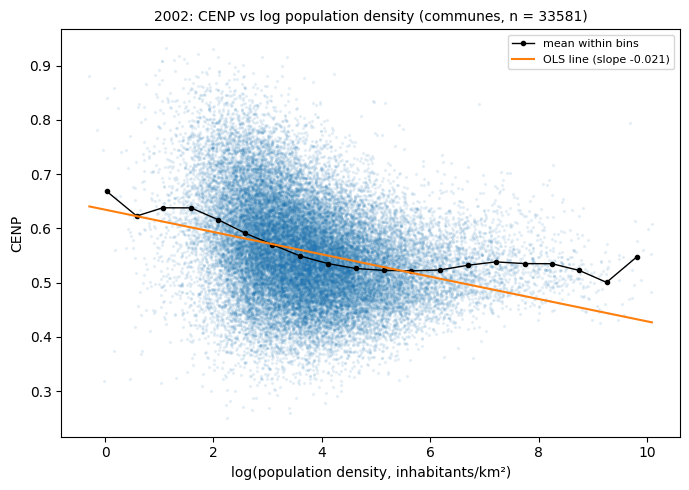

In [28]:
main_2002 = main[main["year"] == 2002]
fig, ax = plt.subplots(figsize=(7, 5))
commune_scatter(main_2002, "CENP", ax, f"2002: CENP vs log population density (communes, n = {len(main_2002)})", "CENP")
fig.tight_layout()
plt.show()

In [29]:
pd.Series(association_stats(main_2002, "CENP", weighted=True), name="CENP ~ log_density, 2002").to_frame()

,"CENP ~ log_density, 2002"
n,33581.000000
pearson_r,-0.287421
pearson_p,0.000000
spearman_rho,-0.310497
spearman_p,0.000000
ols_coef,-0.020573
ols_se,0.000374
ols_se_HC1,0.000381
ols_p,0.000000
ols_p_HC1,0.000000


In [30]:
smf.ols("CENP ~ log_density", data=main_2002).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   CENP   R-squared:                       0.083
Model:                            OLS   Adj. R-squared:                  0.083
Method:                 Least Squares   F-statistic:                     3024.
Date:                Tue, 22 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:37:40   Log-Likelihood:                 34247.
No. Observations:               33581   AIC:                        -6.849e+04
Df Residuals:                   33579   BIC:                        -6.847e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       0.6345      0.001    425.344      0.000       0.632       0.637
log_density    -0.0206      0.000    -54.989      0.000      -0.021      -0.020
==============================================================================
Omnibus:                      271.695   Durbin-Watson:                   1.650
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              287.522
Skew:                           0.199   Prob(JB):                     3.68e-63
Kurtosis:                       3.216   Cond. No.                         13.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [31]:
# Robustness: including communes flagged as possible boundary changes / using the 1999 census population for 2002
all_matched_2002 = merged[(merged["year"] == 2002) & merged["metropolitan"] & merged["insee_match"]
                          & np.isfinite(merged["log_density"]) & merged["CENP"].notna()].copy()
census99 = all_matched_2002.assign(density=all_matched_2002["population"] / all_matched_2002["surface_km2"])
with np.errstate(divide="ignore"):
    census99["log_density"] = np.log(census99["density"])
pd.DataFrame({
    "main sample": association_stats(main_2002, "CENP"),
    "incl. flagged boundary changes": association_stats(all_matched_2002, "CENP"),
    "incl. flagged, 1999 census population (previous density)": association_stats(census99[np.isfinite(census99["log_density"])], "CENP"),
})

,main sample,incl. flagged boundary changes,"incl. flagged, 1999 census population (previous density)"
n,33581.000000,34717.000000,34717.000000
pearson_r,-0.287421,-0.309756,-0.305727
pearson_p,0.000000,0.000000,0.000000
spearman_rho,-0.310497,-0.328400,-0.324935
spearman_p,0.000000,0.000000,0.000000
ols_coef,-0.020573,-0.022078,-0.021790
ols_se,0.000374,0.000364,0.000364
ols_se_HC1,0.000381,0.000378,0.000377
ols_p,0.000000,0.000000,0.000000
ols_p_HC1,0.000000,0.000000,0.000000


## 13. Main 2022 analysis

Main 2022 sample: metropolitan communes matched to INSEE. Unweighted results are the main descriptive specification.

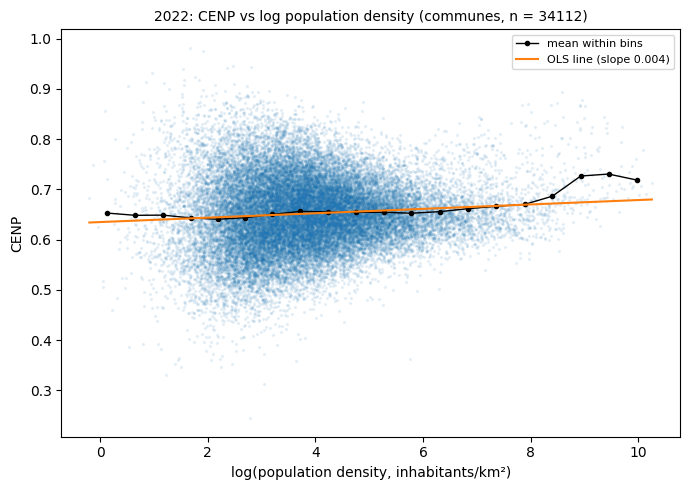

In [32]:
main_2022 = main[main["year"] == 2022]
fig, ax = plt.subplots(figsize=(7, 5))
commune_scatter(main_2022, "CENP", ax, f"2022: CENP vs log population density (communes, n = {len(main_2022)})", "CENP")
fig.tight_layout()
plt.show()

In [33]:
pd.Series(association_stats(main_2022, "CENP", weighted=True), name="CENP ~ log_density, 2022").to_frame()

,"CENP ~ log_density, 2022"
n,3.411200e+04
pearson_r,8.180033e-02
pearson_p,9.831408e-52
spearman_rho,7.698489e-02
spearman_p,5.225800e-46
ols_coef,4.379877e-03
ols_se,2.889403e-04
ols_se_HC1,2.932182e-04
ols_p,9.831408e-52
ols_p_HC1,2.720541e-50


In [34]:
smf.ols("CENP ~ log_density", data=main_2022).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   CENP   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     229.8
Date:                Tue, 22 Sep 2026   Prob (F-statistic):           9.83e-52
Time:                        22:37:46   Log-Likelihood:                 42206.
No. Observations:               34112   AIC:                        -8.441e+04
Df Residuals:                   34110   BIC:                        -8.439e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       0.6348      0.001    538.512      0.000       0.633       0.637
log_density     0.0044      0.000     15.158      0.000       0.004       0.005
==============================================================================
Omnibus:                      335.493   Durbin-Watson:                   1.298
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              462.970
Skew:                           0.134   Prob(JB):                    2.93e-101
Kurtosis:                       3.504   Cond. No.                         13.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## 14. Density-group analysis

Density deciles computed **within each year** (descriptive groupings).

In [35]:
main["density_decile"] = main.groupby("year")["density"].transform(lambda s: pd.qcut(s, 10, labels=False) + 1)

by_decile = main.groupby(["year", "density_decile"]).agg(
    n_communes=("commune_code", "size"),
    density_median=("density", "median"),
    CENP_mean=("CENP", "mean"),
    CENP_median=("CENP", "median"),
    cliff_magnitude_mean=("cliff_magnitude", "mean"),
    cliff_ratio_mean=("cliff_ratio", "mean"),
)
by_decile

n_communes  density_median  CENP_mean  CENP_median  cliff_magnitude_mean  cliff_ratio_mean
year density_decile                                                                                            
2002 1                     3359        7.745410   0.620030     0.618242              0.122623          0.892995
     2                     3358       13.158763   0.592064     0.588170              0.108931          0.888559
     3                     3358       18.043161   0.578289     0.576713              0.102995          0.886310
     4                     3358       24.256334   0.565522     0.562598              0.099200          0.885553
     5                     3358       32.312145   0.556424     0.553385              0.095764          0.885001
     6                     3358       43.116982   0.541811     0.540314              0.090462          0.881550
     7                     3358       58.956222   0.535960     0.532116              0.089218          0.882133
     8                     3358       86.035781   0.528123     0.525961              0.085474          0.881414
     9                     3358      147.611220   0.523340     0.520825              0.084224          0.881505
     10                    3358      476.871573   0.526477     0.522123              0.081298          0.881823
2022 1                     3412        7.323615   0.641915     0.640174              0.153729          0.873161
     2                     3411       13.219616   0.643207     0.639863              0.152339          0.876911
     3                     3411       19.088319   0.643709     0.640841              0.150423          0.877730
     4                     3411       26.271186   0.653456     0.650201              0.154685          0.880330
     5                     3411       35.794183   0.654998     0.655054              0.154293          0.881173
     6                     3411       48.412698   0.656060     0.654296              0.152422          0.881761
     7                     3411       67.307692   0.654064     0.653723              0.147838          0.879696
     8                     3411       98.936170   0.655712     0.654286              0.149123          0.880691
     9                     3411      169.163763   0.654196     0.651968              0.146162          0.878991
     10                    3412      529.358078   0.660188     0.653649              0.154526          0.886491

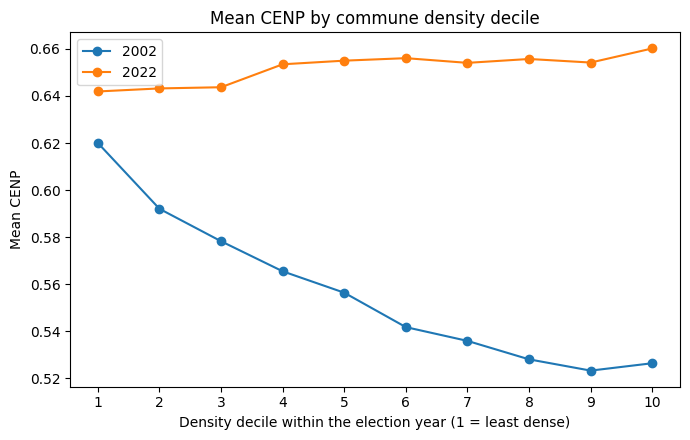

In [36]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for year in YEARS:
    d = by_decile.loc[year]
    ax.plot(d.index, d["CENP_mean"], "o-", label=str(year))
ax.set_xticks(range(1, 11))
ax.set_xlabel("Density decile within the election year (1 = least dense)")
ax.set_ylabel("Mean CENP")
ax.set_title("Mean CENP by commune density decile")
ax.legend()
fig.tight_layout()
plt.show()

## 15. Small-commune robustness checks

Coordination measures of communes with few voters are noisy. The same statistics for several minimum numbers of
expressed votes — none of these cutoffs is "the right one"; the point is to see whether tiny communes drive the
association. The WLS columns weight communes by expressed votes (secondary check).

In [37]:
CUTOFFS = [0, 100, 500, 1000]
rows = []
for year in YEARS:
    for cutoff in CUTOFFS:
        sub = main[(main["year"] == year) & (main["expressed"] >= cutoff)]
        rows.append({"year": year, "min_expressed": cutoff, **association_stats(sub, "CENP", weighted=True)})
robustness = pd.DataFrame(rows).set_index(["year", "min_expressed"])
robustness[["n", "pearson_r", "spearman_rho", "ols_coef", "ols_se", "ols_se_HC1", "ols_p", "ols_R2", "wls_coef", "wls_se_HC1", "wls_p_HC1"]]

n  pearson_r  spearman_rho  ols_coef    ols_se  ols_se_HC1          ols_p    ols_R2  wls_coef  wls_se_HC1     wls_p_HC1
year min_expressed                                                                                                                             
2002 0              33581  -0.287421     -0.310497 -0.020573  0.000374    0.000381   0.000000e+00  0.082611 -0.001673    0.001192  1.603657e-01
     100            27033  -0.165327     -0.185130 -0.010812  0.000392    0.000383  6.256148e-165  0.027333 -0.000539    0.001155  6.404903e-01
     500             9350  -0.011884     -0.020886 -0.000620  0.000540    0.000527   2.505448e-01  0.000141  0.002142    0.001281  9.438597e-02
     1000            4823   0.033659      0.041464  0.001639  0.000701    0.000700   1.940649e-02  0.001133  0.002401    0.001530  1.166298e-01
2022 0              34112   0.081800      0.076985  0.004380  0.000289    0.000293   9.831408e-52  0.006691  0.009653    0.000666  1.257717e-47
     100            28203   0.162517      0.148970  0.008358  0.000302    0.000301  3.564207e-166  0.026412  0.010059    0.000664  6.557795e-52
     500            11333   0.243370      0.186515  0.010296  0.000385    0.000430  1.824303e-152  0.059229  0.011832    0.000720  1.177141e-60
     1000            6133   0.276897      0.194656  0.010986  0.000487    0.000570  2.310887e-108  0.076672  0.013089    0.000784  1.428718e-62

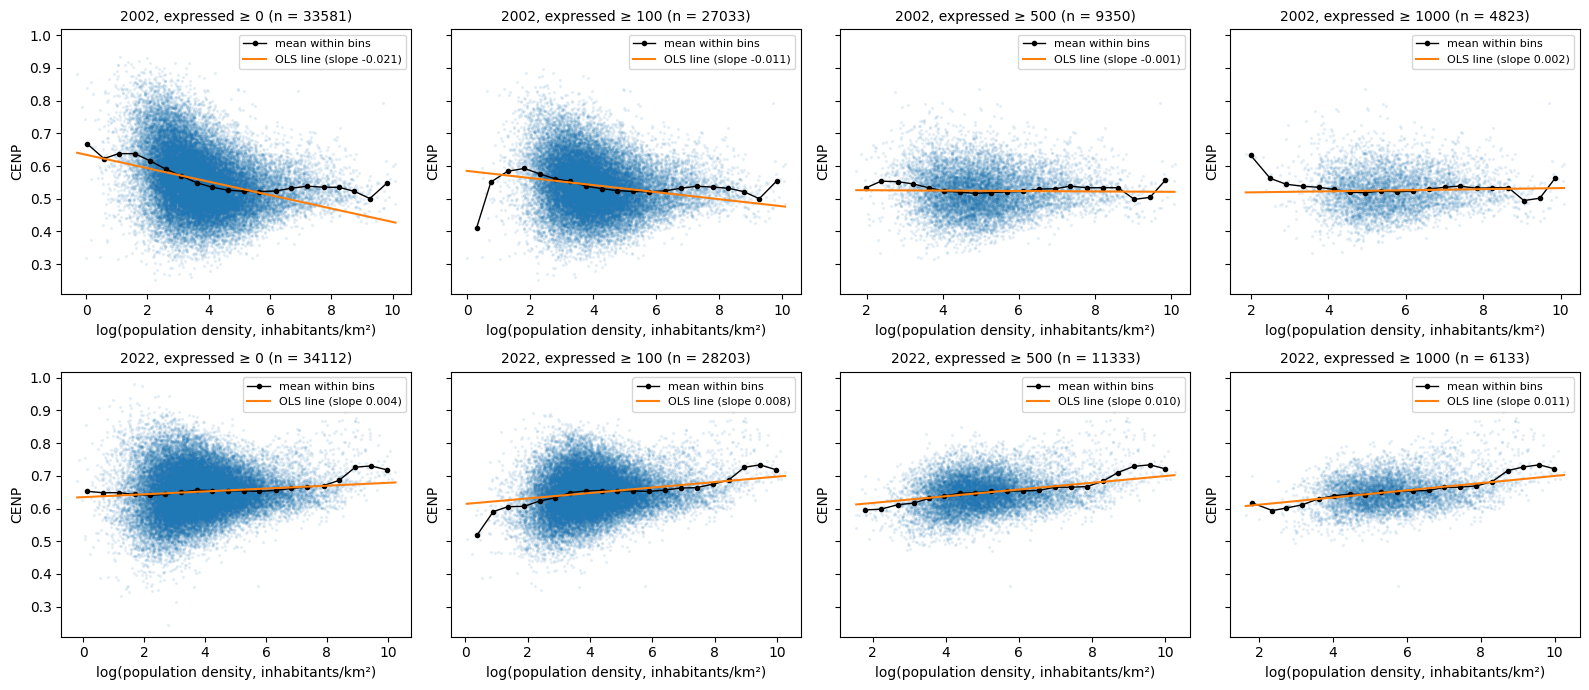

In [38]:
fig, axes = plt.subplots(len(YEARS), len(CUTOFFS), figsize=(16, 7), sharey=True)
for i, year in enumerate(YEARS):
    for j, cutoff in enumerate(CUTOFFS):
        sub = main[(main["year"] == year) & (main["expressed"] >= cutoff)]
        commune_scatter(sub, "CENP", axes[i, j], f"{year}, expressed ≥ {cutoff} (n = {len(sub)})", "CENP")
fig.tight_layout()
plt.show()

## 16. Compare 2002 and 2022 density relationships

The comparison concerns the **relationship** between density and CENP in each cross-section, not commune-by-commune
change. Note that CENP levels are not directly comparable across elections (16 vs 12 candidates, different races);
the slopes and correlations are the objects compared.

Pooled descriptive regression on the main samples:

$$\text{CENP}_{it} = \beta_0 + \beta_1 \log\text{density}_{it} + \beta_2 \mathbb{1}[t=2022] + \beta_3 \log\text{density}_{it}\times\mathbb{1}[t=2022] + \varepsilon_{it}$$

$\beta_3$ measures how much the density slope differs in 2022 compared with 2002. Standard errors clustered by
département (communes of the same département share shocks, and most communes appear in both years).

In [39]:
comparison = pd.DataFrame({year: association_stats(main[main["year"] == year], "CENP") for year in YEARS})
comparison

,2002,2022
n,33581.000000,3.411200e+04
pearson_r,-0.287421,8.180033e-02
pearson_p,0.000000,9.831408e-52
spearman_rho,-0.310497,7.698489e-02
spearman_p,0.000000,5.225800e-46
ols_coef,-0.020573,4.379877e-03
ols_se,0.000374,2.889403e-04
ols_se_HC1,0.000381,2.932182e-04
ols_p,0.000000,9.831408e-52
ols_p_HC1,0.000000,2.720541e-50


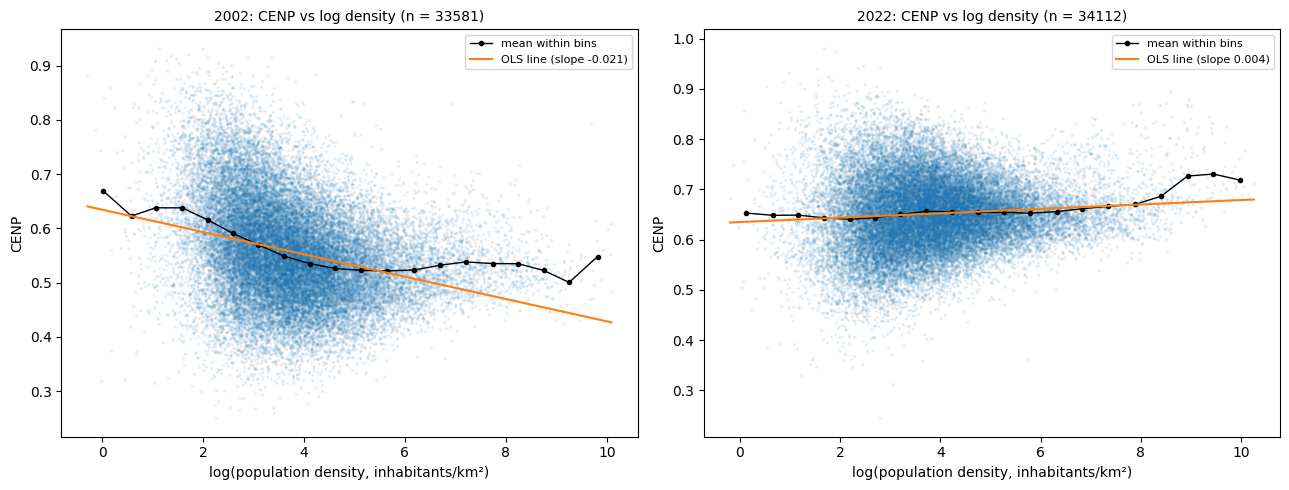

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
for ax, year in zip(axes, YEARS):
    sub = main[main["year"] == year]
    commune_scatter(sub, "CENP", ax, f"{year}: CENP vs log density (n = {len(sub)})", "CENP")
fig.tight_layout()
plt.show()

In [41]:
pooled_data = main[["CENP", "log_density", "year", "department_code", "expressed"]].copy()
pooled = smf.ols("CENP ~ log_density * C(year)", data=pooled_data).fit(
    cov_type="cluster", cov_kwds={"groups": pooled_data["department_code"]})
print(pooled.summary().tables[1])

# Same interaction for each minimum-size cutoff
rows = []
for cutoff in CUTOFFS:
    d = pooled_data[pooled_data["expressed"] >= cutoff]
    fit = smf.ols("CENP ~ log_density * C(year)", data=d).fit(cov_type="cluster", cov_kwds={"groups": d["department_code"]})
    term = "log_density:C(year)[T.2022]"
    rows.append({"min_expressed": cutoff, "n": int(fit.nobs), "slope_2002": fit.params["log_density"],
                 "difference_2022": fit.params[term], "se_cluster": fit.bse[term], "p_cluster": fit.pvalues[term]})
pd.DataFrame(rows).set_index("min_expressed")

                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                       0.6345      0.009     68.574      0.000       0.616       0.653
C(year)[T.2022]                 0.0003      0.011      0.027      0.979      -0.021       0.021
log_density                    -0.0206      0.002    -10.532      0.000      -0.024      -0.017
log_density:C(year)[T.2022]     0.0250      0.002     11.693      0.000       0.021       0.029


,n,slope_2002,difference_2022,se_cluster,p_cluster
min_expressed,,,,,
0,67693,-0.020573,0.024953,0.002134,1.380653e-31
100,55236,-0.010812,0.019170,0.002445,4.433921e-15
500,20683,-0.000620,0.010916,0.002174,5.131364e-07
1000,10956,0.001639,0.009347,0.002549,2.452025e-04


## 17. Secondary cliff measures

`cliff_magnitude` and `cliff_ratio`: same descriptive analysis as CENP (complements, not replacements).
`cliff_location` is discrete: distribution by year and across density deciles, no OLS.

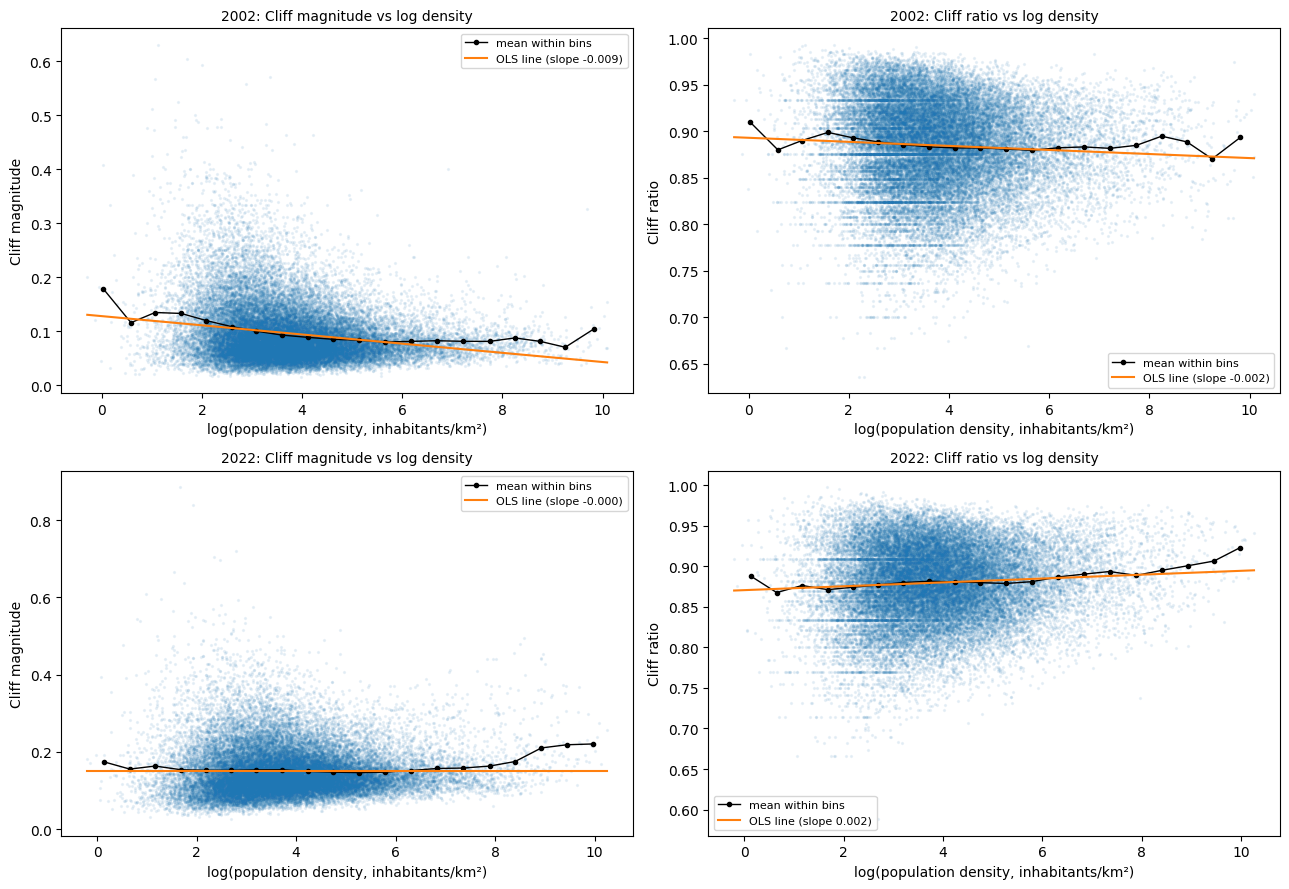

2002                                        2022                              
                      CENP cliff_magnitude   cliff_ratio          CENP cliff_magnitude   cliff_ratio
n             33581.000000    3.358100e+04  3.358100e+04  3.411200e+04    3.411200e+04  3.411200e+04
pearson_r        -0.287421   -2.045215e-01 -5.765684e-02  8.180033e-02   -4.694487e-06  6.821140e-02
pearson_p         0.000000   5.823275e-314  3.929824e-26  9.831408e-52    9.993082e-01  1.802088e-36
spearman_rho     -0.310497   -1.695818e-01 -8.580169e-02  7.698489e-02    4.481965e-02  3.879212e-02
spearman_p        0.000000   4.401589e-215  6.682782e-56  5.225800e-46    1.213336e-16  7.659204e-13
ols_coef         -0.020573   -8.501983e-03 -2.179113e-03  4.379877e-03   -2.248282e-07  2.385231e-03
ols_se            0.000374    2.220592e-04  2.059074e-04  2.889403e-04    2.593116e-04  1.888947e-04
ols_se_HC1        0.000381    2.323304e-04  1.982062e-04  2.932182e-04    2.902453e-04  1.919057e-04
ols_p             0.000000    0.000000e+00  3.929824e-26  9.831408e-52    9.993082e-01  1.802088e-36
ols_p_HC1         0.000000   1.597004e-287  4.551660e-28  2.720541e-50    9.993820e-01  2.165417e-35
ols_R2            0.082611    4.182904e-02  3.324311e-03  6.691294e-03    2.203671e-11  4.652796e-03

In [42]:
SECONDARY = {"cliff_magnitude": "Cliff magnitude", "cliff_ratio": "Cliff ratio"}
fig, axes = plt.subplots(len(YEARS), len(SECONDARY), figsize=(13, 9))
for i, year in enumerate(YEARS):
    sub = main[main["year"] == year]
    for j, (var, label) in enumerate(SECONDARY.items()):
        commune_scatter(sub.dropna(subset=[var]), var, axes[i, j], f"{year}: {label} vs log density", label)
fig.tight_layout()
plt.show()

pd.concat({year: pd.DataFrame({var: association_stats(main[main["year"] == year].dropna(subset=[var]), var)
                               for var in ["CENP", *SECONDARY]})
           for year in YEARS}, axis=1)

In [43]:
print("cliff_location — distribution by year (share of communes):")
display(pd.crosstab(main["cliff_location"], main["year"], normalize="columns").round(3))

for year in YEARS:
    sub = main[main["year"] == year]
    print(f"\n{year}: cliff_location by density decile (row shares)")
    display(pd.crosstab(sub["density_decile"], sub["cliff_location"], normalize="index").round(2))

cliff_location — distribution by year (share of communes):


year,2002,2022
cliff_location,,
1.0,0.448,0.413
2.0,0.276,0.307
3.0,0.195,0.249
4.0,0.056,0.025
5.0,0.015,0.004
6.0,0.005,0.001
7.0,0.002,0.000
8.0,0.001,0.000
9.0,0.001,0.000



2002: cliff_location by density decile (row shares)


cliff_location,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0
density_decile,,,,,,,,,,,,,,,
1,0.55,0.24,0.13,0.05,0.02,0.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.50,0.27,0.13,0.07,0.02,0.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.49,0.29,0.13,0.06,0.02,0.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.46,0.29,0.15,0.07,0.02,0.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.47,0.29,0.16,0.06,0.02,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.45,0.30,0.16,0.06,0.02,0.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.43,0.30,0.19,0.06,0.02,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.41,0.28,0.23,0.05,0.01,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.41,0.26,0.28,0.04,0.01,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



2022: cliff_location by density decile (row shares)


cliff_location,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,10.0
density_decile,,,,,,,,,
1,0.47,0.30,0.16,0.05,0.01,0.01,0.0,0.0,0.0
2,0.44,0.32,0.19,0.04,0.01,0.00,0.0,0.0,0.0
3,0.42,0.31,0.23,0.04,0.01,0.00,0.0,0.0,0.0
4,0.42,0.33,0.22,0.03,0.00,0.00,0.0,0.0,0.0
5,0.41,0.32,0.23,0.03,0.00,0.00,0.0,0.0,0.0
6,0.38,0.34,0.26,0.02,0.00,0.00,0.0,0.0,0.0
7,0.37,0.34,0.27,0.02,0.00,0.00,0.0,0.0,0.0
8,0.40,0.33,0.27,0.01,0.00,0.00,0.0,0.0,0.0
9,0.40,0.30,0.29,0.01,0.00,0.00,0.0,0.0,0.0


## 18. Save outputs

Corrected outputs (2002 density from `population_2002_interp`, section 9). The earlier files, whose 2002 density used
the 1999 census count (`coordination_density_communes.csv`, `coordination_density_communes_{2002,2022}.csv`), are not
overwritten.

* `data/processed/coordination_density_communes_corrected.csv`: all scraped communes (all territories), indices,
  INSEE population (`population`, `population_2002_interp`, `density_population`, `density_population_variable`),
  surface, density, and flags `metropolitan`, `insee_match`, `possible_boundary_change`, `main_sample` (excluded
  observations are kept, not deleted);
* one file per year: `coordination_density_communes_2002_corrected.csv`, `coordination_density_communes_2022_corrected.csv`.

Read back with `dtype={"department_code": str, "commune_code": str}`.

In [44]:
out = merged.drop(columns=["density_decile"], errors="ignore").sort_values(["year", "commune_code"])
out.to_csv(DENSITY_CORRECTED_OUT, index=False, encoding="utf-8")
for year in YEARS:
    out[out["year"] == year].to_csv(DENSITY_CORRECTED_BY_YEAR[year], index=False, encoding="utf-8")
print(f"Saved {len(out)} rows to {DENSITY_CORRECTED_OUT} ({out['main_sample'].sum()} in the main samples)")

check = pd.read_csv(DENSITY_CORRECTED_OUT, dtype={"department_code": str, "commune_code": str}, encoding="utf-8")
check[check["commune_code"].isin(["01004", "2A004", "75056"])][
    ["year", "commune_code", "commune_name", "population", "population_2002_interp", "density_population_variable",
     "density", "CENP"]]

Saved 71708 rows to data/processed/coordination_density_communes_corrected.csv (67693 in the main samples)


,year,commune_code,commune_name,population,population_2002_interp,density_population_variable,density,CENP
2,2002,01004,Ambérieu-en-Bugey,11436.0,1.196516e+04,population_2002_interp,486.388802,0.494127
11161,2002,2A004,Ajaccio,52880.0,5.728063e+04,population_2002_interp,698.288780,0.627185
30786,2002,75056,Paris,2125246.0,2.149121e+06,population_2002_interp,20390.138024,0.559642
36676,2022,01004,Ambérieu-en-Bugey,15554.0,NaN,population,632.276423,0.600602
47219,2022,2A004,Ajaccio,75343.0,NaN,population,918.481044,0.586521
65928,2022,75056,Paris,2113705.0,NaN,population,20054.127135,0.706031


## 19. Audit: data construction and robustness of the density–coordination result

Preliminary results (sections 12–16): little or no density–CENP association in 2002 once very small communes are
excluded, a positive one in 2022, stronger for larger electorates. Before interpreting this, this section audits the
data construction and re-estimates the relationship under alternative, pre-specified choices:

| § | check |
|---|---|
| 19.1 | failed commune scrapes |
| 19.2 | why observations leave `main_sample` (one reason per observation) |
| 19.3 | boundary-change rule: **strict** (`main_sample`) vs **broad** cross-sectional sample |
| 19.4 | which population measure enters the 2002 density |
| 19.5 | density validation, Paris / Lyon / Marseille |
| 19.6 | small electorates and extreme CENP values |
| 19.7–19.8 | electorate-size thresholds; vote-weighted robustness |
| 19.9 | density deciles |
| 19.10 | within-département (fixed-effects) association |
| 19.11 | pooled year × density interaction |
| 19.12 | cliff measures (secondary) |
| Audit summary | computed summary of everything above |

Rules followed throughout:

* 2002 and 2022 are **two separate cross-sections**, not a matched panel. No commune-level change (ΔCENP) is built,
  and a commune is never dropped from one year because it is absent from the other.
* All thresholds and samples are reported **side by side**; none is chosen for its result. CENP is the main measure,
  cliff measures are complements. Everything is descriptive, nothing causal.
* The cells only use objects built in sections 6–11 (`results`, `merged`, `main`, `insee`, …) plus the INSEE metadata
  file. Nothing is downloaded, nothing in `data/raw` or in the existing processed files is modified; new outputs have
  `audit` in their file name.

In [45]:
# Shared settings and helpers for section 19
ELECTORATE_THRESHOLDS = [0, 100, 500, 1000]   # minimum expressed votes; 0 = all valid communes
ALPHA = 0.05
FAIL_COLS = ["year", "level", "department_code", "commune_code", "name", "url", "error"]
CODE_DTYPES = {"department_code": str, "commune_code": str, "commune_code_source": str}
# Audit of the corrected data (2002 density from population_2002_interp); the earlier audit/ folder is kept
AUDIT_DIR = PROCESSED_DIR / "audit_corrected"
AUDIT_DIR.mkdir(parents=True, exist_ok=True)

# Commune names of the INSEE file (its metadata lists every CODGEO with its name)
insee_names = (pd.read_csv(INSEE_DIR / "meta_base-cc-serie-historique-2022.CSV", sep=";", dtype=str, encoding="utf-8")
                 .query("COD_VAR == 'CODGEO'")[["COD_MOD", "LIB_MOD"]]
                 .rename(columns={"COD_MOD": "commune_code", "LIB_MOD": "insee_name"})
                 .drop_duplicates("commune_code"))


def stats_by_threshold(samples, y="CENP", thresholds=ELECTORATE_THRESHOLDS, weighted=False):
    # association_stats (section 11) for every sample x year x minimum number of expressed votes
    rows = []
    for name, df in samples.items():
        for year in YEARS:
            for t in thresholds:
                sub = df[(df["year"] == year) & (df["expressed"] >= t)]
                rows.append({"sample": name, "year": year, "min_expressed": t,
                             **association_stats(sub, y, weighted=weighted)})
    return pd.DataFrame(rows).set_index(["sample", "year", "min_expressed"])

### 19.1 Failed commune scrapes

The failure files record every page that could not be read. They are overwritten by the *retry* cells, so they list
the failures **left after the retries** (pages recovered by a retry no longer appear).

"Expected communes" = commune URLs found on the département / alphabetical index pages. That list is only in memory
when the scraping cells ran in this session; otherwise set `REBUILD_DISCOVERY_FROM_CACHE = True` to rebuild it from
the HTML cache (**cache only** — a page missing from the cache raises an error, nothing is downloaded), or the
fallback "parsed + recorded commune failures" is used.

Territory-level entries (`no communes`: territories whose results are not published by commune) are listed but are
not commune failures. Two further checks: pages that were read correctly but report **0 expressed votes**, and INSEE
communes that have no election page at all.

In [46]:
REBUILD_DISCOVERY_FROM_CACHE = False


def discover_from_cache(year):
    # discover_all_communes() reading only the HTML cache (no network)
    global fetch
    online_fetch = fetch

    def cached_only(url):
        path = cache_path(url)
        if not path.exists():
            raise FileNotFoundError(f"not in the HTML cache: {url}")
        return gzip.decompress(path.read_bytes())

    fetch = cached_only
    try:
        return discover_all_communes(year, load_department_urls(year), limit=None)
    finally:
        fetch = online_fetch


fail_frames = []
for year in YEARS:
    in_memory = globals().get(f"failures_{year}")
    f = (pd.DataFrame(in_memory, columns=FAIL_COLS) if in_memory is not None
         else pd.read_csv(FAILURES_OUT[year], dtype=CODE_DTYPES, encoding="utf-8"))
    fail_frames.append(f)
scrape_failures = pd.concat(fail_frames, ignore_index=True)

failed_table = (scrape_failures
                .rename(columns={"name": "commune_or_territory_name", "url": "failed_url", "error": "reason"})
                [["year", "level", "department_code", "commune_code", "commune_or_territory_name", "failed_url", "reason"]]
                .sort_values(["year", "level", "department_code"]).reset_index(drop=True))
print("Recorded scrape failures (after the retry cells):")
with pd.option_context("display.max_colwidth", 120):
    display(failed_table)

scrape_rows, not_parsed = [], {}
for year in YEARS:
    parsed = set(results.loc[results["year"] == year, "commune_code"])
    f = scrape_failures[scrape_failures["year"] == year]
    commune_fail = f[f["level"] == "commune"]
    urls = globals().get(f"commune_urls_{year}")
    source = "commune URLs discovered in this session"
    if (urls is None or len(urls) == 0) and REBUILD_DISCOVERY_FROM_CACHE:
        urls = discover_from_cache(year)[0]
        source = "commune URLs rebuilt from the HTML cache"
    if urls is not None and len(urls):
        expected = set(urls["commune_code"])
        not_parsed[year] = urls[~urls["commune_code"].isin(parsed)]
    else:
        expected = parsed | set(commune_fail["commune_code"].dropna())
        source = "parsed + recorded commune failures (URL list not in memory)"
    scrape_rows.append({
        "year": year,
        "expected_communes": len(expected),
        "scraped_communes": len(expected & parsed),
        "failed_communes": len(expected - parsed),
        "pct_recovered": round(100 * len(expected & parsed) / len(expected), 3),
        "recorded_commune_page_failures": len(commune_fail),
        "failed_departement_or_index_pages": int(f["level"].isin(["department", "index page"]).sum()),
        "territories_without_commune_pages": int((f["level"] == "no communes").sum()),
        "expected_from": source,
    })
scrape_summary = pd.DataFrame(scrape_rows).set_index("year")
display(scrape_summary)
for year, df in not_parsed.items():
    report(f"{year}: every discovered commune URL has parsed results", df.empty, df)

Recorded scrape failures (after the retry cells):


,year,level,department_code,commune_code,commune_or_territory_name,failed_url,reason
0,2002,no communes,975,NaN,Saint-Pierre-et-Miquelon,https://www.archives-resultats-elections.interieur.gouv.fr/resultats/presidentielle_2002/000/975/975.php,no commune link found
1,2002,no communes,986,NaN,Wallis-et-Futuna,https://www.archives-resultats-elections.interieur.gouv.fr/resultats/presidentielle_2002/000/986/986.php,no commune link found
2,2002,no communes,987,NaN,Polynésie française,https://www.archives-resultats-elections.interieur.gouv.fr/resultats/presidentielle_2002/000/987/987.php,no commune link found
3,2002,no communes,988,NaN,Nouvelle-Calédonie,https://www.archives-resultats-elections.interieur.gouv.fr/resultats/presidentielle_2002/000/988/988.php,no commune link found
4,2022,no communes,986,NaN,Wallis-et-Futuna,https://www.archives-resultats-elections.interieur.gouv.fr/resultats/presidentielle-2022/000/986/index.php,no commune link found
5,2022,no communes,ZZ,NaN,Français établis hors de France,https://www.archives-resultats-elections.interieur.gouv.fr/resultats/presidentielle-2022/000/099/index.php,no commune link found


,expected_communes,scraped_communes,failed_communes,pct_recovered,recorded_commune_page_failures,failed_departement_or_index_pages,territories_without_commune_pages,expected_from
year,,,,,,,,
2002,36674,36674,0,100.0,0,0,4,parsed + recorded commune failures (URL list n...
2022,35034,35034,0,100.0,0,0,2,parsed + recorded commune failures (URL list n...


In [47]:
# Pages read correctly but unusable: 0 expressed votes (every ballot recorded as blank/null — typically results
# annulled for irregularities). No vote shares, hence no CENP; listed here and counted as their own exclusion reason.
urls_by_commune = results.drop_duplicates(["year", "commune_code"])[["year", "commune_code", "source_url"]]
zero_expressed = (merged.loc[merged["expressed"] <= 0,
                             ["year", "department_code", "commune_code", "commune_name", "registered", "voters",
                              "blank_null", "expressed"]]
                  .merge(urls_by_commune, on=["year", "commune_code"], how="left"))
print(f"Communes with 0 expressed votes: {len(zero_expressed)}")
with pd.option_context("display.max_colwidth", 120):
    display(zero_expressed)

# External reference: INSEE communes without any election page in that year
for year in YEARS:
    missing = (insee[~insee["commune_code"].isin(results.loc[results["year"] == year, "commune_code"])]
               .merge(insee_names, on="commune_code", how="left"))
    print(f"\n{year}: INSEE communes without election results: {len(missing)} "
          f"(codes created after {year}, uninhabited communes, ...)")
    with pd.option_context("display.max_rows", 100):
        display(missing[["commune_code", "insee_name", "D99_POP", "P06_POP", "P22_POP", "surface_km2"]])

Communes with 0 expressed votes: 14


,year,department_code,commune_code,commune_name,registered,voters,blank_null,expressed,source_url
0,2022,02,02078,Besmé,113,93,93,0,https://www.archives-resultats-elections.interieur.gouv.fr/resultats/presidentielle-2022/032/002/002078.php
1,2022,02,02093,Blérancourt,867,640,640,0,https://www.archives-resultats-elections.interieur.gouv.fr/resultats/presidentielle-2022/032/002/002093.php
2,2022,24,24130,Condat-sur-Vézère,689,550,550,0,https://www.archives-resultats-elections.interieur.gouv.fr/resultats/presidentielle-2022/075/024/024130.php
3,2022,2A,2A065,Cargèse,997,598,598,0,https://www.archives-resultats-elections.interieur.gouv.fr/resultats/presidentielle-2022/094/02A/02A065.php
4,2022,38,38211,Lieudieu,259,197,197,0,https://www.archives-resultats-elections.interieur.gouv.fr/resultats/presidentielle-2022/084/038/038211.php
5,2022,42,42152,Nandax,432,343,343,0,https://www.archives-resultats-elections.interieur.gouv.fr/resultats/presidentielle-2022/084/042/042152.php
6,2022,60,60316,Hodenc-l'Evêque,209,167,167,0,https://www.archives-resultats-elections.interieur.gouv.fr/resultats/presidentielle-2022/032/060/060316.php
7,2022,60,60391,Maysel,203,158,158,0,https://www.archives-resultats-elections.interieur.gouv.fr/resultats/presidentielle-2022/032/060/060391.php
8,2022,60,60504,Ponchon,747,606,606,0,https://www.archives-resultats-elections.interieur.gouv.fr/resultats/presidentielle-2022/032/060/060504.php
9,2022,62,62494,Léchelle,41,30,30,0,https://www.archives-resultats-elections.interieur.gouv.fr/resultats/presidentielle-2022/032/062/062494.php



2002: INSEE communes without election results: 29 (codes created after 2002, uninhabited communes, ...)


,commune_code,insee_name,D99_POP,P06_POP,P22_POP,surface_km2
0,14482,Ouézy,199,233,232,4.550000
1,22201,Plévenon,721,665,757,13.730000
2,26020,La Répara-Auriples,230,216,255,15.030000
3,31300,Lieoux,126,123,126,5.830000
4,35317,Saint-Symphorien,416,506,613,7.910000
5,47163,Mauvezin-sur-Gupie,429,452,611,15.800000
6,51201,Cuisles,137,139,127,2.770000
7,52033,Avrecourt,129,139,113,7.630000
8,52124,Chézeaux,102,72,78,10.730000
9,52266,Laneuville-à-Rémy,51,57,66,5.960000



2022: INSEE communes without election results: 18 (codes created after 2022, uninhabited communes, ...)


,commune_code,insee_name,D99_POP,P06_POP,P22_POP,surface_km2
0,12218,Conques-en-Rouergue,1685,1679,1555,106.23
1,14581,Aurseulles,1745,1913,1908,46.00
2,15031,Celles,239,235,217,18.35
3,15035,Chalinargues,433,435,311,27.55
4,15047,Chavagnac,94,102,91,16.58
5,15171,Sainte-Anastasie,167,162,124,15.88
6,27676,Les Trois Lacs,1523,1688,1748,36.53
7,49126,Orée d'Anjou,12296,14189,16975,156.34
8,55039,Beaumont-en-Verdunois,0,0,0,7.87
9,55050,Bezonvaux,0,0,0,9.23


**Cross-sections, not a panel.** A commune missing (failed scrape, annulled results, no INSEE match) in one year is
excluded from **that year only**. The 2002 and 2022 analyses each keep every valid observation of their own year;
restricting both years to a common set of communes would discard valid information and is only needed for a matched
panel with harmonised boundaries, which is not built here. The cell below shows how many communes are specific to one
year — they are kept.

In [48]:
codes_in_main = {year: set(main.loc[main["year"] == year, "commune_code"]) for year in YEARS}
print("main_sample communes: only in 2002:", len(codes_in_main[2002] - codes_in_main[2022]),
      "| only in 2022:", len(codes_in_main[2022] - codes_in_main[2002]),
      "| in both years:", len(codes_in_main[2002] & codes_in_main[2022]), "— all kept in their own year")

main_sample communes: only in 2002: 255 | only in 2022: 786 | in both years: 33326 — all kept in their own year


### 19.2 Why observations leave `main_sample`

`main_sample` (section 10) = metropolitan **and** matched to INSEE **and** finite `log_density` **and** CENP available
**and not** `possible_boundary_change` (registered / population outside [0.4, 1.2]).

Each election observation receives the **first** reason that applies, in this order (so reasons do not overlap and
add up to the total); a second table gives the non-exclusive flag counts. The unmatched codes are split using the
2022 election results only as a *diagnostic*: a 2002 code absent from the 2022 results disappeared in a merger between
2002 and 2022; a code still present in the 2022 results but not in the INSEE file disappeared **after** the 2022
election (the INSEE file uses a commune geography later than 2022 — see 19.3).

The reason assignment is checked to reproduce `main_sample` exactly. Examples of every category follow (largest
electorates first, i.e. the most consequential exclusions).

In [49]:
def name_key(name):
    # commune name normalised for comparison: accents, case, punctuation, St/Ste, article in parentheses
    s = str(name).replace("œ", "oe").replace("Œ", "OE").replace("æ", "ae").replace("Æ", "AE")
    m = re.fullmatch(r"(.*?)\s*\((l'|l’|le|la|les)\)\s*", s, flags=re.I)
    if m:
        s = f"{m.group(2)} {m.group(1)}"
    s = norm_text(s)
    s = re.sub(r"\bste\b", "sainte", s)
    s = re.sub(r"\bst\b", "saint", s)
    return s.replace(" ", "")


audit = merged.merge(insee_names, on="commune_code", how="left", validate="many_to_one")
audit["valid_density"] = (audit["insee_match"] & (audit["density_population"] > 0) & (audit["surface_km2"] > 0)
                          & np.isfinite(audit["log_density"]))
audit["ratio_low"] = audit["insee_match"] & (audit["registered_to_population"] < 0.4)
audit["ratio_high"] = audit["insee_match"] & (audit["registered_to_population"] > 1.2)
audit["name_mismatch"] = audit["insee_match"] & (audit["commune_name"].map(name_key) != audit["insee_name"].map(name_key))

unmatched_deps = set(map(tuple, audit.loc[audit["metropolitan"] & ~audit["insee_match"],
                                          ["year", "department_code"]].itertuples(index=False)))
audit["dep_has_unmatched"] = [(y, d) in unmatched_deps for y, d in zip(audit["year"], audit["department_code"])]
codes_2022 = set(results.loc[results["year"] == 2022, "commune_code"])

RETAINED = "retained (main_sample)"
EXCLUSION_RULES = [
    ("overseas", ~audit["metropolitan"]),
    ("0 expressed votes (all ballots blank/null)", audit["expressed"].fillna(0) <= 0),
    ("indices missing (other)", audit["CENP"].isna()),
    ("Paris/Lyon/Marseille arrondissement code", audit["commune_code"].isin(INSEE_ARRONDISSEMENTS)),
    ("no INSEE match: 2002 code absent from 2022 results (merger 2002–2022)",
     ~audit["insee_match"] & (audit["year"] == 2002) & ~audit["commune_code"].isin(codes_2022)),
    ("no INSEE match: code in 2022 results, not in INSEE file (merger after 2022)", ~audit["insee_match"]),
    ("INSEE population missing", audit["population"].isna()),
    ("INSEE population = 0", audit["population"] <= 0),
    ("INSEE surface missing or <= 0", ~(audit["surface_km2"] > 0)),
    ("non-finite log density (other)", ~np.isfinite(audit["log_density"])),
    ("boundary flag: registered/population < 0.4", audit["registered_to_population"] < 0.4),
    ("boundary flag: registered/population > 1.2", audit["registered_to_population"] > 1.2),
]
audit["exclusion_reason"] = np.select([cond.to_numpy(dtype=bool) for _, cond in EXCLUSION_RULES],
                                      [label for label, _ in EXCLUSION_RULES], default=RETAINED)

mismatch = (audit["exclusion_reason"] == RETAINED) != audit["main_sample"]
report("exclusion reasons reproduce main_sample exactly", not mismatch.any(),
       audit.loc[mismatch, ["year", "commune_code", "commune_name", "exclusion_reason", "main_sample"]])

reason_order = [label for label, _ in EXCLUSION_RULES] + [RETAINED]
exclusion_counts = (pd.crosstab(audit["exclusion_reason"], audit["year"])
                      .reindex(reason_order, fill_value=0))
metro_totals = audit[audit["metropolitan"]].groupby("year").size()
exclusion_pct_metro = (exclusion_counts.drop(index="overseas") / metro_totals * 100).round(2)
print("Observations by primary exclusion reason (all election observations):")
display(pd.concat({"n": exclusion_counts, "% of metropolitan": exclusion_pct_metro}, axis=1))

metro = audit[audit["metropolitan"]]
sample_counts = metro.groupby("year").agg(
    metropolitan_election_obs=("commune_code", "size"),
    with_CENP=("CENP", lambda s: int(s.notna().sum())),
    insee_matched=("insee_match", "sum"),
    valid_density=("valid_density", "sum"),
    main_sample=("main_sample", "sum"),
)
sample_counts["pct_retained"] = (100 * sample_counts["main_sample"] / sample_counts["metropolitan_election_obs"]).round(2)
display(sample_counts)

print("Non-exclusive flags among metropolitan observations (one observation can have several):")
display(metro.assign(no_insee_match=~metro["insee_match"], zero_expressed=metro["expressed"].fillna(0) <= 0,
                     invalid_density=~metro["valid_density"])
        .groupby("year")[["zero_expressed", "no_insee_match", "invalid_density", "ratio_low", "ratio_high",
                          "possible_boundary_change", "name_mismatch"]].sum())

print("Are the excluded observations different? (median log density / expressed, mean CENP by reason)")
display(metro.groupby(["year", "exclusion_reason"]).agg(
    n=("commune_code", "size"), median_log_density=("log_density", "median"),
    median_expressed=("expressed", "median"), mean_CENP=("CENP", "mean")).round(3))

[OK] exclusion reasons reproduce main_sample exactly
Observations by primary exclusion reason (all election observations):


n        % of metropolitan       
year                                                 2002   2022              2002   2022
exclusion_reason                                                                         
overseas                                              115    214               NaN    NaN
0 expressed votes (all ballots blank/null)              0     13              0.00   0.04
indices missing (other)                                 0      0              0.00   0.00
Paris/Lyon/Marseille arrondissement code                0      0              0.00   0.00
no INSEE match: 2002 code absent from 2022 resu...   1750      0              4.79   0.00
no INSEE match: code in 2022 results, not in IN...     92     92              0.25   0.26
INSEE population missing                                0      0              0.00   0.00
INSEE population = 0                                    0      0              0.00   0.00
INSEE surface missing or <= 0                           0      0              0.00   0.00
non-finite log density (other)                          0      0              0.00   0.00
boundary flag: registered/population < 0.4            250     30              0.68   0.09
boundary flag: registered/population > 1.2            886    573              2.42   1.65
retained (main_sample)                              33581  34112             91.85  97.97

,metropolitan_election_obs,with_CENP,insee_matched,valid_density,main_sample,pct_retained
year,,,,,,
2002,36559,36559,34717,34717,33581,91.85
2022,34820,34807,34728,34728,34112,97.97


Non-exclusive flags among metropolitan observations (one observation can have several):


,zero_expressed,no_insee_match,invalid_density,ratio_low,ratio_high,possible_boundary_change,name_mismatch
year,,,,,,,
2002,0,1842,1842,250,886,1136,877
2022,13,92,92,30,573,603,136


Are the excluded observations different? (median log density / expressed, mean CENP by reason)


n  median_log_density  median_expressed  mean_CENP
year exclusion_reason                                                                                          
2002 boundary flag: registered/population < 0.4            250               3.695             395.0      0.534
     boundary flag: registered/population > 1.2            886               1.697              58.0      0.658
     no INSEE match: 2002 code absent from 2022 resu...   1750                 NaN             161.0      0.564
     no INSEE match: code in 2022 results, not in IN...     92                 NaN             158.0      0.571
     retained (main_sample)                              33581               3.620             241.0      0.557
2022 0 expressed votes (all ballots blank/null)             13               4.055               0.0        NaN
     boundary flag: registered/population < 0.4             30               4.405             405.5      0.713
     boundary flag: registered/population > 1.2            573               1.559              55.0      0.628
     no INSEE match: code in 2022 results, not in IN...     92                 NaN             162.0      0.650
     retained (main_sample)                              34112               3.728             286.0      0.652

In [50]:
EXAMPLE_COLS = ["year", "department_code", "commune_code", "commune_name", "insee_name", "registered", "expressed",
                "population", "surface_km2", "registered_to_population", "density", "CENP"]
N_EXAMPLES = 10
for (year, reason), g in audit[audit["exclusion_reason"] != RETAINED].groupby(["year", "exclusion_reason"]):
    print(f"\n{year} — {reason}: {len(g)} observations (up to {N_EXAMPLES}, largest electorates first)")
    display(g.sort_values("registered", ascending=False)[EXAMPLE_COLS].head(N_EXAMPLES))


2002 — boundary flag: registered/population < 0.4: 250 observations (up to 10, largest electorates first)


,year,department_code,commune_code,commune_name,insee_name,registered,expressed,population,surface_km2,registered_to_population,density,CENP
36318,2002,93,93066,Saint-Denis,Saint-Denis,32469,19131,111648.0,15.77,0.290816,7441.313654,0.468051
30501,2002,74,74010,Annecy,Annecy,28671,19561,112379.0,66.93,0.255128,1705.896810,0.509063
18850,2002,50,50129,Cherbourg-Octeville,Cherbourg-en-Cotentin,23873,15972,88588.0,68.54,0.269483,1273.557340,0.515162
36287,2002,93,93001,Aubervilliers,Aubervilliers,21711,13332,63136.0,5.76,0.343877,11699.300378,0.507311
36125,2002,91,91228,Evry,Évry-Courcouronnes,20799,13448,63391.0,12.70,0.328107,5113.242974,0.515700
36311,2002,93,93055,Pantin,Pantin,19548,12591,49919.0,5.01,0.391594,10270.478019,0.450859
36320,2002,93,93071,Sevran,Sevran,18795,11917,47063.0,7.28,0.399358,6697.115333,0.510868
32183,2002,78,78361,Mantes-la-Jolie,Mantes-la-Jolie,15387,10077,43672.0,9.38,0.352331,4575.345170,0.595714
28651,2002,69,69256,Vaulx-en-Velin,Vaulx-en-Velin,14818,9301,39154.0,20.95,0.378454,1892.176489,0.514728
34402,2002,85,85194,Les Sables-d'Olonne,Les Sables-d'Olonne,13571,8515,38500.0,85.66,0.352494,461.242108,0.616895



2002 — boundary flag: registered/population > 1.2: 886 observations (up to 10, largest electorates first)


,year,department_code,commune_code,commune_name,insee_name,registered,expressed,population,surface_km2,registered_to_population,density,CENP
7816,2002,22,22179,Fréhel,Fréhel,2102,1589,1326.0,18.91,1.585219,75.714239,0.514096
2058,2002,06,06127,Saint-Martin-Vésubie,Saint-Martin-Vésubie,1344,832,1098.0,97.13,1.224044,12.276289,0.630202
2005,2002,06,06074,Lantosque,Lantosque,1295,912,1019.0,44.76,1.270854,24.626432,0.591667
2084,2002,06,06153,Valdeblore,Valdeblore,923,665,686.0,94.16,1.345481,7.789980,0.611035
2082,2002,06,06151,Utelle,Utelle,838,582,488.0,67.97,1.717213,8.171440,0.568682
1944,2002,06,06013,Belvédère,Belvédère,767,528,495.0,75.41,1.549495,7.535242,0.574854
2093,2002,06,06162,La Brigue,La Brigue,754,520,595.0,91.77,1.267227,6.644387,0.677574
27274,2002,66,66004,Les Angles,Les Angles,742,466,590.0,43.20,1.257627,13.436782,0.429584
2002,2002,06,06071,Guillaumes,Guillaumes,707,462,589.0,87.02,1.200340,7.274988,0.456635
2004,2002,06,06073,Isola,Isola,649,430,526.0,97.98,1.233840,5.560669,0.618489



2002 — no INSEE match: 2002 code absent from 2022 results (merger 2002–2022): 1750 observations (up to 10, largest electorates first)


...

,year,department_code,commune_code,commune_name,insee_name,registered,expressed,population,surface_km2,registered_to_population,density,CENP
60983,2022,62,62826,Le Touquet-Paris-Plage,Le Touquet-Paris-Plage,5342,4150,4223.0,15.31,1.264978,275.832789,0.832040
53004,2022,44,44136,Préfailles,Préfailles,1610,1270,1246.0,4.88,1.292135,255.327869,0.693067
41740,2022,15,15141,Neussargues en Pinatelle,Neussargues-Moissac,1570,1144,834.0,13.62,1.882494,61.233480,0.583224
38695,2022,06,06153,Valdeblore,Valdeblore,1012,811,834.0,94.16,1.213429,8.857264,0.560403
38615,2022,06,06073,Isola,Isola,886,653,652.0,97.98,1.358896,6.654419,0.560608
69090,2022,83,83152,Rayol-Canadel-sur-Mer,Rayol-Canadel-sur-Mer,838,622,644.0,6.83,1.301242,94.289898,0.658521
62548,2022,66,66004,Les Angles,Les Angles,793,548,584.0,43.20,1.357877,13.518519,0.617963
59163,2022,60,60054,Les Hauts-Talicans,Beaumont-les-Nonains,781,548,337.0,9.53,2.317507,35.362015,0.674440
42494,2022,17,17286,Les Portes-en-Ré,Les Portes-en-Ré,739,573,582.0,8.51,1.269759,68.390129,0.710780
38555,2022,06,06013,Belvédère,Belvédère,736,539,595.0,75.41,1.236975,7.890200,0.629896



2022 — no INSEE match: code in 2022 results, not in INSEE file (merger after 2022): 92 observations (up to 10, largest electorates first)


,year,department_code,commune_code,commune_name,insee_name,registered,expressed,population,surface_km2,registered_to_population,density,CENP
54234,2022,49,49069,Orée-d'Anjou,NaN,12460,9426,NaN,NaN,NaN,NaN,0.661504
71249,2022,93,93059,Pierrefitte-sur-Seine,NaN,10985,7445,NaN,NaN,NaN,NaN,0.853531
63787,2022,69,69152,Pierre-Bénite,NaN,6388,4416,NaN,NaN,NaN,NaN,0.668610
63793,2022,69,69159,Porte des Pierres Dorées,NaN,3046,2492,NaN,NaN,NaN,NaN,0.617419
41514,2022,14,14623,Saint-Martin-de-Fontenay,NaN,2014,1477,NaN,NaN,NaN,NaN,0.656009
65283,2022,72,72287,Saint-Gervais-en-Belin,NaN,1632,1248,NaN,NaN,NaN,NaN,0.666251
40752,2022,12,12076,Conques-en-Rouergue,NaN,1446,1112,NaN,NaN,NaN,NaN,0.567307
41091,2022,14,14011,Aurseulles,NaN,1415,1076,NaN,NaN,NaN,NaN,0.624224
46043,2022,27,27058,Les Trois Lacs,NaN,1402,1065,NaN,NaN,NaN,NaN,0.675250
69263,2022,85,85021,La Bernardière,NaN,1383,1103,NaN,NaN,NaN,NaN,0.711282



2022 — overseas: 214 observations (up to 10, largest electorates first)


,year,department_code,commune_code,commune_name,insee_name,registered,expressed,population,surface_km2,registered_to_population,density,CENP
71592,2022,974,97411,Saint-Denis,Saint-Denis,107461,57464,156149.0,142.79,0.688195,1093.556972,0.712396
71596,2022,974,97415,Saint-Paul,Saint-Paul,85567,41966,106220.0,241.28,0.805564,440.235411,0.733278
71692,2022,988,98818,Nouméa,NaN,72587,32202,NaN,NaN,NaN,NaN,0.719225
71597,2022,974,97416,Saint-Pierre,Saint-Pierre,66442,35837,85254.0,95.99,0.779342,888.155016,0.734663
71603,2022,974,97422,Le Tampon,Le Tampon,64236,36267,81964.0,165.43,0.783710,495.460316,0.731553
71534,2022,972,97209,Fort-de-France,Fort-de-France,60281,24131,75165.0,44.21,0.801982,1700.180955,0.826744
71595,2022,974,97414,Saint-Louis,Saint-Louis,43938,18167,54478.0,98.90,0.806527,550.839232,0.784379
71494,2022,971,97101,Les Abymes,Les Abymes,40493,17880,51760.0,81.25,0.782322,637.046154,0.888755
71590,2022,974,97409,Saint-André,Saint-André,40298,17904,57546.0,53.07,0.700275,1084.341436,0.769675
71593,2022,974,97412,Saint-Joseph,Saint-Joseph,31401,18779,38992.0,178.50,0.805319,218.442577,0.793906


### 19.3 Boundary changes: strict vs broad cross-sectional sample

**What the current rule does.** The INSEE populations and surfaces are in one (recent) commune geography. For each
election year, a commune is usable if its election result and its INSEE population/surface describe the **same
territory in that year**. The current flag `possible_boundary_change` excludes every matched commune with
registered / population outside [0.4, 1.2], in **both** years. Two problems:

* **Upper bound (> 1.2).** If the INSEE unit is *larger* than the election unit (chef-lieu of a later *commune
  nouvelle*), the ratio is too **low**. A ratio above 1.2 is not a sign of a boundary change: it typically reflects
  electors without main residence in the commune (second homes, very small communes). Excluding these removes valid
  observations.
* **Geography of the INSEE file.** Section 8 assumed 2022 geography, but section 10 finds 2022 election communes
  without INSEE code, i.e. the file's geography is **later than April 2022**. So 2022 is also exposed to (few)
  mergers, while in 2022 a low ratio can also be genuine (low registration).
* Conversely, a chef-lieu whose commune nouvelle absorbed only small communes can keep a ratio in [0.4, 1.2] while the
  INSEE unit is larger: the ratio rule then **keeps** a mismatched unit.

**Samples compared** (neither is modified in `main`):

* **strict** = existing `main_sample` (current rules, unchanged);
* **broad** = metropolitan, matched, valid density, CENP available, and **no positive evidence that the INSEE code now
  designates a different territory**, where evidence = the INSEE name differs from the election name (after
  normalisation) **or** registered/population < 0.4 in a département where at least one commune of that election
  year has disappeared (a merger that could have enlarged it). Ratios > 1.2 are kept.
* **all matched** (sensitivity only) = no geography rule at all.

The name comparison is heuristic: every mismatch is displayed below so spelling-only differences can be checked. A
fully exact treatment would use INSEE's commune-change tables (*table de passage*) to re-aggregate populations to each
election's geography; this is not done here.

In [51]:
m22 = audit[(audit["year"] == 2022) & audit["metropolitan"]]
print("2022 metropolitan election communes without INSEE code:", int((~m22["insee_match"]).sum()),
      "→ if > 0, the INSEE file's commune geography is later than the April 2022 election")

cand = audit[audit["metropolitan"] & audit["valid_density"] & audit["CENP"].notna()].copy()
cand["ratio_class"] = np.select([cand["registered_to_population"] < 0.4, cand["registered_to_population"] > 1.2],
                                ["< 0.4", "> 1.2"], "0.4–1.2")
print("Name mismatch × registered/population class (metropolitan, matched, valid density):")
display(pd.crosstab([cand["year"], cand["name_mismatch"]], cand["ratio_class"], margins=True))

audit["evidence_other_unit"] = audit["insee_match"] & (audit["name_mismatch"]
                                                       | (audit["ratio_low"] & audit["dep_has_unmatched"]))
audit["all_matched_sample"] = audit["metropolitan"] & audit["valid_density"] & audit["CENP"].notna()
audit["broad_sample"] = audit["all_matched_sample"] & ~audit["evidence_other_unit"]
audit["sample_membership"] = np.select(
    [audit["main_sample"] & audit["broad_sample"], audit["main_sample"], audit["broad_sample"]],
    ["strict and broad", "strict only", "broad only"], "neither")

print("Composition (metropolitan, matched, valid density):")
display(audit[audit["all_matched_sample"]].groupby(["year", "sample_membership"]).agg(
    n=("commune_code", "size"), median_density=("density", "median"), median_expressed=("expressed", "median"),
    mean_CENP=("CENP", "mean"), mean_ratio=("registered_to_population", "mean")).round(3))

2022 metropolitan election communes without INSEE code: 92 → if > 0, the INSEE file's commune geography is later than the April 2022 election
Name mismatch × registered/population class (metropolitan, matched, valid density):


ratio_class         0.4–1.2  < 0.4  > 1.2    All
year name_mismatch                              
2002 False            32935     26    879  33840
     True               646    224      7    877
2022 False            33992     18    569  34579
     True               120     12      4    136
All                   67693    280   1459  69432

Composition (metropolitan, matched, valid density):


n  median_density  median_expressed  mean_CENP  mean_ratio
year sample_membership                                                                
2002 broad only           879           5.455              58.0      0.658       1.585
     neither              257          39.631             374.0      0.535       0.334
     strict and broad   32935          37.288             238.0      0.557       0.814
     strict only          646          42.696             443.5      0.537       0.629
2022 broad only           581           4.876              56.0      0.629       1.495
     neither               22          54.347             428.5      0.698       0.651
     strict and broad   33992          41.667             286.0      0.652       0.796
     strict only          120          34.348             358.5      0.636       0.718

In [52]:
SHOW = ["year", "department_code", "commune_code", "commune_name", "insee_name", "registered", "population",
        "registered_to_population", "density", "main_sample", "broad_sample"]
with pd.option_context("display.max_rows", 200):
    print("Name mismatches (check for spelling-only differences), largest electorates first:")
    display(audit[audit["name_mismatch"]].sort_values(["year", "registered"], ascending=[True, False])[SHOW].head(150))
    print("In strict but with a name mismatch (ratio in [0.4, 1.2] although the INSEE unit may be larger):")
    display(audit[audit["main_sample"] & audit["name_mismatch"]].sort_values("registered", ascending=False)[SHOW].head(50))
    print("Excluded from strict only because registered/population > 1.2 (kept in broad):")
    display(audit[(audit["exclusion_reason"] == "boundary flag: registered/population > 1.2")]
            .sort_values("registered", ascending=False)[SHOW].head(30))
    print("Excluded from strict because ratio < 0.4 but kept in broad (no merger in the département that year):")
    display(audit[audit["ratio_low"] & audit["broad_sample"]].sort_values("registered", ascending=False)[SHOW].head(30))

Name mismatches (check for spelling-only differences), largest electorates first:


,year,department_code,commune_code,commune_name,insee_name,registered,population,registered_to_population,density,main_sample,broad_sample
18850,2002,50,50129,Cherbourg-Octeville,Cherbourg-en-Cotentin,23873,88588.0,0.269483,1273.557340,False,False
36125,2002,91,91228,Evry,Évry-Courcouronnes,20799,63391.0,0.328107,5113.242974,False,False
32101,2002,78,78158,Le Chesnay,Le Chesnay-Rocquencourt,18927,31748.0,0.596164,4586.313845,True,False
36319,2002,93,93070,Saint-Ouen,Saint-Ouen-sur-Seine,16216,39722.0,0.408237,9530.071277,True,False
28546,2002,69,69149,Oullins,Oullins-Pierre-Bénite,15056,35146.0,0.428384,3982.826273,True,False
35383,2002,88,88413,Saint-Dié,Saint-Dié-des-Vosges,14984,22569.0,0.663920,480.323920,True,False
36462,2002,95,95306,Herblay,Herblay-sur-Seine,14275,23083.0,0.618420,1901.111767,True,False
5225,2002,14,14762,Vire,Vire Normandie,9065,18564.0,0.488311,133.629260,True,False
20443,2002,53,53062,Château-Gontier,Château-Gontier-sur-Mayenne,8131,15701.0,0.517865,230.062923,True,False
7735,2002,22,22093,Lamballe,Lamballe-Armor,7942,13578.0,0.584917,106.783625,True,False


In strict but with a name mismatch (ratio in [0.4, 1.2] although the INSEE unit may be larger):


,year,department_code,commune_code,commune_name,insee_name,registered,population,registered_to_population,density,main_sample,broad_sample
32101,2002,78,78158,Le Chesnay,Le Chesnay-Rocquencourt,18927,31748.0,0.596164,4586.313845,True,False
63785,2022,69,69149,Oullins,Oullins-Pierre-Bénite,16915,37928.0,0.445977,4271.171171,True,False
36319,2002,93,93070,Saint-Ouen,Saint-Ouen-sur-Seine,16216,39722.0,0.408237,9530.071277,True,False
28546,2002,69,69149,Oullins,Oullins-Pierre-Bénite,15056,35146.0,0.428384,3982.826273,True,False
35383,2002,88,88413,Saint-Dié,Saint-Dié-des-Vosges,14984,22569.0,0.663920,480.323920,True,False
36462,2002,95,95306,Herblay,Herblay-sur-Seine,14275,23083.0,0.618420,1901.111767,True,False
5225,2002,14,14762,Vire,Vire Normandie,9065,18564.0,0.488311,133.629260,True,False
20443,2002,53,53062,Château-Gontier,Château-Gontier-sur-Mayenne,8131,15701.0,0.517865,230.062923,True,False
7735,2002,22,22093,Lamballe,Lamballe-Armor,7942,13578.0,0.584917,106.783625,True,False
36380,2002,95,95019,Arnouville-lès-Gonesse,Arnouville,6995,12291.0,0.569116,4408.600294,True,False


Excluded from strict only because registered/population > 1.2 (kept in broad):


,year,department_code,commune_code,commune_name,insee_name,registered,population,registered_to_population,density,main_sample,broad_sample
60983,2022,62,62826,Le Touquet-Paris-Plage,Le Touquet-Paris-Plage,5342,4223.0,1.264978,275.832789,False,True
7816,2002,22,22179,Fréhel,Fréhel,2102,1326.0,1.585219,75.714239,False,True
53004,2022,44,44136,Préfailles,Préfailles,1610,1246.0,1.292135,255.327869,False,True
41740,2022,15,15141,Neussargues en Pinatelle,Neussargues-Moissac,1570,834.0,1.882494,61.233480,False,False
2058,2002,06,06127,Saint-Martin-Vésubie,Saint-Martin-Vésubie,1344,1098.0,1.224044,12.276289,False,True
2005,2002,06,06074,Lantosque,Lantosque,1295,1019.0,1.270854,24.626432,False,True
38695,2022,06,06153,Valdeblore,Valdeblore,1012,834.0,1.213429,8.857264,False,True
2084,2002,06,06153,Valdeblore,Valdeblore,923,686.0,1.345481,7.789980,False,True
38615,2022,06,06073,Isola,Isola,886,652.0,1.358896,6.654419,False,True
69090,2022,83,83152,Rayol-Canadel-sur-Mer,Rayol-Canadel-sur-Mer,838,644.0,1.301242,94.289898,False,True


Excluded from strict because ratio < 0.4 but kept in broad (no merger in the département that year):


,year,department_code,commune_code,commune_name,insee_name,registered,population,registered_to_population,density,main_sample,broad_sample
59282,2022,60,60175,Creil,Creil,14464,36494.0,0.396339,3290.712353,False,True
71306,2022,94,94078,Villeneuve-Saint-Georges,Villeneuve-Saint-Georges,11557,36170.0,0.319519,4133.714286,False,True
71063,2022,91,91235,Fleury-Mérogis,Fleury-Mérogis,3749,13816.0,0.271352,2122.273425,False,True
65753,2022,74,74118,Étrembières,Étrembières,1035,2624.0,0.394436,483.241252,False,True
67001,2022,77,77384,Réau,Réau,774,2045.0,0.378484,153.528529,False,True
69020,2022,83,83082,Montferrat,Montferrat,481,1720.0,0.279651,50.573361,False,True
69199,2022,84,84107,Saint-Christol,Saint-Christol,452,1416.0,0.319209,30.729167,False,True
58012,2022,57,57614,Saint-Jean-Kourtzerode,Saint-Jean-Kourtzerode,242,674.0,0.359050,426.582278,False,True
57057,2022,55,55443,Rouvres-en-Woëvre,Rouvres-en-Woëvre,214,589.0,0.363328,35.185185,False,True
56608,2022,54,54523,Thuilley-aux-Groseilles,Thuilley-aux-Groseilles,128,434.0,0.294931,47.587719,False,True


In [53]:
strict = audit[audit["main_sample"]].copy()
broad = audit[audit["broad_sample"]].copy()
all_matched = audit[audit["all_matched_sample"]].copy()
SAMPLES = {"strict": strict, "broad": broad}

boundary_comparison = stats_by_threshold({**SAMPLES, "all matched (no geography rule)": all_matched})
print("CENP ~ log_density under the three geography rules:")
display(boundary_comparison[["n", "pearson_r", "spearman_rho", "ols_coef", "ols_se_HC1", "ols_p_HC1", "ols_R2"]].round(5))

CENP ~ log_density under the three geography rules:


n  pearson_r  spearman_rho  ols_coef  ols_se_HC1  ols_p_HC1   ols_R2
sample                          year min_expressed                                                                          
strict                          2002 0              33581   -0.28742      -0.31050  -0.02057     0.00038    0.00000  0.08261
                                     100            27033   -0.16533      -0.18513  -0.01081     0.00038    0.00000  0.02733
                                     500             9350   -0.01188      -0.02089  -0.00062     0.00053    0.23880  0.00014
                                     1000            4823    0.03366       0.04146   0.00164     0.00070    0.01930  0.00113
                                2022 0              34112    0.08180       0.07698   0.00438     0.00029    0.00000  0.00669
                                     100            28203    0.16252       0.14897   0.00836     0.00030    0.00000  0.02641
                                     500            11333    0.24337       0.18652   0.01030     0.00043    0.00000  0.05923
                                     1000            6133    0.27690       0.19466   0.01099     0.00057    0.00000  0.07667
broad                           2002 0              33814   -0.31261      -0.33148  -0.02231     0.00038    0.00000  0.09772
                                     100            26642   -0.17663      -0.19322  -0.01153     0.00039    0.00000  0.03120
                                     500             9065   -0.01097      -0.01814  -0.00057     0.00053    0.28478  0.00012
                                     1000            4668    0.03595       0.04525   0.00176     0.00072    0.01405  0.00129
                                2022 0              34573    0.08670       0.08242   0.00459     0.00029    0.00000  0.00752
                                     100            28243    0.16990       0.15453   0.00871     0.00030    0.00000  0.02887
                                     500            11300    0.24508       0.18742   0.01038     0.00043    0.00000  0.06007
                                     1000            6114    0.27847       0.19573   0.01109     0.00057    0.00000  0.07754
all matched (no geography rule) 2002 0              34717   -0.30976      -0.32840  -0.02208     0.00038    0.00000  0.09595
                                     100            27475   -0.17396      -0.19118  -0.01135     0.00038    0.00000  0.03026
                                     500             9459   -0.01547      -0.02493  -0.00080     0.00052    0.12222  0.00024
                                     1000            4875    0.03188       0.03970   0.00154     0.00069    0.02534  0.00102
                                2022 0              34715    0.08799       0.08333   0.00466     0.00029    0.00000  0.00774
                                     100            28369    0.17157       0.15548   0.00879     0.00030    0.00000  0.02944
                                     500            11355    0.24822       0.18840   0.01051     0.00044    0.00000  0.06161
                                     1000            6146    0.28326       0.19752   0.01129     0.00058    0.00000  0.08024

### 19.4 Population measure for the 2002 density

**Trace of the variables** (sections 8–9):

| variable | built in | definition | source year / concept | role |
|---|---|---|---|---|
| `population` (2002 rows) | section 9, `{2002: "D99_POP"}` | INSEE `D99_POP` | 1999 census (March 1999), *population sans doubles comptes* | kept for transparency and the registered/population boundary flag |
| `population_2002_interp` | section 9 | `D99_POP × (P06_POP / D99_POP)^(3/7)` | geometric interpolation 1999 → 2006 (`P06_POP`: 2006 *population municipale*, 1 Jan 2006), ≈ spring 2002 | **2002 density** |
| `population` (2022 rows) | section 9 | INSEE `P22_POP` | 2022 *population municipale* | **2022 density** (unchanged) |

**Correction.** Earlier versions computed the 2002 density as `population / surface_km2`, i.e. with the 1999 census
count, three years before the election. Section 9 now uses `population_2002_interp / surface_km2`, the estimate for
the election year (reason in section 8); `log_density = ln(density)`, no `log1p`. All later analyses (sections 12–17
and this audit) read `density` / `log_density` from `merged`, so they all use the corrected measure. The sample
rules are unchanged: the boundary flag still uses the census `population`.

The cells below check the construction and show how much the correction moves densities and the 2002 results
(corrected vs previous, 1999 census density). Since the surface is identical, the two log densities differ only by
$(3/7)\,\ln(\text{P06\_POP}/\text{D99\_POP})$.

In [54]:
d02 = audit[(audit["year"] == 2002) & audit["insee_match"]]
report("2002 `population` equals INSEE D99_POP (1999 census; kept, not used for density)",
       d02["population"].eq(d02["commune_code"].map(insee.set_index("commune_code")["D99_POP"])).all())
v02 = d02[d02["population_2002_interp"] > 0]
report("2002 `density` = population_2002_interp / surface_km2",
       np.allclose(v02["density"].to_numpy(float), (v02["population_2002_interp"] / v02["surface_km2"]).to_numpy(float)))


def with_census_1999_density(df):
    # same rows, 2002 density recomputed with the 1999 census count (previous version); 2022 rows unchanged
    out = df.copy()
    is02 = out["year"] == 2002
    out.loc[is02, "density"] = out.loc[is02, "population"] / out.loc[is02, "surface_km2"]
    with np.errstate(divide="ignore", invalid="ignore"):
        out["log_density"] = np.log(out["density"])
    return out[np.isfinite(out["log_density"])]


pop_cmp = audit[(audit["year"] == 2002) & audit["all_matched_sample"]].copy()
pop_cmp["density_1999"] = pop_cmp["population"] / pop_cmp["surface_km2"]
with np.errstate(divide="ignore", invalid="ignore"):
    pop_cmp["log_density_1999"] = np.log(pop_cmp["density_1999"])
finite = np.isfinite(pop_cmp["log_density_1999"])
pc = pop_cmp[finite]
pc = pc.assign(log_diff=pc["log_density"] - pc["log_density_1999"],
               decile_1999=pd.qcut(pc["log_density_1999"].rank(method="first"), 10, labels=False),
               decile_interp=pd.qcut(pc["log_density"].rank(method="first"), 10, labels=False))
print(f"2002 matched communes: {len(pop_cmp)}; 1999-census density not finite: {(~finite).sum()}")
display(pd.Series({
    "Pearson(log density interp, log density 1999)": stats.pearsonr(pc["log_density"], pc["log_density_1999"]).statistic,
    "Spearman(density interp, density 1999)": stats.spearmanr(pc["density"], pc["density_1999"]).statistic,
    "median |log difference|": pc["log_diff"].abs().median(),
    "share with |log difference| > 0.10 (≈10%)": (pc["log_diff"].abs() > 0.10).mean(),
    "share in the same density decile": (pc["decile_1999"] == pc["decile_interp"]).mean(),
}, name="value").to_frame())
display(pc["log_diff"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame("log(interp / 1999 density)"))
print("Largest differences:")
display(pc.reindex(pc["log_diff"].abs().sort_values(ascending=False).index)
          [["commune_code", "commune_name", "population", "population_2002_interp", "surface_km2", "density_1999",
            "density", "log_diff"]].head(20))

pop_results = stats_by_threshold({"strict, interpolated (current)": strict,
                                  "strict, 1999 census (previous)": with_census_1999_density(strict),
                                  "broad, interpolated (current)": broad,
                                  "broad, 1999 census (previous)": with_census_1999_density(broad)})
print("2002 CENP ~ log_density with each population measure:")
display(pop_results.xs(2002, level="year")[["n", "pearson_r", "spearman_rho", "ols_coef", "ols_se_HC1", "ols_p_HC1", "ols_R2"]].round(5))

[OK] 2002 `population` equals INSEE D99_POP (1999 census; kept, not used for density)
[OK] 2002 `density` = population_2002_interp / surface_km2
2002 matched communes: 34717; 1999-census density not finite: 0


,value
"Pearson(log density interp, log density 1999)",0.999310
"Spearman(density interp, density 1999)",0.999101
median |log difference|,0.031984
share with |log difference| > 0.10 (≈10%),0.074114
share in the same density decile,0.916640


,log(interp / 1999 density)
count,34717.000000
mean,0.028297
std,0.048607
min,-0.594126
1%,-0.081104
5%,-0.040577
25%,-0.001005
50%,0.024298
75%,0.054446
95%,0.110787


Largest differences:


,commune_code,commune_name,population,population_2002_interp,surface_km2,density_1999,density,log_diff
19772,51470,Rouvroy-Ripont,2.0,3.986471,11.77,0.169924,0.338698,0.689759
1638,04107,Majastres,8.0,4.416358,29.85,0.268007,0.147952,-0.594126
20358,52516,Verseilles-le-Haut,13.0,21.706858,2.83,4.593640,7.670268,0.512679
26928,65134,Casterets,5.0,8.006644,1.86,2.688172,4.304648,0.470834
21567,55394,Ornes,6.0,3.746888,18.52,0.323974,0.202316,-0.470834
31791,77268,Magny-le-Hongre,1791.0,2769.901565,4.66,384.334764,594.399478,0.436038
31965,77449,Serris,2320.0,3501.276419,5.65,410.619469,619.694941,0.411560
3808,11147,Fontanès-de-Sault,4.0,5.923873,5.29,0.756144,1.119825,0.392696
27455,66191,Sansa,7.0,10.238785,22.27,0.314324,0.459757,0.380273
33446,81049,Cahuzac,141.0,203.522748,5.69,24.780316,35.768497,0.367018


2002 CENP ~ log_density with each population measure:


n  pearson_r  spearman_rho  ols_coef  ols_se_HC1  ols_p_HC1   ols_R2
sample                         min_expressed                                                                          
strict, interpolated (current) 0              33581   -0.28742      -0.31050  -0.02057     0.00038    0.00000  0.08261
                               100            27033   -0.16533      -0.18513  -0.01081     0.00038    0.00000  0.02733
                               500             9350   -0.01188      -0.02089  -0.00062     0.00053    0.23880  0.00014
                               1000            4823    0.03366       0.04146   0.00164     0.00070    0.01930  0.00113
strict, 1999 census (previous) 0              33581   -0.28280      -0.30681  -0.02026     0.00038    0.00000  0.07998
                               100            27033   -0.16084      -0.18122  -0.01051     0.00038    0.00000  0.02587
                               500             9350   -0.00745      -0.01635  -0.00039     0.00052    0.45908  0.00006
                               1000            4823    0.03737       0.04512   0.00181     0.00070    0.00935  0.00140
broad, interpolated (current)  0              33814   -0.31261      -0.33148  -0.02231     0.00038    0.00000  0.09772
                               100            26642   -0.17663      -0.19322  -0.01153     0.00039    0.00000  0.03120
                               500             9065   -0.01097      -0.01814  -0.00057     0.00053    0.28478  0.00012
                               1000            4668    0.03595       0.04525   0.00176     0.00072    0.01405  0.00129
broad, 1999 census (previous)  0              33814   -0.30860      -0.32803  -0.02203     0.00038    0.00000  0.09523
                               100            26642   -0.17225      -0.18938  -0.01124     0.00039    0.00000  0.02967
                               500             9065   -0.00662      -0.01372  -0.00034     0.00053    0.51780  0.00004
                               1000            4668    0.03961       0.04878   0.00193     0.00071    0.00677  0.00157

In [55]:
# Population used for the 2002 density throughout section 19 (set once, in section 9)
POP_2002_FOR_DENSITY = merged.loc[(merged["year"] == 2002) & merged["insee_match"], "density_population_variable"].unique().tolist()
assert POP_2002_FOR_DENSITY == ["population_2002_interp"], POP_2002_FOR_DENSITY
POP_2002_FOR_DENSITY = POP_2002_FOR_DENSITY[0]
print("2002 density in section 19 uses:", POP_2002_FOR_DENSITY, "(1999–2006 geometric interpolation)")

2002 density in section 19 uses: population_2002_interp (1999–2006 geometric interpolation)


### 19.5 Density validation

Positive population, surface and density, finite log density, no duplicated commune-year, plausible extremes, and
the largest cities where expected. Paris (`75056`), Lyon (`69123`) and Marseille (`13055`) must each appear **once
per year as a whole commune**, never with arrondissement rows, and the whole-commune INSEE figures must equal the sum
of the arrondissements (no double counting on either side).

In [56]:
for name, df in {**SAMPLES, "all matched": all_matched}.items():
    for year in YEARS:
        d = df[df["year"] == year]
        report(f"{name} {year}: density population > 0", (d["density_population"] > 0).all(), d[~(d["density_population"] > 0)])
        report(f"{name} {year}: surface_km2 > 0", (d["surface_km2"] > 0).all(), d[~(d["surface_km2"] > 0)])
        report(f"{name} {year}: density > 0", (d["density"] > 0).all(), d[~(d["density"] > 0)])
        report(f"{name} {year}: log_density finite", np.isfinite(d["log_density"]).all(), d[~np.isfinite(d["log_density"])])
        dup = d.duplicated(["year", "commune_code"], keep=False)
        report(f"{name} {year}: no duplicated commune-year", not dup.any(), d[dup])

print("Density (inhabitants / km²) by sample and year:")
display(pd.concat({name: df.groupby("year")["density"].describe(percentiles=[0.01, 0.5, 0.99])
                   for name, df in {**SAMPLES, "all matched": all_matched}.items()}).round(2))

EXTREME_COLS = ["commune_code", "commune_name", "insee_name", "population", "population_2002_interp", "surface_km2", "density", "expressed",
                "CENP", "main_sample", "broad_sample"]
for year in YEARS:
    d = all_matched[all_matched["year"] == year]
    print(f"\n{year}: 20 least dense (all matched communes)")
    display(d.nsmallest(20, "density")[EXTREME_COLS])
    print(f"{year}: 20 most dense")
    display(d.nlargest(20, "density")[EXTREME_COLS])

[OK] strict 2002: density population > 0
[OK] strict 2002: surface_km2 > 0
[OK] strict 2002: density > 0
[OK] strict 2002: log_density finite
[OK] strict 2002: no duplicated commune-year
[OK] strict 2022: density population > 0
[OK] strict 2022: surface_km2 > 0
[OK] strict 2022: density > 0
[OK] strict 2022: log_density finite
[OK] strict 2022: no duplicated commune-year
[OK] broad 2002: density population > 0
[OK] broad 2002: surface_km2 > 0
[OK] broad 2002: density > 0
[OK] broad 2002: log_density finite
[OK] broad 2002: no duplicated commune-year
[OK] broad 2022: density population > 0
[OK] broad 2022: surface_km2 > 0
[OK] broad 2022: density > 0
[OK] broad 2022: log_density finite
[OK] broad 2022: no duplicated commune-year
[OK] all matched 2002: density population > 0
[OK] all matched 2002: surface_km2 > 0
[OK] all matched 2002: density > 0
[OK] all matched 2002: log_density finite
[OK] all matched 2002: no duplicated commune-year
[OK] all matched 2022: density population > 0
[OK]

count    mean     std   min    1%    50%      99%       max
            year                                                               
strict      2002  33581.0  151.28  676.12  0.75  4.10  37.36  2341.52  24089.28
            2022  34112.0  167.71  746.08  0.82  3.69  41.62  2521.26  28386.72
broad       2002  33814.0  148.30  670.63  0.08  2.91  35.83  2300.24  24089.28
            2022  34573.0  165.49  741.51  0.16  2.97  40.56  2505.86  28386.72
all matched 2002  34717.0  149.56  677.85  0.08  2.91  35.99  2369.82  24089.28
            2022  34715.0  166.30  747.53  0.16  2.97  40.53  2516.86  28386.72


2002: 20 least dense (all matched communes)


,commune_code,commune_name,insee_name,population,population_2002_interp,surface_km2,density,expressed,CENP,main_sample,broad_sample
9690,26274,Rochefourchat,Rochefourchat,1.0,1.000000,12.74,0.078493,9,0.809524,False,True
1638,04107,Majastres,Majastres,8.0,4.416358,29.85,0.147952,12,0.723810,False,True
21567,55394,Ornes,Ornes,6.0,3.746888,18.52,0.202316,7,0.911111,False,True
19772,51470,Rouvroy-Ripont,Rouvroy-Ripont,2.0,3.986471,11.77,0.338698,9,0.831884,False,True
3027,09134,Gestiès,Gestiès,10.0,9.558498,27.46,0.348088,26,0.932540,False,True
9447,26018,Aulan,Aulan,5.0,4.543988,10.55,0.430710,21,0.815385,False,True
34062,83147,Vérignon,Vérignon,16.0,16.828387,36.90,0.456054,35,0.639092,False,True
27455,66191,Sansa,Sansa,7.0,10.238785,22.27,0.459757,42,0.621212,False,True
1561,04009,Archail,Archail,7.0,7.412279,12.99,0.570614,34,0.523944,False,True
27370,66102,Mantet,Mantet,17.0,18.611402,32.15,0.578893,16,0.877037,False,True


2002: 20 most dense


,commune_code,commune_name,insee_name,population,population_2002_interp,surface_km2,density,expressed,CENP,main_sample,broad_sample
36269,92044,Levallois-Perret,Levallois-Perret,54700.0,5.805516e+04,2.41,24089.278778,23403,0.607523,True,True
36314,93061,Le Pré-Saint-Gervais,Le Pré-Saint-Gervais,16377.0,1.674144e+04,0.70,23916.338967,4908,0.483201,True,True
36372,94080,Vincennes,Vincennes,43595.0,4.522274e+04,1.91,23676.829249,18167,0.553738,True,True
36360,94067,Saint-Mandé,Saint-Mandé,19697.0,2.073757e+04,0.92,22540.834146,8604,0.599804,True,True
30786,75056,Paris,Paris,2125246.0,2.149121e+06,105.40,20390.138024,744060,0.559642,True,True
36273,92049,Montrouge,Montrouge,37733.0,4.076036e+04,2.07,19690.996905,14939,0.504872,True,True
36263,92026,Courbevoie,Courbevoie,69694.0,7.565940e+04,4.17,18143.742131,27462,0.576404,True,True
36255,92012,Boulogne-Billancourt,Boulogne-Billancourt,106367.0,1.080145e+05,6.17,17506.406761,39167,0.614556,True,True
36261,92024,Clichy,Clichy,50179.0,5.306069e+04,3.08,17227.496769,15697,0.496339,True,True
36283,92075,Vanves,Vanves,25414.0,2.603140e+04,1.56,16686.796364,10624,0.523670,True,True



2022: 20 least dense (all matched communes)


,commune_code,commune_name,insee_name,population,population_2002_interp,surface_km2,density,expressed,CENP,main_sample,broad_sample
45886,26274,Rochefourchat,Rochefourchat,2.0,NaN,12.74,0.156986,7,0.878788,False,True
38265,04107,Majastres,Majastres,5.0,NaN,29.85,0.167504,14,0.719697,False,True
69085,83147,Vérignon,Vérignon,8.0,NaN,36.90,0.216802,28,0.814658,False,True
55250,51470,Rouvroy-Ripont,Rouvroy-Ripont,3.0,NaN,11.77,0.254885,7,0.793939,False,True
45656,26030,La Bâtie-des-Fonts,La Bâtie-des-Fonds,4.0,NaN,12.12,0.330033,10,0.741259,False,False
58078,57682,Turquestein-Blancrupt,Turquestein-Blancrupt,11.0,NaN,30.04,0.366178,21,0.736122,False,True
57015,55394,Ornes,Ornes,8.0,NaN,18.52,0.431965,7,0.748252,False,True
56405,54310,Leménil-Mitry,Leménil-Mitry,2.0,NaN,3.43,0.583090,3,0.818182,False,True
45644,26017,Aucelon,Aucelon,17.0,NaN,26.34,0.645406,31,0.642890,False,True
62245,65175,Ferrère,Ferrère,38.0,NaN,57.56,0.660181,50,0.569641,False,True


2022: 20 most dense


,commune_code,commune_name,insee_name,population,population_2002_interp,surface_km2,density,expressed,CENP,main_sample,broad_sample
71205,92044,Levallois-Perret,Levallois-Perret,68412.0,NaN,2.41,28386.721992,34369,0.712461,True,True
71308,94080,Vincennes,Vincennes,48368.0,NaN,1.91,25323.560209,26615,0.691634,True,True
71250,93061,Le Pré-Saint-Gervais,Le Pré-Saint-Gervais,16733.0,NaN,0.70,23904.285714,7104,0.777472,True,True
71296,94067,Saint-Mandé,Saint-Mandé,21223.0,NaN,0.92,23068.478261,11994,0.706767,True,True
71209,92049,Montrouge,Montrouge,46273.0,NaN,2.07,22354.106280,23539,0.689297,True,True
71197,92024,Clichy,Clichy,65102.0,NaN,3.08,21137.012987,23716,0.759676,True,True
65928,75056,Paris,Paris,2113705.0,NaN,105.40,20054.127135,1055062,0.706031,True,True
71199,92026,Courbevoie,Courbevoie,81945.0,NaN,4.17,19651.079137,39952,0.702236,True,True
71191,92012,Boulogne-Billancourt,Boulogne-Billancourt,120205.0,NaN,6.17,19482.171799,58113,0.746407,True,True
71188,92004,Asnières-sur-Seine,Asnières-sur-Seine,91457.0,NaN,4.82,18974.481328,38525,0.713301,True,True


In [57]:
# Major cities: present, whole commune, near the top of the density distribution
BIG_CITIES = {"75056": "Paris", "13055": "Marseille", "69123": "Lyon", "31555": "Toulouse", "06088": "Nice",
              "44109": "Nantes", "67482": "Strasbourg", "34172": "Montpellier", "33063": "Bordeaux", "59350": "Lille",
              "69266": "Villeurbanne", "92044": "Levallois-Perret", "92051": "Neuilly-sur-Seine", "94080": "Vincennes"}
city_rows = []
for year in YEARS:
    d = all_matched[all_matched["year"] == year]
    pct = d.set_index("commune_code")["density"].rank(pct=True)
    for code, city in BIG_CITIES.items():
        row = audit[(audit["year"] == year) & (audit["commune_code"] == code)]
        city_rows.append({"year": year, "commune_code": code, "city": city, "rows": len(row),
                          "density": row["density"].iloc[0] if len(row) else np.nan,
                          "density_percentile": 100 * pct.get(code, np.nan),
                          "registered_to_population": row["registered_to_population"].iloc[0] if len(row) else np.nan,
                          "strict": bool(row["main_sample"].iloc[0]) if len(row) else False,
                          "broad": bool(row["broad_sample"].iloc[0]) if len(row) else False})
cities = pd.DataFrame(city_rows)
display(cities.round(2))
report("each major city appears exactly once per year", cities["rows"].eq(1).all(), cities[cities["rows"] != 1])
report("major cities in the top 5% of density", cities["density_percentile"].ge(95).all(),
       cities[~cities["density_percentile"].ge(95)])

# Paris / Lyon / Marseille: no arrondissement units, whole commune = sum of arrondissements
report("no arrondissement code in the election data",
       not results["commune_code"].isin(INSEE_ARRONDISSEMENTS).any() and not audit["commune_code"].isin(INSEE_ARRONDISSEMENTS).any())
report("no arrondissement page among the parsed commune pages",
       not results["source_url"].map(url_stem).str.contains(r"AR\d{2}$", case=False).any())
for year in YEARS:
    n = audit[(audit["year"] == year) & audit["commune_code"].isin(PLM)].groupby("commune_code").size()
    report(f"{year}: Paris, Lyon, Marseille each once", n.reindex(list(PLM)).eq(1).all(), n)

insee_raw = pd.read_csv(COMMUNES_INSEE_PATH, sep=";", dtype={"CODGEO": str}, encoding="utf-8",
                        usecols=["CODGEO", "P22_POP", "P06_POP", "D99_POP", "SUPERF"])
arr = insee_raw[insee_raw["CODGEO"].isin(INSEE_ARRONDISSEMENTS)].copy()
arr["city"] = arr["CODGEO"].map(lambda c: "75056" if c.startswith("751") else "69123" if c.startswith("6938") else "13055")
plm_insee = (arr.groupby("city")[["D99_POP", "P06_POP", "P22_POP", "SUPERF"]].sum().add_suffix("_sum_arr")
             .join(insee_raw.set_index("CODGEO")[["D99_POP", "P06_POP", "P22_POP", "SUPERF"]].add_suffix("_whole")))
display(plm_insee)
for col in ["D99_POP", "P06_POP", "P22_POP", "SUPERF"]:
    report(f"INSEE {col}: whole commune = sum of arrondissements (±1%)",
           np.allclose(plm_insee[f"{col}_whole"], plm_insee[f"{col}_sum_arr"], rtol=0.01))
for year in YEARS:
    cmp = globals().get(f"plm_{year}")
    if cmp is not None:
        report(f"{year}: election whole-commune votes = sum of arrondissements (section 11)", cmp["difference"].fillna(1).eq(0).all())
    else:
        print(f"{year}: section 11 PLM comparison not in memory")

,year,commune_code,city,rows,density,density_percentile,registered_to_population,strict,broad
0,2002,75056,Paris,1,20390.14,99.99,0.51,True,True
1,2002,13055,Marseille,1,3389.53,99.37,0.53,True,True
2,2002,69123,Lyon,1,9541.85,99.90,0.53,True,True
3,2002,31555,Toulouse,1,3465.66,99.39,0.55,True,True
4,2002,06088,Nice,1,4791.21,99.64,0.65,True,True
5,2002,44109,Nantes,1,4227.36,99.54,0.63,True,True
6,2002,67482,Strasbourg,1,3422.90,99.37,0.48,True,True
7,2002,34172,Montpellier,1,4154.11,99.54,0.52,True,True
8,2002,33063,Bordeaux,1,4506.66,99.59,0.53,True,True
9,2002,59350,Lille,1,6266.06,99.76,0.57,True,True


[OK] each major city appears exactly once per year
[OK] major cities in the top 5% of density
[OK] no arrondissement code in the election data
[OK] no arrondissement page among the parsed commune pages
[OK] 2002: Paris, Lyon, Marseille each once
[OK] 2022: Paris, Lyon, Marseille each once


,D99_POP_sum_arr,P06_POP_sum_arr,P22_POP_sum_arr,SUPERF_sum_arr,D99_POP_whole,P06_POP_whole,P22_POP_whole,SUPERF_whole
city,,,,,,,,
13055,798430,839043,877215,240.62,798430,839043,877215,240.62
69123,445452,472305,520774,47.87,445452,472305,520774,47.87
75056,2125246,2181371,2113705,105.40,2125246,2181371,2113705,105.40


[OK] INSEE D99_POP: whole commune = sum of arrondissements (±1%)
[OK] INSEE P06_POP: whole commune = sum of arrondissements (±1%)
[OK] INSEE P22_POP: whole commune = sum of arrondissements (±1%)
[OK] INSEE SUPERF: whole commune = sum of arrondissements (±1%)
[CHECK] 2002: election whole-commune votes = sum of arrondissements (section 11)
[CHECK] 2022: election whole-commune votes = sum of arrondissements (section 11)


### 19.6 Small electorates and extreme CENP values

With few votes, shares are noisy, and noise mechanically **raises** concentration: if a commune's `n` votes are drawn
from true shares $p$, $E[\sum \hat p_j^2] = \sum p_j^2 + (1-\sum p_j^2)/n$. With 16 candidates in 2002 (12 in 2022),
many candidates get 0 votes in a tiny commune, so CENP is pushed up. The `CENP_noise_benchmark` column gives the CENP
implied by that formula for a commune voting exactly like the country, with the bin's median electorate — how much
CENP small communes would show from sampling noise alone.

Because small electorates are also the least dense communes, this can create a **negative** density–CENP slope that
has nothing to do with coordination. The last table therefore reports the density slope **within** each size bin.

In [58]:
SIZE_BINS = [0, 50, 100, 250, 500, 1000, 5000, np.inf]
SIZE_LABELS = ["< 50", "50–99", "100–249", "250–499", "500–999", "1,000–4,999", "5,000+"]


def size_bin(expressed):
    return pd.cut(expressed, SIZE_BINS, right=False, labels=SIZE_LABELS)


national_shares = {year: (lambda v: v / v.sum())(results[results["year"] == year].groupby("candidate_clean")["votes"].sum())
                   for year in YEARS}


def cenp_noise_benchmark(n, year):
    hhi = (national_shares[year] ** 2).sum()
    K = EXPECTED_K[year]
    return (K - 1 / (hhi + (1 - hhi) / n)) / (K - 1)


size_rows = []
for sname, df in SAMPLES.items():
    for year in YEARS:
        d = df[df["year"] == year].assign(size_bin=lambda x: size_bin(x["expressed"]))
        lo, hi = d.loc[d["expressed"] >= 1000, "CENP"].quantile([0.05, 0.95])
        g = d.groupby("size_bin", observed=False)
        t = g.agg(n_communes=("commune_code", "size"), CENP_mean=("CENP", "mean"), CENP_median=("CENP", "median"),
                  CENP_sd=("CENP", "std"), density_mean=("density", "mean"), density_median=("density", "median"),
                  expressed_median=("expressed", "median"))
        t["share_CENP_outside_p5_p95_of_1000plus"] = g["CENP"].apply(lambda s: ((s < lo) | (s > hi)).mean())
        t["CENP_noise_benchmark"] = [cenp_noise_benchmark(n, year) if n > 0 else np.nan for n in t["expressed_median"]]
        size_rows.append(t.reset_index().assign(sample=sname, year=year))
size_table = pd.concat(size_rows).set_index(["sample", "year", "size_bin"])
print("National CENP (n → ∞):", {year: round(cenp_noise_benchmark(np.inf, year), 4) for year in YEARS})
display(size_table.round(4))

National CENP (n → ∞): {2002: 0.4864, 2022: 0.6146}


n_communes  CENP_mean  CENP_median  CENP_sd  density_mean  density_median  expressed_median  share_CENP_outside_p5_p95_of_1000plus  CENP_noise_benchmark
sample year size_bin                                                                                                                                                             
strict 2002 < 50               1693     0.6671       0.6715   0.1063       14.0363         10.5291              38.0                                 0.6680                0.5842
            50–99              4855     0.6054       0.6051   0.0981       19.3118         15.7788              75.0                                 0.4482                0.5404
            100–249           10628     0.5614       0.5608   0.0892       34.8053         26.0068             160.0                                 0.3000                0.5130
            250–499            7055     0.5332       0.5309   0.0784       66.2960         48.2516             344.0                                 0.2120                0.4991
            500–999            4527     0.5228       0.5201   0.0688      120.4213         80.7299             672.0                                 0.1597                0.4930
            1,000–4,999        4069     0.5244       0.5217   0.0615      392.9280        211.6002            1688.0                                 0.1094                0.4890
            5,000+              754     0.5314       0.5237   0.0515     2627.2772       1488.5186            8557.0                                 0.0517                0.4869
       2022 < 50               1554     0.6885       0.6918   0.1006       13.0251          9.3827              37.0                                 0.4730                0.6636
            50–99              4355     0.6587       0.6620   0.0890       18.8444         15.0685              75.0                                 0.3848                0.6401
            100–249            9693     0.6495       0.6497   0.0776       33.9992         25.6240             162.0                                 0.3246                0.6268
            250–499            7177     0.6476       0.6479   0.0633       64.7974         48.2943             348.0                                 0.2300                0.6204
            500–999            5200     0.6451       0.6461   0.0538      117.9861         81.9307             680.0                                 0.1556                0.6176
            1,000–4,999        5104     0.6493       0.6470   0.0469      341.8072        193.2172            1732.0                                 0.0984                0.6158
            5,000+             1029     0.6626       0.6543   0.0536     2396.4833       1172.6835            8528.0                                 0.1088                0.6149
broad  2002 < 50               2052     0.6725       0.6744   0.1086       12.5964          9.3915              37.0                                 0.6808                0.5864
            50–99              5120     0.6069       0.6067   0.0995       18.6956         15.2216              75.0                                 0.4529                0.5404
            100–249           10677     0.5629       0.5619   0.0903       34.5613         25.7894             159.0                                 0.3025                0.5132
            250–499            6900     0.5335       0.5311   0.0785       66.6083         48.4848             344.0                                 0.2094                0.4991
            500–999            4397     0.5226       0.5200   0.0688      121.9347         81.8722             672.0                                 0.1578                0.4930
            1,000–4,999        3922     0.5244       0.5215   0.0617      399.9032        217.3990            1695.0                                 0.1096                0.4890
            5,000+              746     0.5314       0.5237   0.0514     2627.3671       1488.5186           

/var/folders/k_/bs1nz84n5nj69wrf0vw7cc6r0000gn/T/ipykernel_44978/241970114.py:3: PerformanceWarning: indexing past lexsort depth may impact performance.
  t = size_table.loc[("strict", year)]


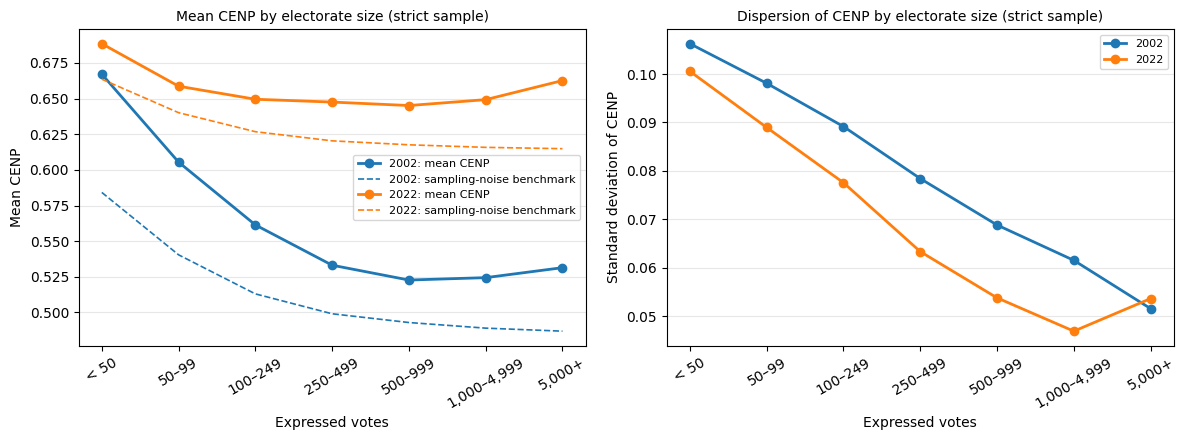

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for i, year in enumerate(YEARS):
    t = size_table.loc[("strict", year)]
    x = np.arange(len(t))
    axes[0].plot(x, t["CENP_mean"], "o-", color=f"C{i}", lw=2, label=f"{year}: mean CENP")
    axes[0].plot(x, t["CENP_noise_benchmark"], "--", color=f"C{i}", lw=1.2, label=f"{year}: sampling-noise benchmark")
    axes[1].plot(x, t["CENP_sd"], "o-", color=f"C{i}", lw=2, label=str(year))
for ax, title, ylabel in zip(axes, ["Mean CENP by electorate size", "Dispersion of CENP by electorate size"],
                             ["Mean CENP", "Standard deviation of CENP"]):
    ax.set_xticks(range(len(SIZE_LABELS)))
    ax.set_xticklabels(SIZE_LABELS, rotation=30)
    ax.set_xlabel("Expressed votes")
    ax.set_ylabel(ylabel)
    ax.set_title(title + " (strict sample)", fontsize=10)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

In [60]:
# Density slope within each electorate-size bin (removes the size–density confound across bins)
within_rows = []
for sname, df in SAMPLES.items():
    for year in YEARS:
        d = df[df["year"] == year].assign(size_bin=lambda x: size_bin(x["expressed"]))
        for b, g in d.groupby("size_bin", observed=True):
            if len(g) >= 30:
                within_rows.append({"sample": sname, "year": year, "size_bin": b, **association_stats(g, "CENP")})
within_size = pd.DataFrame(within_rows).set_index(["sample", "year", "size_bin"])
display(within_size[["n", "pearson_r", "spearman_rho", "ols_coef", "ols_se_HC1", "ols_p_HC1"]].round(5))

# Same idea in one regression: size-bin dummies
rows = []
for sname, df in SAMPLES.items():
    for year in YEARS:
        d = df[df["year"] == year].assign(size_bin=lambda x: size_bin(x["expressed"]).astype(str))
        fit = smf.ols("CENP ~ log_density + C(size_bin)", data=d).fit(cov_type="HC1")
        rows.append({"sample": sname, "year": year, "n": int(fit.nobs), "coef_log_density": fit.params["log_density"],
                     "se_HC1": fit.bse["log_density"], "p_HC1": fit.pvalues["log_density"]})
print("CENP ~ log_density + C(size bin):")
display(pd.DataFrame(rows).set_index(["sample", "year"]).round(5))

n  pearson_r  spearman_rho  ols_coef  ols_se_HC1  ols_p_HC1
sample year size_bin                                                                    
strict 2002 < 50          1693   -0.12536      -0.13545  -0.01910     0.00402    0.00000
            50–99         4855   -0.09833      -0.10040  -0.01492     0.00227    0.00000
            100–249      10628   -0.10445      -0.09734  -0.01266     0.00125    0.00000
            250–499       7055   -0.08736      -0.08290  -0.00897     0.00131    0.00000
            500–999       4527   -0.11397      -0.11575  -0.00953     0.00126    0.00000
            1,000–4,999   4069    0.02972       0.02932   0.00181     0.00097    0.06262
            5,000+         754   -0.08588      -0.07559  -0.00390     0.00187    0.03780
       2022 < 50          1554    0.00992       0.01421   0.00139     0.00350    0.69105
            50–99         4355    0.16062       0.17077   0.02104     0.00198    0.00000
            100–249       9693    0.21978       0.22584   0.02269     0.00103    0.00000
            250–499       7177    0.23486       0.23608   0.01960     0.00094    0.00000
            500–999       5200    0.21464       0.20449   0.01440     0.00093    0.00000
            1,000–4,999   5104    0.22028       0.16631   0.01052     0.00076    0.00000
            5,000+        1029    0.41557       0.39542   0.01810     0.00136    0.00000
broad  2002 < 50          2052   -0.13895      -0.13727  -0.01849     0.00307    0.00000
            50–99         5120   -0.10095      -0.10435  -0.01457     0.00212    0.00000
            100–249      10677   -0.12064      -0.10838  -0.01436     0.00123    0.00000
            250–499       6900   -0.09443      -0.08592  -0.00964     0.00133    0.00000
            500–999       4397   -0.11569      -0.11588  -0.00966     0.00128    0.00000
            1,000–4,999   3922    0.03240       0.03341   0.00199     0.00100    0.04669
            5,000+         746   -0.08274      -0.06875  -0.00377     0.00190    0.04789
       2022 < 50          1805    0.02344       0.03811   0.00296     0.00307    0.33495
            50–99         4525    0.17609       0.18442   0.02198     0.00182    0.00000
            100–249       9781    0.23376       0.23593   0.02367     0.00100    0.00000
            250–499       7162    0.23498       0.23604   0.01958     0.00094    0.00000
            500–999       5186    0.21478       0.20449   0.01440     0.00093    0.00000
            1,000–4,999   5084    0.22057       0.16668   0.01057     0.00076    0.00000
            5,000+        1030    0.41797       0.39926   0.01833     0.00136    0.00000

CENP ~ log_density + C(size bin):


n  coef_log_density   se_HC1  p_HC1
sample year                                         
strict 2002  33581          -0.00866  0.00058    0.0
       2022  34112           0.01694  0.00045    0.0
broad  2002  33814          -0.00970  0.00059    0.0
       2022  34573           0.01727  0.00045    0.0

### 19.7 Density–coordination relationship by electorate threshold

For each year and sample: all valid communes, then `expressed ≥ 100`, `≥ 500`, `≥ 1000`. Pearson correlation of CENP
with `log_density`, Spearman with `density`, and OLS `CENP ~ log_density` (coefficient, classical and HC1 standard
errors and p-values, R²). All thresholds are shown; none is preferred.

### 19.8 Vote-weighted robustness (WLS, weights = expressed)

**Robustness only**, not the main analysis. The unweighted regression describes the *typical commune*; weighting by
expressed votes describes the *typical voter* and down-weights noisy small communes. The two answer different
questions, so the WLS result does not replace the unweighted one.

In [61]:
threshold_results = stats_by_threshold(SAMPLES, "CENP", weighted=True)
threshold_summary = threshold_results[["n", "pearson_r", "spearman_rho", "ols_coef", "ols_se", "ols_p",
                                       "ols_se_HC1", "ols_p_HC1", "ols_R2"]]
print("19.7 — CENP ~ log_density (unweighted; main specification):")
display(threshold_summary.round(5))
threshold_summary.to_csv(AUDIT_DIR / "audit_cenp_density_by_threshold.csv", encoding="utf-8")

19.7 — CENP ~ log_density (unweighted; main specification):


n  pearson_r  spearman_rho  ols_coef   ols_se    ols_p  ols_se_HC1  ols_p_HC1   ols_R2
sample year min_expressed                                                                                            
strict 2002 0              33581   -0.28742      -0.31050  -0.02057  0.00037  0.00000     0.00038    0.00000  0.08261
            100            27033   -0.16533      -0.18513  -0.01081  0.00039  0.00000     0.00038    0.00000  0.02733
            500             9350   -0.01188      -0.02089  -0.00062  0.00054  0.25054     0.00053    0.23880  0.00014
            1000            4823    0.03366       0.04146   0.00164  0.00070  0.01941     0.00070    0.01930  0.00113
       2022 0              34112    0.08180       0.07698   0.00438  0.00029  0.00000     0.00029    0.00000  0.00669
            100            28203    0.16252       0.14897   0.00836  0.00030  0.00000     0.00030    0.00000  0.02641
            500            11333    0.24337       0.18652   0.01030  0.00039  0.00000     0.00043    0.00000  0.05923
            1000            6133    0.27690       0.19466   0.01099  0.00049  0.00000     0.00057    0.00000  0.07667
broad  2002 0              33814   -0.31261      -0.33148  -0.02231  0.00037  0.00000     0.00038    0.00000  0.09772
            100            26642   -0.17663      -0.19322  -0.01153  0.00039  0.00000     0.00039    0.00000  0.03120
            500             9065   -0.01097      -0.01814  -0.00057  0.00055  0.29648     0.00053    0.28478  0.00012
            1000            4668    0.03595       0.04525   0.00176  0.00072  0.01405     0.00072    0.01405  0.00129
       2022 0              34573    0.08670       0.08242   0.00459  0.00028  0.00000     0.00029    0.00000  0.00752
            100            28243    0.16990       0.15453   0.00871  0.00030  0.00000     0.00030    0.00000  0.02887
            500            11300    0.24508       0.18742   0.01038  0.00039  0.00000     0.00043    0.00000  0.06007
            1000            6114    0.27847       0.19573   0.01109  0.00049  0.00000     0.00057    0.00000  0.07754

In [62]:
wls_comparison = threshold_results[["n", "ols_coef", "ols_se_HC1", "ols_p_HC1", "wls_coef", "wls_se_HC1", "wls_p_HC1", "wls_R2"]].copy()
wls_comparison["wls_minus_ols"] = wls_comparison["wls_coef"] - wls_comparison["ols_coef"]
print("19.8 — ROBUSTNESS: weighted (WLS, weights = expressed) vs unweighted OLS slope")
display(wls_comparison.round(5))

19.8 — ROBUSTNESS: weighted (WLS, weights = expressed) vs unweighted OLS slope


n  ols_coef  ols_se_HC1  ols_p_HC1  wls_coef  wls_se_HC1  wls_p_HC1   wls_R2  wls_minus_ols
sample year min_expressed                                                                                                 
strict 2002 0              33581  -0.02057     0.00038    0.00000  -0.00167     0.00119    0.16037  0.00260        0.01890
            100            27033  -0.01081     0.00038    0.00000  -0.00054     0.00115    0.64049  0.00028        0.01027
            500             9350  -0.00062     0.00053    0.23880   0.00214     0.00128    0.09439  0.00414        0.00276
            1000            4823   0.00164     0.00070    0.01930   0.00240     0.00153    0.11663  0.00474        0.00076
       2022 0              34112   0.00438     0.00029    0.00000   0.00965     0.00067    0.00000  0.11522        0.00527
            100            28203   0.00836     0.00030    0.00000   0.01006     0.00066    0.00000  0.12412        0.00170
            500            11333   0.01030     0.00043    0.00000   0.01183     0.00072    0.00000  0.15739        0.00154
            1000            6133   0.01099     0.00057    0.00000   0.01309     0.00078    0.00000  0.17283        0.00210
broad  2002 0              33814  -0.02231     0.00038    0.00000  -0.00198     0.00121    0.10267  0.00365        0.02033
            100            26642  -0.01153     0.00039    0.00000  -0.00070     0.00117    0.55333  0.00046        0.01084
            500             9065  -0.00057     0.00053    0.28478   0.00218     0.00130    0.09323  0.00427        0.00275
            1000            4668   0.00176     0.00072    0.01405   0.00244     0.00156    0.11760  0.00484        0.00068
       2022 0              34573   0.00459     0.00029    0.00000   0.00972     0.00066    0.00000  0.11629        0.00512
            100            28243   0.00871     0.00030    0.00000   0.01013     0.00066    0.00000  0.12529        0.00142
            500            11300   0.01038     0.00043    0.00000   0.01189     0.00072    0.00000  0.15773        0.00151
            1000            6114   0.01109     0.00057    0.00000   0.01315     0.00078    0.00000  0.17271        0.00206

### 19.9 Density deciles

Deciles of `log_density` (ranks, so ties are split) computed **within each year and each sample restriction**. A
roughly monotonic profile across deciles means the slope is not driven by a few very dense communes. CENP levels are
not comparable across years (16 vs 12 candidates) — compare the **shape** of the two profiles. The Spearman correlation
between decile number and decile mean CENP summarises monotonicity (±1 = perfectly monotonic).

In [63]:
def decile_table(df):
    d = df.copy()
    d["density_decile"] = d.groupby("year")["log_density"].transform(
        lambda s: pd.qcut(s.rank(method="first"), 10, labels=False) + 1)
    return d.groupby(["year", "density_decile"]).agg(
        n_communes=("commune_code", "size"), density_median=("density", "median"),
        CENP_mean=("CENP", "mean"), CENP_median=("CENP", "median"),
        cliff_magnitude_mean=("cliff_magnitude", "mean"), cliff_ratio_mean=("cliff_ratio", "mean"),
        expressed_median=("expressed", "median"))


DECILE_RESTRICTIONS = {"all valid": 0, "expressed ≥ 500": 500}
decile_tables = {(sname, label): decile_table(df[df["expressed"] >= t])
                 for sname, df in SAMPLES.items() for label, t in DECILE_RESTRICTIONS.items()}
for key, t in decile_tables.items():
    print(f"\n{key[0]} sample, {key[1]}:")
    display(t.round(4))

monotonic = pd.DataFrame({key: {year: stats.spearmanr(t.loc[year].index, t.loc[year]["CENP_mean"]).statistic for year in YEARS}
                          for key, t in decile_tables.items()}).T
monotonic.index.names = ["sample", "restriction"]
print("Spearman(decile, mean CENP):")
display(monotonic.round(3))


strict sample, all valid:


n_communes  density_median  CENP_mean  CENP_median  cliff_magnitude_mean  cliff_ratio_mean  expressed_median
year density_decile                                                                                                              
2002 1                     3359          7.7454     0.6200       0.6182                0.1226            0.8930              79.0
     2                     3358         13.1588     0.5921       0.5882                0.1089            0.8886             107.0
     3                     3358         18.0432     0.5783       0.5767                0.1030            0.8863             129.0
     4                     3358         24.2563     0.5655       0.5626                0.0992            0.8856             161.0
     5                     3358         32.3121     0.5564       0.5534                0.0958            0.8850             204.0
     6                     3358         43.1170     0.5418       0.5403                0.0905            0.8815             261.0
     7                     3358         58.9562     0.5360       0.5321                0.0892            0.8821             329.0
     8                     3358         86.0358     0.5281       0.5260                0.0855            0.8814             449.0
     9                     3358        147.6112     0.5233       0.5208                0.0842            0.8815             720.0
     10                    3358        476.8716     0.5265       0.5221                0.0813            0.8818            2180.5
2022 1                     3412          7.3236     0.6419       0.6402                0.1537            0.8732              79.0
     2                     3411         13.2196     0.6432       0.6399                0.1523            0.8769             115.0
     3                     3411         19.0883     0.6437       0.6408                0.1504            0.8777             144.0
     4                     3411         26.2712     0.6535       0.6502                0.1547            0.8803             187.0
     5                     3411         35.7942     0.6550       0.6551                0.1543            0.8812             233.0
     6                     3411         48.4127     0.6561       0.6543                0.1524            0.8818             318.0
     7                     3411         67.3077     0.6541       0.6537                0.1478            0.8797             415.0
     8                     3411         98.9362     0.6557       0.6543                0.1491            0.8807             561.0
     9                     3411        169.1638     0.6542       0.6520                0.1462            0.8790             906.0
     10                    3412        529.3581     0.6602       0.6536                0.1545            0.8865            2649.5


strict sample, expressed ≥ 500:


n_communes  density_median  CENP_mean  CENP_median  cliff_magnitude_mean  cliff_ratio_mean  expressed_median
year density_decile                                                                                                              
2002 1                      935         29.1562     0.5412       0.5382                0.0943            0.8888             642.0
     2                      935         47.8673     0.5289       0.5279                0.0899            0.8850             720.0
     3                      935         68.0700     0.5212       0.5220                0.0860            0.8839             787.0
     4                      935         90.5531     0.5180       0.5175                0.0836            0.8829             842.0
     5                      935        119.1045     0.5141       0.5082                0.0816            0.8810             917.0
     6                      935        158.4295     0.5195       0.5177                0.0837            0.8826             995.0
     7                      935        213.5772     0.5201       0.5142                0.0819            0.8812            1143.0
     8                      935        313.1679     0.5200       0.5147                0.0795            0.8793            1485.0
     9                      935        563.0970     0.5260       0.5217                0.0815            0.8829            2353.0
     10                     935       1701.4820     0.5329       0.5267                0.0812            0.8838            5535.0
2022 1                     1134         29.4516     0.6238       0.6227                0.1316            0.8750             680.0
     2                     1133         50.1487     0.6378       0.6376                0.1361            0.8772             739.0
     3                     1133         68.9384     0.6429       0.6448                0.1384            0.8779             808.0
     4                     1133         90.7522     0.6490       0.6490                0.1426            0.8787             832.0
     5                     1134        118.3383     0.6479       0.6466                0.1427            0.8782             935.5
     6                     1133        154.9387     0.6517       0.6496                0.1419            0.8769            1090.0
     7                     1133        209.3098     0.6521       0.6509                0.1453            0.8792            1213.0
     8                     1133        297.7027     0.6533       0.6507                0.1473            0.8810            1563.0
     9                     1133        523.1263     0.6546       0.6500                0.1507            0.8857            2443.0
     10                    1134       1546.5973     0.6728       0.6625                0.1653            0.8931            5786.5


broad sample, all valid:


n_communes  density_median  CENP_mean  CENP_median  cliff_magnitude_mean  cliff_ratio_mean  expressed_median
year density_decile                                                                                                              
2002 1                     3382          6.6568     0.6320       0.6299                0.1296            0.8953              71.0
     2                     3381         12.1856     0.5991       0.5957                0.1128            0.8898             101.0
     3                     3381         17.1081     0.5799       0.5774                0.1034            0.8858             123.0
     4                     3382         23.0267     0.5694       0.5675                0.1003            0.8863             153.0
     5                     3381         30.9442     0.5595       0.5560                0.0971            0.8854             195.0
     6                     3381         41.6935     0.5416       0.5400                0.0900            0.8810             248.0
     7                     3382         57.2277     0.5376       0.5343                0.0897            0.8824             317.0
     8                     3381         83.8995     0.5288       0.5264                0.0859            0.8815             433.0
     9                     3381        144.4019     0.5238       0.5213                0.0844            0.8815             694.0
     10                    3382        467.8141     0.5264       0.5221                0.0814            0.8818            2137.0
2022 1                     3458          6.6087     0.6405       0.6375                0.1526            0.8721              73.0
     2                     3457         12.5395     0.6421       0.6399                0.1518            0.8760             110.0
     3                     3457         18.3468     0.6438       0.6404                0.1511            0.8777             138.0
     4                     3457         25.5512     0.6522       0.6496                0.1539            0.8800             181.0
     5                     3458         34.9472     0.6550       0.6548                0.1545            0.8815             228.0
     6                     3457         47.4299     0.6563       0.6547                0.1526            0.8814             308.0
     7                     3457         66.1413     0.6542       0.6538                0.1483            0.8798             410.0
     8                     3457         97.3502     0.6557       0.6544                0.1493            0.8810             557.0
     9                     3457        166.4927     0.6541       0.6519                0.1461            0.8788             888.0
     10                    3458        519.8020     0.6604       0.6537                0.1547            0.8866            2606.0


broad sample, expressed ≥ 500:


n_communes  density_median  CENP_mean  CENP_median  cliff_magnitude_mean  cliff_ratio_mean  expressed_median
year density_decile                                                                                                              
2002 1                      907         29.4986     0.5417       0.5390                0.0941            0.8886             644.0
     2                      906         48.6693     0.5273       0.5271                0.0891            0.8843             715.5
     3                      907         69.6039     0.5206       0.5210                0.0854            0.8838             775.0
     4                      906         92.4013     0.5184       0.5175                0.0837            0.8828             845.5
     5                      907        121.3247     0.5146       0.5080                0.0814            0.8805             908.0
     6                      906        161.1846     0.5190       0.5176                0.0834            0.8827            1008.0
     7                      906        218.6673     0.5203       0.5143                0.0820            0.8809            1143.0
     8                      907        321.8463     0.5205       0.5158                0.0797            0.8796            1504.0
     9                      906        576.8538     0.5254       0.5208                0.0812            0.8826            2411.0
     10                     907       1731.1144     0.5333       0.5273                0.0813            0.8840            5601.0
2022 1                     1130         29.4418     0.6237       0.6219                0.1316            0.8750             680.0
     2                     1130         50.1936     0.6379       0.6376                0.1363            0.8774             737.5
     3                     1130         69.0884     0.6430       0.6447                0.1384            0.8777             807.5
     4                     1130         90.9331     0.6491       0.6497                0.1428            0.8788             832.0
     5                     1130        118.4186     0.6480       0.6466                0.1428            0.8783             938.5
     6                     1130        155.1778     0.6516       0.6496                0.1418            0.8769            1085.5
     7                     1130        209.7542     0.6522       0.6510                0.1454            0.8792            1210.5
     8                     1130        298.2743     0.6534       0.6509                0.1476            0.8811            1578.5
     9                     1130        524.8698     0.6545       0.6500                0.1507            0.8857            2460.0
     10                    1130       1559.7371     0.6733       0.6628                0.1657            0.8933            5802.0

Spearman(decile, mean CENP):


2002   2022
sample restriction                  
strict all valid       -0.988  0.842
       expressed ≥ 500 -0.091  0.988
broad  all valid       -0.988  0.818
       expressed ≥ 500 -0.079  0.988

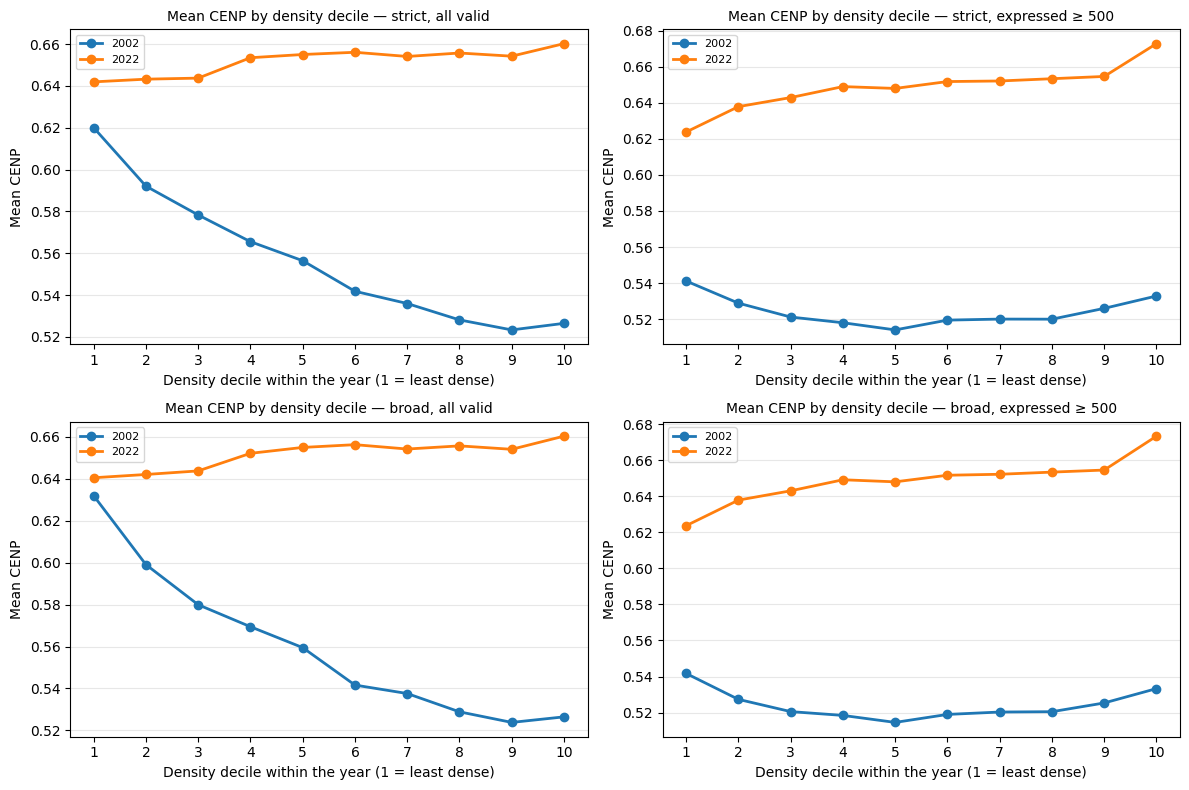

In [64]:
fig, axes = plt.subplots(len(SAMPLES), len(DECILE_RESTRICTIONS), figsize=(12, 4 * len(SAMPLES)), squeeze=False)
for i, sname in enumerate(SAMPLES):
    for j, label in enumerate(DECILE_RESTRICTIONS):
        ax, t = axes[i, j], decile_tables[(sname, label)]
        for k, year in enumerate(YEARS):
            ax.plot(t.loc[year].index, t.loc[year]["CENP_mean"], "o-", color=f"C{k}", lw=2, label=str(year))
        ax.set_xticks(range(1, 11))
        ax.set_xlabel("Density decile within the year (1 = least dense)")
        ax.set_ylabel("Mean CENP")
        ax.set_title(f"Mean CENP by density decile — {sname}, {label}", fontsize=10)
        ax.grid(axis="y", alpha=0.3)
        ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

### 19.10 Within départements: département fixed effects

$$\text{CENP}_i = \beta\,\log\text{density}_i + \alpha_{d(i)} + \varepsilon_i$$

The département dummies $\alpha_d$ absorb **everything shared by communes of the same département** — regional
political traditions, candidates' home bases, regional economic conditions, the département's average urbanisation.
$\beta$ is then estimated only from differences **between communes of the same département**: *within the same
département, are denser communes more coordinated?* A département-level pattern that merely reflects which
départements are dense would disappear here. This is descriptive, not causal: anything that varies within
départements together with density (age, income, education, …) is still in $\beta$.

Estimated separately for each year on communes with `expressed ≥ 500` and `≥ 1000`; HC1 (heteroskedasticity-robust)
standard errors, and département-clustered ones for reference. The slope without fixed effects on the same
observations is shown for comparison.

In [65]:
FE_THRESHOLDS = [500, 1000]


def fe_stats(d, y="CENP"):
    d = d[[y, "log_density", "department_code"]].dropna()
    formula = f"{y} ~ log_density + C(department_code)"
    hc1 = smf.ols(formula, data=d).fit(cov_type="HC1")
    cl = smf.ols(formula, data=d).fit(cov_type="cluster", cov_kwds={"groups": d["department_code"]})
    no_fe = smf.ols(f"{y} ~ log_density", data=d).fit(cov_type="HC1")
    return {"n": int(hc1.nobs), "n_departements": d["department_code"].nunique(),
            "coef": hc1.params["log_density"], "se_HC1": hc1.bse["log_density"], "p_HC1": hc1.pvalues["log_density"],
            "se_cluster_dep": cl.bse["log_density"], "p_cluster_dep": cl.pvalues["log_density"], "R2": hc1.rsquared,
            "coef_without_FE": no_fe.params["log_density"]}


fe_table = pd.DataFrame([{"sample": sname, "year": year, "min_expressed": t,
                          **fe_stats(df[(df["year"] == year) & (df["expressed"] >= t)])}
                         for sname, df in SAMPLES.items() for year in YEARS for t in FE_THRESHOLDS]
                        ).set_index(["sample", "year", "min_expressed"])
print("CENP ~ log_density + C(department_code):")
display(fe_table.round(5))

CENP ~ log_density + C(department_code):


n  n_departements     coef   se_HC1    p_HC1  se_cluster_dep  p_cluster_dep       R2  coef_without_FE
sample year min_expressed                                                                                                           
strict 2002 500             9350              96 -0.00053  0.00057  0.34857         0.00140        0.70507  0.24034         -0.00062
            1000            4823              96  0.00291  0.00077  0.00016         0.00135        0.03141  0.28112          0.00164
       2022 500            11333              96  0.00415  0.00037  0.00000         0.00100        0.00004  0.50226          0.01030
            1000            6133              96  0.00450  0.00049  0.00000         0.00106        0.00002  0.51354          0.01099
broad  2002 500             9065              96 -0.00031  0.00057  0.58170         0.00138        0.81974  0.24090         -0.00057
            1000            4668              96  0.00343  0.00079  0.00001         0.00134        0.01029  0.28323          0.00176
       2022 500            11300              96  0.00425  0.00037  0.00000         0.00100        0.00002  0.50231          0.01038
            1000            6114              96  0.00457  0.00049  0.00000         0.00107        0.00002  0.51359          0.01109

### 19.11 Pooled comparison of the 2002 and 2022 slopes

$$\text{CENP}_{it} = \beta_0 + \beta_1\log\text{density}_{it} + \beta_2\,\mathbb 1[t=2022] + \beta_3\,\log\text{density}_{it}\times\mathbb 1[t=2022] + \varepsilon_{it}$$

$\beta_3$ (`log_density:C(year)[T.2022]`) = 2022 slope − 2002 slope: does the density–coordination slope differ
between the two elections? The pooled data stack two cross-sections; nothing is matched by commune. HC1 and
département-clustered standard errors (most communes appear in both years, within the same département). Not causal.

In [66]:
POOLED_THRESHOLDS = [0, 500, 1000]
TERM = "log_density:C(year)[T.2022]"
pooled_rows = []
for sname, df in SAMPLES.items():
    for t in POOLED_THRESHOLDS:
        d = df.loc[df["expressed"] >= t, ["CENP", "log_density", "year", "department_code"]].dropna()
        hc1 = smf.ols("CENP ~ log_density * C(year)", data=d).fit(cov_type="HC1")
        cl = smf.ols("CENP ~ log_density * C(year)", data=d).fit(cov_type="cluster", cov_kwds={"groups": d["department_code"]})
        pooled_rows.append({"sample": sname, "min_expressed": t, "n": int(hc1.nobs),
                            "slope_2002": hc1.params["log_density"],
                            "slope_2022": hc1.params["log_density"] + hc1.params[TERM],
                            "interaction_2022": hc1.params[TERM], "se_HC1": hc1.bse[TERM], "p_HC1": hc1.pvalues[TERM],
                            "se_cluster_dep": cl.bse[TERM], "p_cluster_dep": cl.pvalues[TERM], "R2": hc1.rsquared})
pooled_table = pd.DataFrame(pooled_rows).set_index(["sample", "min_expressed"])
print("Pooled CENP ~ log_density × C(year):")
display(pooled_table.round(5))

slope_comparison = threshold_results[["n", "ols_coef", "ols_se_HC1", "ols_p_HC1"]].unstack("year")
print("Density slope by year (separate cross-sections, OLS, HC1):")
display(slope_comparison.round(5))

Pooled CENP ~ log_density × C(year):


n  slope_2002  slope_2022  interaction_2022   se_HC1  p_HC1  se_cluster_dep  p_cluster_dep       R2
sample min_expressed                                                                                                         
strict 0              67693    -0.02057     0.00438           0.02495  0.00048    0.0         0.00213        0.00000  0.29421
       500            20683    -0.00062     0.01030           0.01092  0.00068    0.0         0.00217        0.00000  0.54889
       1000           10956     0.00164     0.01099           0.00935  0.00090    0.0         0.00255        0.00025  0.58938
broad  0              68387    -0.02231     0.00459           0.02691  0.00048    0.0         0.00225        0.00000  0.28274
       500            20365    -0.00057     0.01038           0.01096  0.00069    0.0         0.00213        0.00000  0.54915
       1000           10782     0.00176     0.01109           0.00933  0.00092    0.0         0.00253        0.00023  0.58905

Density slope by year (separate cross-sections, OLS, HC1):


n        ols_coef          ols_se_HC1          ols_p_HC1     
year                   2002   2022     2002     2022       2002     2022      2002 2022
sample min_expressed                                                                   
broad  0              33814  34573 -0.02231  0.00459    0.00038  0.00029   0.00000  0.0
       100            26642  28243 -0.01153  0.00871    0.00039  0.00030   0.00000  0.0
       500             9065  11300 -0.00057  0.01038    0.00053  0.00043   0.28478  0.0
       1000            4668   6114  0.00176  0.01109    0.00072  0.00057   0.01405  0.0
strict 0              33581  34112 -0.02057  0.00438    0.00038  0.00029   0.00000  0.0
       100            27033  28203 -0.01081  0.00836    0.00038  0.00030   0.00000  0.0
       500             9350  11333 -0.00062  0.01030    0.00053  0.00043   0.23880  0.0
       1000            4823   6133  0.00164  0.01099    0.00070  0.00057   0.01930  0.0

### 19.12 Secondary measures: cliff magnitude, cliff ratio, cliff location

Complements to CENP, shown compactly: correlations and OLS slopes by threshold, within-département slopes, decile
means (already in the 19.9 tables). `cliff_location` is a position (1 = the largest gap is after the leader), so it is
described by distributions and cross-tabulations, not regressions.

In [67]:
CLIFF_VARS = ["cliff_magnitude", "cliff_ratio"]
cliff_threshold = pd.concat({y: stats_by_threshold(SAMPLES, y) for y in CLIFF_VARS}, names=["outcome"])
print("Cliff measures ~ log_density by threshold:")
display(cliff_threshold[["n", "pearson_r", "spearman_rho", "ols_coef", "ols_se_HC1", "ols_p_HC1", "ols_R2"]].round(5))

cliff_fe = pd.DataFrame([{"outcome": y, "sample": sname, "year": year, "min_expressed": t,
                          **fe_stats(df[(df["year"] == year) & (df["expressed"] >= t)], y)}
                         for y in CLIFF_VARS for sname, df in SAMPLES.items() for year in YEARS for t in FE_THRESHOLDS]
                        ).set_index(["outcome", "sample", "year", "min_expressed"])
print("Cliff measures ~ log_density + C(department_code):")
display(cliff_fe[["n", "coef", "se_HC1", "p_HC1", "coef_without_FE"]].round(5))

Cliff measures ~ log_density by threshold:


n  pearson_r  spearman_rho  ols_coef  ols_se_HC1  ols_p_HC1   ols_R2
outcome         sample year min_expressed                                                                          
cliff_magnitude strict 2002 0              33581   -0.20452      -0.16958  -0.00850     0.00023    0.00000  0.04183
                            100            27033   -0.13947      -0.10193  -0.00515     0.00022    0.00000  0.01945
                            500             9350   -0.08779      -0.06084  -0.00255     0.00031    0.00000  0.00771
                            1000            4823   -0.08015      -0.05998  -0.00215     0.00042    0.00000  0.00642
                       2022 0              34112   -0.00000       0.04482  -0.00000     0.00029    0.99938  0.00000
                            100            28203    0.07742       0.09191   0.00346     0.00029    0.00000  0.00599
                            500            11333    0.20193       0.14129   0.00789     0.00045    0.00000  0.04078
                            1000            6133    0.23683       0.16080   0.00944     0.00063    0.00000  0.05609
                broad  2002 0              33814   -0.22045      -0.18286  -0.00947     0.00025    0.00000  0.04860
                            100            26642   -0.14797      -0.10784  -0.00553     0.00024    0.00000  0.02189
                            500             9065   -0.08572      -0.05751  -0.00247     0.00031    0.00000  0.00735
                            1000            4668   -0.07691      -0.05480  -0.00206     0.00042    0.00000  0.00592
                       2022 0              34573    0.00353       0.05063   0.00017     0.00028    0.55793  0.00001
                            100            28243    0.08279       0.09688   0.00369     0.00029    0.00000  0.00685
                            500            11300    0.20287       0.14180   0.00796     0.00046    0.00000  0.04116
                            1000            6114    0.23777       0.16129   0.00954     0.00063    0.00000  0.05654
cliff_ratio     strict 2002 0              33581   -0.05766      -0.08580  -0.00218     0.00020    0.00000  0.00332
                            100            27033   -0.02616      -0.04616  -0.00099     0.00022    0.00001  0.00068
                            500             9350   -0.02296      -0.03694  -0.00078     0.00035    0.02481  0.00053
                            1000            4823   -0.03490      -0.04579  -0.00112     0.00046    0.01595  0.00122
                       2022 0              34112    0.06821       0.03879   0.00239     0.00019    0.00000  0.00465
                            100            28203    0.09259       0.06465   0.00326     0.00021    0.00000  0.00857
                            500            11333    0.12286       0.09774   0.00415     0.00032    0.00000  0.01509
                            1000            6133    0.14517       0.12665   0.00479     0.00043    0.00000  0.02107
                broad  2002 0              33814   -0.06665      -0.09455  -0.00246     0.00019    0.00000  0.00444
                            100            26642   -0.03080      -0.05021  -0.00116     0.00022    0.00000  0.00095
                            500             9065   -0.02094      -0.03481  -0.00071     0.00035    0.04381  0.00044
                            1000            4668   -0.03135      -0.04223  -0.00101     0.00047    0.03273  0.00098
                       2022 0              34573    0.07308       0.04351   0.00252     0.00019    0.00000  0.00534
                            100            28243    0.09769       0.06852   0.00342     0.00021    0.00000  0.00954
                            500            11300    0.12340       0.09818   0.00417     0.00032    0.00000  0.01523
                            1000            6114    0.14571       0.12696   0.00481     0.00043    0.00000  0.02123

Cliff measures ~ log_density + C(department_code):


n     coef   se_HC1    p_HC1  coef_without_FE
outcome         sample year min_expressed                                                   
cliff_magnitude strict 2002 500             9350 -0.00167  0.00032  0.00000         -0.00255
                            1000            4823 -0.00051  0.00044  0.24133         -0.00215
                       2022 500            11333  0.00350  0.00041  0.00000          0.00789
                            1000            6133  0.00454  0.00057  0.00000          0.00944
                broad  2002 500             9065 -0.00152  0.00032  0.00000         -0.00247
                            1000            4668 -0.00028  0.00044  0.52635         -0.00206
                       2022 500            11300  0.00357  0.00041  0.00000          0.00796
                            1000            6114  0.00460  0.00058  0.00000          0.00954
cliff_ratio     strict 2002 500             9350  0.00035  0.00040  0.38427         -0.00078
                            1000            4823  0.00100  0.00056  0.07071         -0.00112
                       2022 500            11333  0.00329  0.00038  0.00000          0.00415
                            1000            6133  0.00372  0.00052  0.00000          0.00479
                broad  2002 500             9065  0.00047  0.00040  0.24144         -0.00071
                            1000            4668  0.00123  0.00057  0.02948         -0.00101
                       2022 500            11300  0.00328  0.00038  0.00000          0.00417
                            1000            6114  0.00370  0.00052  0.00000          0.00481

In [68]:
for label, t in DECILE_RESTRICTIONS.items():
    d = strict[strict["expressed"] >= t]
    print(f"\ncliff_location — share of communes by year (strict, {label}):")
    display(pd.crosstab(d["cliff_location"], d["year"], normalize="columns").round(3))
    d = d.assign(density_quintile=d.groupby("year")["log_density"].transform(
        lambda s: pd.qcut(s.rank(method="first"), 5, labels=False) + 1))
    for year in YEARS:
        sub = d[d["year"] == year]
        print(f"{year}: cliff_location by density quintile (row shares; 1 = least dense), strict, {label}")
        display(pd.crosstab(sub["density_quintile"], sub["cliff_location"], normalize="index").round(3))


cliff_location — share of communes by year (strict, all valid):


year,2002,2022
cliff_location,,
1.0,0.448,0.413
2.0,0.276,0.307
3.0,0.195,0.249
4.0,0.056,0.025
5.0,0.015,0.004
6.0,0.005,0.001
7.0,0.002,0.000
8.0,0.001,0.000
9.0,0.001,0.000


2002: cliff_location by density quintile (row shares; 1 = least dense), strict, all valid


cliff_location,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0
density_quintile,,,,,,,,,,,,,,,
1,0.522,0.257,0.131,0.059,0.019,0.006,0.003,0.001,0.001,0.001,0.001,0.0,0.0,0.0,0.0
2,0.476,0.288,0.141,0.066,0.017,0.007,0.003,0.001,0.001,0.001,0.000,0.0,0.0,0.0,0.0
3,0.460,0.293,0.159,0.061,0.017,0.005,0.002,0.001,0.001,0.001,0.000,0.0,0.0,0.0,0.0
4,0.421,0.292,0.211,0.055,0.015,0.004,0.001,0.000,0.001,0.000,0.000,0.0,0.0,0.0,0.0
5,0.360,0.250,0.335,0.042,0.010,0.002,0.000,0.000,0.000,0.000,0.000,0.0,0.0,0.0,0.0


2022: cliff_location by density quintile (row shares; 1 = least dense), strict, all valid


...

year,2002,2022
cliff_location,,
1.0,0.377,0.366
2.0,0.258,0.274
3.0,0.307,0.351
4.0,0.049,0.008
5.0,0.007,0.000
6.0,0.001,0.000
7.0,0.000,0.000
8.0,0.000,0.000
9.0,0.000,0.000


2002: cliff_location by density quintile (row shares; 1 = least dense), strict, expressed ≥ 500


cliff_location,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0
density_quintile,,,,,,,,,
1,0.446,0.282,0.188,0.076,0.005,0.001,0.001,0.001,0.001
2,0.407,0.273,0.263,0.048,0.007,0.001,0.000,0.001,0.000
3,0.396,0.256,0.300,0.039,0.008,0.001,0.000,0.000,0.000
4,0.341,0.251,0.349,0.045,0.009,0.003,0.001,0.001,0.000
5,0.293,0.228,0.435,0.036,0.008,0.001,0.000,0.000,0.000


2022: cliff_location by density quintile (row shares; 1 = least dense), strict, expressed ≥ 500


cliff_location,1.0,2.0,3.0,4.0,5.0,6.0
density_quintile,,,,,,
1,0.268,0.349,0.361,0.020,0.001,0.0
2,0.345,0.302,0.343,0.010,0.000,0.0
3,0.368,0.305,0.322,0.006,0.000,0.0
4,0.429,0.251,0.319,0.001,0.000,0.0
5,0.420,0.165,0.411,0.005,0.000,0.0


## Audit summary

Computed from the cells above — nothing is hard-coded. Read it in this order:

1. data construction (scrape failures, exclusions, samples, population measure);
2. the CENP–density slope in each year across thresholds, samples, weighting and fixed effects;
3. the pooled interaction (does the slope differ between 2002 and 2022?).

The scorecard counts in how many pre-specified specifications each pattern holds. With tens of thousands of
communes, tiny slopes are "significant", so the **magnitude** columns (CENP change from the 25th to the 75th
percentile of log density, in CENP units and in standard deviations of CENP) matter as much as the p-values.

In [69]:
print("1. Scrape failures")
display(scrape_summary[["expected_communes", "scraped_communes", "failed_communes", "pct_recovered",
                        "territories_without_commune_pages", "expected_from"]])
print(f"   Communes scraped but with 0 expressed votes: {zero_expressed.groupby('year').size().to_dict()}")

print("\n2. Sample sizes (metropolitan)")
sizes = sample_counts[["metropolitan_election_obs", "valid_density", "main_sample"]].rename(columns={"main_sample": "strict"})
sizes["broad"] = broad.groupby("year").size()
sizes["all_matched"] = all_matched.groupby("year").size()
for col in ["strict", "broad"]:
    sizes[f"pct_{col}"] = (100 * sizes[col] / sizes["metropolitan_election_obs"]).round(2)
display(sizes)

print("\n3. Exclusions from the strict sample by primary reason (metropolitan observations)")
excl = exclusion_counts.drop(index=["overseas", RETAINED])
display(pd.concat({"n": excl, "% of metropolitan": exclusion_pct_metro.drop(index=RETAINED)}, axis=1))

print("\n4. Population used for the 2002 density:", POP_2002_FOR_DENSITY,
      "— 2002 results with the corrected vs previous (1999 census) density:")
display(pop_results.xs(2002, level="year")[["n", "ols_coef", "ols_se_HC1", "pearson_r"]].unstack("min_expressed").round(4))

print("\n5. CENP–density correlations and OLS slopes by threshold and year")
display(threshold_results[["n", "pearson_r", "spearman_rho", "ols_coef", "ols_se_HC1", "ols_p_HC1"]].unstack("year").round(4))

print("\n6. Within-département (FE) slopes")
display(fe_table[["n", "coef", "se_HC1", "p_HC1", "p_cluster_dep", "coef_without_FE"]].unstack("year").round(4))

print("\n7. Pooled year × density interaction")
display(pooled_table[["n", "slope_2002", "slope_2022", "interaction_2022", "se_cluster_dep", "p_cluster_dep"]].round(4))

1. Scrape failures


,expected_communes,scraped_communes,failed_communes,pct_recovered,territories_without_commune_pages,expected_from
year,,,,,,
2002,36674,36674,0,100.0,4,parsed + recorded commune failures (URL list n...
2022,35034,35034,0,100.0,2,parsed + recorded commune failures (URL list n...


   Communes scraped but with 0 expressed votes: {2022: 14}

2. Sample sizes (metropolitan)


,metropolitan_election_obs,valid_density,strict,broad,all_matched,pct_strict,pct_broad
year,,,,,,,
2002,36559,34717,33581,33814,34717,91.85,92.49
2022,34820,34728,34112,34573,34715,97.97,99.29



3. Exclusions from the strict sample by primary reason (metropolitan observations)


...

n        pearson_r         spearman_rho         ols_coef         ols_se_HC1         ols_p_HC1     
year                   2002   2022      2002    2022         2002    2022     2002    2022       2002    2022      2002 2022
sample min_expressed                                                                                                        
broad  0              33814  34573   -0.3126  0.0867      -0.3315  0.0824  -0.0223  0.0046     0.0004  0.0003    0.0000  0.0
       100            26642  28243   -0.1766  0.1699      -0.1932  0.1545  -0.0115  0.0087     0.0004  0.0003    0.0000  0.0
       500             9065  11300   -0.0110  0.2451      -0.0181  0.1874  -0.0006  0.0104     0.0005  0.0004    0.2848  0.0
       1000            4668   6114    0.0359  0.2785       0.0453  0.1957   0.0018  0.0111     0.0007  0.0006    0.0141  0.0
strict 0              33581  34112   -0.2874  0.0818      -0.3105  0.0770  -0.0206  0.0044     0.0004  0.0003    0.0000  0.0
       100            27033  28203   -0.1653  0.1625      -0.1851  0.1490  -0.0108  0.0084     0.0004  0.0003    0.0000  0.0
       500             9350  11333   -0.0119  0.2434      -0.0209  0.1865  -0.0006  0.0103     0.0005  0.0004    0.2388  0.0
       1000            4823   6133    0.0337  0.2769       0.0415  0.1947   0.0016  0.0110     0.0007  0.0006    0.0193  0.0


6. Within-département (FE) slopes


n           coef          se_HC1           p_HC1      p_cluster_dep      coef_without_FE        
year                  2002   2022    2002    2022    2002    2022    2002 2022          2002 2022            2002    2022
sample min_expressed                                                                                                     
broad  500            9065  11300 -0.0003  0.0043  0.0006  0.0004  0.5817  0.0        0.8197  0.0         -0.0006  0.0104
       1000           4668   6114  0.0034  0.0046  0.0008  0.0005  0.0000  0.0        0.0103  0.0          0.0018  0.0111
strict 500            9350  11333 -0.0005  0.0041  0.0006  0.0004  0.3486  0.0        0.7051  0.0         -0.0006  0.0103
       1000           4823   6133  0.0029  0.0045  0.0008  0.0005  0.0002  0.0        0.0314  0.0          0.0016  0.0110


7. Pooled year × density interaction


n  slope_2002  slope_2022  interaction_2022  se_cluster_dep  p_cluster_dep
sample min_expressed                                                                                
strict 0              67693     -0.0206      0.0044            0.0250          0.0021         0.0000
       500            20683     -0.0006      0.0103            0.0109          0.0022         0.0000
       1000           10956      0.0016      0.0110            0.0093          0.0025         0.0002
broad  0              68387     -0.0223      0.0046            0.0269          0.0022         0.0000
       500            20365     -0.0006      0.0104            0.0110          0.0021         0.0000
       1000           10782      0.0018      0.0111            0.0093          0.0025         0.0002

In [70]:
# Robustness scorecard: every pre-specified specification, same yes/no questions
iqr = {year: strict.loc[strict["year"] == year, "log_density"].quantile(0.75)
             - strict.loc[strict["year"] == year, "log_density"].quantile(0.25) for year in YEARS}
sd_cenp = {year: strict.loc[strict["year"] == year, "CENP"].std() for year in YEARS}

score = []
for (sname, t), g in threshold_results.reset_index().groupby(["sample", "min_expressed"]):
    r = g.set_index("year")
    for spec, c, p in [("OLS", "ols_coef", "ols_p_HC1"), ("WLS (robustness)", "wls_coef", "wls_p_HC1")]:
        score.append({"specification": spec, "sample": sname, "min_expressed": t,
                      "slope_2002": r.at[2002, c], "p_2002": r.at[2002, p], "slope_2022": r.at[2022, c], "p_2022": r.at[2022, p]})
for (sname, t), g in fe_table.reset_index().groupby(["sample", "min_expressed"]):
    r = g.set_index("year")
    score.append({"specification": "département FE", "sample": sname, "min_expressed": t,
                  "slope_2002": r.at[2002, "coef"], "p_2002": r.at[2002, "p_HC1"],
                  "slope_2022": r.at[2022, "coef"], "p_2022": r.at[2022, "p_HC1"]})
score = pd.DataFrame(score).set_index(["specification", "sample", "min_expressed"])
for year in YEARS:
    score[f"IQR_effect_{year}"] = score[f"slope_{year}"] * iqr[year]
    score[f"IQR_effect_{year}_in_SD"] = score[f"IQR_effect_{year}"] / sd_cenp[year]
score["2022 > 0 (p<0.05)"] = (score["slope_2022"] > 0) & (score["p_2022"] < ALPHA)
score["2002 > 0 (p<0.05)"] = (score["slope_2002"] > 0) & (score["p_2002"] < ALPHA)
score["2002 < 0 (p<0.05)"] = (score["slope_2002"] < 0) & (score["p_2002"] < ALPHA)
score["2022 slope > 2002 slope"] = score["slope_2022"] > score["slope_2002"]
print("Scorecard (IQR effect = CENP change from the 25th to the 75th percentile of log density; strict-sample IQR and SD):")
display(score.round(4))

flags = ["2022 > 0 (p<0.05)", "2002 > 0 (p<0.05)", "2002 < 0 (p<0.05)", "2022 slope > 2002 slope"]
print("Number of specifications where each pattern holds (out of", len(score), "):")
display(score[flags].sum().to_frame("n_specifications").T)
display(score.groupby(level="specification")[flags].sum())

pooled_flags = pooled_table.assign(**{"interaction > 0 (p<0.05, clustered)":
                                      (pooled_table["interaction_2022"] > 0) & (pooled_table["p_cluster_dep"] < ALPHA)})
print("Pooled interaction: 2022 slope larger than 2002 slope?")
display(pooled_flags[["n", "interaction_2022", "p_cluster_dep", "interaction > 0 (p<0.05, clustered)"]].round(5))

score.to_csv(AUDIT_DIR / "audit_scorecard.csv", encoding="utf-8")
audit[["year", "department_code", "commune_code", "commune_name", "insee_name", "exclusion_reason", "name_mismatch",
       "ratio_low", "ratio_high", "dep_has_unmatched", "evidence_other_unit", "main_sample", "broad_sample",
       "all_matched_sample"]].to_csv(AUDIT_DIR / "audit_sample_flags.csv", index=False, encoding="utf-8")
print("Audit tables written to", AUDIT_DIR)

Scorecard (IQR effect = CENP change from the 25th to the 75th percentile of log density; strict-sample IQR and SD):


,,,slope_2002,p_2002,slope_2022,p_2022,IQR_effect_2002,IQR_effect_2002_in_SD,IQR_effect_2022,IQR_effect_2022_in_SD,2022 > 0 (p<0.05),2002 > 0 (p<0.05),2002 < 0 (p<0.05),2022 slope > 2002 slope
specification,sample,min_expressed,,,,,,,,,,,,
OLS,broad,0,-0.0223,0.0000,0.0046,0.0,-0.0349,-0.3826,0.0076,0.1073,True,False,True,True
WLS (robustness),broad,0,-0.0020,0.1027,0.0097,0.0,-0.0031,-0.0340,0.0160,0.2269,True,False,False,True
OLS,broad,100,-0.0115,0.0000,0.0087,0.0,-0.0180,-0.1977,0.0143,0.2034,True,False,True,True
WLS (robustness),broad,100,-0.0007,0.5533,0.0101,0.0,-0.0011,-0.0119,0.0167,0.2367,True,False,False,True
OLS,broad,500,-0.0006,0.2848,0.0104,0.0,-0.0009,-0.0098,0.0171,0.2425,True,False,False,True
WLS (robustness),broad,500,0.0022,0.0932,0.0119,0.0,0.0034,0.0374,0.0196,0.2778,True,False,False,True
OLS,broad,1000,0.0018,0.0141,0.0111,0.0,0.0027,0.0302,0.0182,0.2590,True,True,False,True
WLS (robustness),broad,1000,0.0024,0.1176,0.0131,0.0,0.0038,0.0418,0.0216,0.3071,True,False,False,True
OLS,strict,0,-0.0206,0.0000,0.0044,0.0,-0.0321,-0.3527,0.0072,0.1023,True,False,True,True


Number of specifications where each pattern holds (out of 20 ):


,2022 > 0 (p<0.05),2002 > 0 (p<0.05),2002 < 0 (p<0.05),2022 slope > 2002 slope
n_specifications,20,4,4,20


,2022 > 0 (p<0.05),2002 > 0 (p<0.05),2002 < 0 (p<0.05),2022 slope > 2002 slope
specification,,,,
OLS,8,2,4,8
WLS (robustness),8,0,0,8
département FE,4,2,0,4


Pooled interaction: 2022 slope larger than 2002 slope?


n  interaction_2022  p_cluster_dep  interaction > 0 (p<0.05, clustered)
sample min_expressed                                                                             
strict 0              67693           0.02495        0.00000                                 True
       500            20683           0.01092        0.00000                                 True
       1000           10956           0.00935        0.00025                                 True
broad  0              68387           0.02691        0.00000                                 True
       500            20365           0.01096        0.00000                                 True
       1000           10782           0.00933        0.00023                                 True

Audit tables written to data/processed/audit_corrected
